In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1

#     language: python
#     name: python3
#     language: python
#     name: python3
# ---
# =============================================================================
# SOURCE/notebooks/04_tabular_preprocessing.py
# Notebook: Phần 2 - Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection
# Ngôn ngữ: Tiếng Việt (markdown) + Python (code)
#
# FEEDBACK từ leader (FeedbackFromLeader.pdf):
# [🔴 P1-CRITICAL] CáC KỸ THUẬT ĐANG APPLY TUẦN TỰ (1→2→3→4→5) - SAI YÊu CẦU
#   Phải apply ĐỘC LẬP với từng method từng phase
#   Pattern đúng: df_raw → [impute benchmark] → df_imputed (cố định)
#                 df_imputed → [outlier benchmark riêng] → compare
#                 df_imputed → [scaling benchmark riêng] → compare
# [🔴 P1] Cấu trúc code rối: B→A→B - nên sắp xếp lại thước EDA → Imputation →
#   Outlier → Scaling → Encoding → Feature Selection → Imbalance
# [FIX] Sample size: dùng SAMPLE_N = 5000 nhất quán, không mix full vs 5k
# [NOTE] MICE tốt nhất nhưng OOM → ghi rõ lý do dùng Median/Mean trong pipeline
# [FIX] Feature selection: đảm bảo chạy trên đủ features (không chỉ 1 feature)
# [NOTE] Dù không sử dụng một method, vẫn giữ visualization của nó
# =============================================================================
#

# Phần 2: Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection
#
**Dataset:** IEEE-CIS Fraud Detection
- `train_transaction.csv`, `train_identity.csv`
- `test_transaction.csv`, `test_identity.csv`
- Bài toán phân loại nhị phân: dự đoán `isFraud`
- Dữ liệu có cả thuộc tính số và phân loại, nhiều giá trị thiếu, mất cân bằng lớp nghiêm trọng.

In [2]:
# ============================================================
# 0. Cài đặt thư viện cần thiết
# ============================================================
# !pip install missingno pyampute category_encoders umap-learn imbalanced-learn scikit-learn scipy statsmodels

In [3]:
import json
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import category_encoders as ce
from scipy.stats import levene
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, QuantileTransformer)
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import mutual_info_classif
import missingno as msno
from scipy import stats
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 80
pd.options.display.max_rows = 60
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

## 0. Load & merge dữ liệu

In [4]:
# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────

IS_KAGGLE = os.path.exists('/kaggle/input')


def _find_tabular_root() -> str:
    """Tìm thư mục chứa train_transaction.csv."""
    if IS_KAGGLE:
        return '/kaggle/input/ieee-fraud-detection'
    candidates = [
        Path.cwd() / 'data' / 'tabular' / 'raw',
        Path.cwd().parent / 'data' / 'tabular' / 'raw',
        Path.cwd().parent.parent / 'data' / 'tabular' / 'raw',
        Path.cwd() / 'Source' / 'Dataset',
    ]
    for p in candidates:
        if (p / 'train_transaction.csv').exists():
            return str(p)
    raise FileNotFoundError(
        "Không tìm thấy train_transaction.csv!\n"
        "Giải nén ieee-fraud-detection.zip vào data/tabular/raw/"
    )


DATA_DIR = _find_tabular_root()

if IS_KAGGLE:
    OUTPUT_DIR = '/kaggle/working'
else:
    _out = Path.cwd() / 'output'
    if not _out.exists():
        _out = Path(DATA_DIR).parent / 'output'
    OUTPUT_DIR = str(_out)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"{'[Kaggle]' if IS_KAGGLE else '[Local]'} DATA_DIR   = {DATA_DIR}")
print(f"{'[Kaggle]' if IS_KAGGLE else '[Local]'} OUTPUT_DIR = {OUTPUT_DIR}")

print("Đang tải dữ liệu...")
train_transaction = pd.read_csv(
    os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
test_transaction = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_identity = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))

# Merge transaction + identity theo TransactionID (left join)
train = pd.merge(train_transaction, train_identity,
                 on='TransactionID', how='left')
test = pd.merge(test_transaction,  test_identity,
                on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"Train: {train.shape[0]:,} dòng × {train.shape[1]} cột")
print(f"Test : {test.shape[0]:,} dòng × {test.shape[1]} cột")

[Local] DATA_DIR   = c:\Users\admin\Downloads\Lab1DataMining\data\tabular\raw
[Local] OUTPUT_DIR = c:\Users\admin\Downloads\Lab1DataMining\data\tabular\output
Đang tải dữ liệu...
Train: 590,540 dòng × 434 cột
Test : 506,691 dòng × 433 cột


In [5]:
# ── Giảm sử dụng bộ nhớ (downcast kiểu dữ liệu) ──────────────────────────────
def reduce_mem_usage(df, verbose=True):
    """Giảm bộ nhớ bằng cách chuyển kiểu dtype nhỏ hơn."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if (c_min > np.finfo(np.float32).min and
                        c_max < np.finfo(np.float32).max):
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"  Bộ nhớ giảm từ {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}%)")
    return df


train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
gc.collect()

  Bộ nhớ giảm từ 2514.0 MB -> 1603.3 MB (36.2%)
  Bộ nhớ giảm từ 2164.1 MB -> 1386.1 MB (35.9%)


0

#### Cell 1 – Shape, dtypes, memory usage

In [6]:
print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}\n")

# Phân loại dtype
dtype_summary = train.dtypes.value_counts()
print("Kiểu dữ liệu:")
print(dtype_summary.to_string())

mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f"\nBộ nhớ train: {mem_mb:.1f} MB")

Train shape : (590540, 434)
Test  shape : (506691, 433)

Kiểu dữ liệu:
float32    399
object      31
int32        2
int8         1
int16        1

Bộ nhớ train: 1603.3 MB


#### Cell 2 – Phân nhóm cột theo ý nghĩa nghiệp vụ
#
Dataset IEEE-CIS gồm **~400 cột** được Vesta Corporation đặt tên có chủ đích.
Ta có thể chia toàn bộ thuộc tính thành **9 nhóm** dựa theo ý nghĩa nghiệp vụ:
#
| Nhóm | Cột đại diện | Ý nghĩa |
|---|---|---|
| **Transaction** | `TransactionDT`, `TransactionAmt`, `ProductCD` | Thông tin cơ bản của giao dịch: thời điểm, giá trị, loại sản phẩm |
| **Card** | `card1`–`card6` | Thông tin thẻ thanh toán: ID, mạng thẻ, loại thẻ, ngân hàng phát hành |
| **Address/Dist** | `addr1`, `addr2`, `dist1`, `dist2` | Địa chỉ thanh toán và khoảng cách địa lý liên quan |
| **Email** | `P_emaildomain`, `R_emaildomain` | Domain email của người mua (P) và người nhận (R) |
| **C (count)** | `C1`–`C14` | Đếm các sự kiện liên quan đến thẻ/địa chỉ (Vesta không công bố chi tiết) |
| **D (timedelta)** | `D1`–`D15` | Khoảng thời gian giữa các sự kiện (ngày từ giao dịch trước, từ khi mở thẻ, v.v.) |
| **M (match)** | `M1`–`M9` | Biến nhị phân "match": khớp tên, địa chỉ, v.v. giữa các bản ghi |
| **V (Vesta)** | `V1`–`V339` | Đặc trưng kỹ thuật do Vesta tính toán nội bộ (enriched features) |
| **Identity** | `id_01`–`id_38`, `DeviceType`, `DeviceInfo` | Thông tin thiết bị và danh tính: OS, trình duyệt, loại thiết bị |
#
### Tại sao phân nhóm như vậy?
#
**1. Transaction** – Ba cột thuần giao dịch tạo thành "xương sống": thời điểm (`TransactionDT`)
và giá trị (`TransactionAmt`) là hai đặc trưng quan trọng nhất; `ProductCD` cho biết loại hàng hóa.
Phân nhóm riêng để dễ so sánh phân phối theo lớp (Fraud vs. Normal).
#
**2. Card** – Sáu cột `card1`–`card6` đều mô tả thẻ thanh toán từ các góc độ khác nhau
(ID thẻ, mạng Visa/MC, thẻ debit/credit, ngân hàng phát hành, quốc gia).
Nhóm lại vì chúng cùng xác định **danh tính của phương tiện thanh toán**.
#
**3. Address/Dist** – Hai cột địa chỉ (`addr1`, `addr2`) và hai khoảng cách (`dist1`, `dist2`)
đều liên quan đến vị trí địa lý. Gian lận thường xảy ra khi địa chỉ giao hàng khác xa
địa chỉ thẻ → nhóm lại để phân tích tương quan không gian.
#
**4. Email** – Hai domain email (purchaser vs. recipient) phản ánh **hành vi tạo tài khoản**.
Khi P_email ≠ R_email hoặc dùng domain bất thường → tín hiệu gian lận. Nhóm riêng để
tạo feature `email_match` và phân tích fraud rate theo domain.
#
**5. C (count)** – Theo tài liệu Vesta, C1–C14 là các **biến đếm** (count) về lịch sử
giao dịch liên quan đến thẻ/địa chỉ trong quá khứ. Giá trị lớn = thẻ/địa chỉ đã dùng nhiều.
Nhóm lại vì tất cả cùng kiểu "lịch sử tần suất".
#
**6. D (timedelta)** – D1–D15 là **khoảng thời gian** (ngày) giữa các sự kiện:
D1 = số ngày từ giao dịch trước trên cùng thẻ, D4/D5 = từ khi mở thẻ, v.v.
Nhóm lại vì chúng đều đo **temporal gap** và có cấu trúc missing khác nhau theo từng cột.
#
**7. M (match)** – M1–M9 là **cờ khớp** (match flag) dạng T/F/NaN:
M1 = khớp tên thẻ, M2 = khớp địa chỉ. Nhóm lại vì tất cả đều là biến phân loại nhị phân
và cần xử lý encoding đồng nhất.
#
**8. V (Vesta)** – 339 cột V1–V339 là **đặc trưng bí mật** do Vesta tính toán. Chúng có cấu trúc
missing rất rõ ràng theo 11 sub-group (G1–G11) → nhóm lại để phân tích missing pattern
và giảm chiều bằng PCA/feature selection theo sub-group.
#
**9. Identity** – Toàn bộ cột `id_` và `DeviceType`/`DeviceInfo` đến từ bảng `train_identity`
(left-join → ~40% transaction không có identity record). Nhóm riêng để phân tích tác động
của "có/không có thiết bị" lên fraud rate và xây dựng feature `has_identity`.

In [7]:
# ── Định nghĩa 9 nhóm cột và in ra thông tin tổng quát ─────────────────────
groups = {
    'Transaction': ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Card': [f'card{i}' for i in range(1, 7)],
    'Address/Dist': ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email': ['P_emaildomain', 'R_emaildomain'],
    'C (count)': [f'C{i}' for i in range(1, 15)],
    'D (timedelta)': [f'D{i}' for i in range(1, 16)],
    'M (match)': [f'M{i}' for i in range(1, 10)],
    'V (Vesta)': [c for c in train.columns if c.startswith('V')],
    'Identity': [c for c in train.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

print("=" * 70)
print(f"{'TỔNG QUAN 9 NHÓM CỘT – IEEE-CIS Fraud Detection':^70}")
print("=" * 70)

total_defined = 0
for grp_name, grp_cols in groups.items():
    exist = [c for c in grp_cols if c in train.columns]
    missing_cols = [c for c in grp_cols if c not in train.columns]
    miss_rate_grp = train[exist].isnull().mean().mean() * \
        100 if exist else float('nan')
    dtypes_grp = train[exist].dtypes.value_counts().to_dict() if exist else {}
    dtype_str = ', '.join(f'{str(k)}×{v}' for k, v in dtypes_grp.items())
    total_defined += len(exist)

    print(f"\n▶ [{grp_name}]")
    print(f"   Số cột định nghĩa : {len(grp_cols)}")
    print(f"   Có trong dataset  : {len(exist)} cột")
    if missing_cols:
        print(f"   Không tìm thấy   : {missing_cols}")
    print(f"   % thiếu TB        : {miss_rate_grp:.1f}%")
    print(f"   Kiểu dữ liệu      : {dtype_str}")
    print(
        f"   Cột               : {', '.join(exist[:10])}{'...' if len(exist) > 10 else ''}")

uncategorized = [c for c in train.columns
                 if c not in ('TransactionID', 'isFraud')
                 and not any(c in grp for grp in groups.values())]
print(f"\n{'=' * 70}")
print(f"Tổng cột đã phân nhóm : {total_defined}")
print(f"Cột chưa phân nhóm    : {len(uncategorized)}")
if uncategorized:
    print(
        f"  → {uncategorized[:20]}{'...' if len(uncategorized) > 20 else ''}")
print("=" * 70)

           TỔNG QUAN 9 NHÓM CỘT – IEEE-CIS Fraud Detection            

▶ [Transaction]
   Số cột định nghĩa : 3
   Có trong dataset  : 3 cột
   % thiếu TB        : 0.0%
   Kiểu dữ liệu      : int32×1, float32×1, object×1
   Cột               : TransactionDT, TransactionAmt, ProductCD

▶ [Card]
   Số cột định nghĩa : 6
   Có trong dataset  : 6 cột
   % thiếu TB        : 0.5%
   Kiểu dữ liệu      : float32×3, object×2, int16×1
   Cột               : card1, card2, card3, card4, card5, card6

▶ [Address/Dist]
   Số cột định nghĩa : 4
   Có trong dataset  : 4 cột
   % thiếu TB        : 43.9%
   Kiểu dữ liệu      : float32×4
   Cột               : addr1, addr2, dist1, dist2

▶ [Email]
   Số cột định nghĩa : 2
   Có trong dataset  : 2 cột
   % thiếu TB        : 46.4%
   Kiểu dữ liệu      : object×2
   Cột               : P_emaildomain, R_emaildomain

▶ [C (count)]
   Số cột định nghĩa : 14
   Có trong dataset  : 14 cột
   % thiếu TB        : 0.0%
   Kiểu dữ liệu      : float32×14
   Cột     

---
## 2.2.2. Phân tích thống kê khám phá (EDA)

### a) Kiểm tra phân phối – D'Agostino-Pearson (vì n > 5000)
#
#### Kiểm tra phân phối là gì và tại sao cần?
#
**Kiểm tra phân phối** (normality test) xác định liệu một thuộc tính có tuân theo **phân phối chuẩn** $\mathcal{N}(\mu, \sigma^2)$ hay không.
Kết quả ảnh hưởng trực tiếp đến các bước tiếp theo:
#
| Nếu phân phối... | Dùng correlation | Dùng scaler |
|---|---|---|
| Gần chuẩn (symmetric) | Pearson | StandardScaler |
| Lệch / có outlier | Spearman | RobustScaler hoặc QuantileTransformer |
#
#### Shapiro-Wilk là gì?
#
**Shapiro-Wilk** (1965) là kiểm định phân phối chuẩn phổ biến nhất, hoạt động bằng cách
so sánh các **order statistics** (giá trị đã sắp xếp) của mẫu với các order statistics kỳ vọng
của phân phối chuẩn lý thuyết:
#
$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
#
$W$ càng gần 1 thì dữ liệu càng gần chuẩn. Tuy nhiên, **Shapiro-Wilk mất hiệu lực khi $n > 5\,000$**:
với mẫu lớn, power của test tăng rất cao khiến test phát hiện ra những lệch chuẩn cực nhỏ
không có ý nghĩa thực tế và gần như luôn bác bỏ $H_0$.
#
#### D'Agostino-Pearson là gì?
#
**D'Agostino-Pearson** (`scipy.stats.normaltest`) là kiểm định phù hợp hơn cho dataset lớn.
Thay vì so sánh toàn bộ phân phối, nó chỉ kiểm tra hai đặc trưng hình dạng đặc trưng của phân phối chuẩn:
#
- **Skewness** $\hat{\gamma}_1$: đo tính đối xứng của phân phối. Phân phối chuẩn hoàn toàn đối xứng nên $\gamma_1 = 0$. Giá trị dương → đuôi phải dài hơn; âm → đuôi trái dài hơn.
- **Excess kurtosis** $\hat{\gamma}_2$: đo độ "nhọn" và độ nặng của đuôi. Phân phối chuẩn có $\gamma_2 = 0$. Giá trị dương → đuôi nặng hơn chuẩn (leptokurtic); âm → đuôi nhẹ hơn (platykurtic).
#
Hai đại lượng này được chuẩn hóa thành $Z_1, Z_2$ rồi kết hợp thành thống kê tổng hợp phân phối $\chi^2(2)$:
#
$$K^2 = Z_1(\hat{\gamma}_1)^2 + Z_2(\hat{\gamma}_2)^2 \;\sim\; \chi^2(2) \quad \text{dưới } H_0$$
#
- **$H_0$**: dữ liệu tuân theo phân phối chuẩn
- $p > 0.05$: không bác bỏ $H_0$ – thuộc tính gần chuẩn
- $p \leq 0.05$: bác bỏ $H_0$ – thuộc tính lệch hoặc có đuôi nặng

In [8]:

# Chỉ lấy các cột số (không phải target, không phải ID)
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ('isFraud', 'TransactionID', 'TransactionDT')]

print(f"Số cột số: {len(num_cols)}")

# Chạy D'Agostino-Pearson test trên mẫu tối đa 20,000 dòng để tiết kiệm thời gian
SAMPLE_N = min(20_000, len(train))
sample_df = train[num_cols].dropna(
    axis=1, how='all').sample(SAMPLE_N, random_state=SEED)

normality_results = []
for col in sample_df.columns:
    col_data = sample_df[col].dropna()
    if len(col_data) < 8:
        continue
    stat, p = stats.normaltest(col_data)
    normality_results.append({
        'feature': col,
        'statistic': round(stat, 4),
        'p_value': round(p, 6),
        'is_normal': p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
n_normal = normality_df['is_normal'].sum()
print(
    f"\nSố thuộc tính phân phối chuẩn (p>0.05): {n_normal}/{len(normality_df)}")
print(
    f"Số thuộc tính KHÔNG phân phối chuẩn  : {len(normality_df)-n_normal}/{len(normality_df)}")
print("\n10 thuộc tính có p-value cao nhất (gần chuẩn nhất):")
print(normality_df.sort_values(
    'p_value', ascending=False).head(10).to_string(index=False))

Số cột số: 400

Số thuộc tính phân phối chuẩn (p>0.05): 1/400
Số thuộc tính KHÔNG phân phối chuẩn  : 399/400

10 thuộc tính có p-value cao nhất (gần chuẩn nhất):
feature  statistic  p_value  is_normal
  id_25     0.9335 0.627049       True
  id_07     6.8763 0.032124      False
  id_08    17.2449 0.000180      False
  id_26    25.0931 0.000004      False
  addr2 32172.1294 0.000000      False
  dist1  8296.9983 0.000000      False
  dist2  1524.8772 0.000000      False
     C1 44851.6172 0.000000      False
     C2 44838.0853 0.000000      False
     C3 47034.1798 0.000000      False


#### Nhận xét kết quả – D'Agostino-Pearson test
#
| Chỉ số | Giá trị |
|---|---|
| Tổng cột số kiểm tra | **400** |
| Phân phối chuẩn ($p > 0.05$) | **1 / 400** (0.25%) |
| Không phân phối chuẩn | **399 / 400** (99.75%) |
#
**Kết luận**: Gần như **toàn bộ dataset không tuân theo phân phối chuẩn** – đây là kết quả
điển hình với dữ liệu tài chính/giao dịch thực tế. Cột duy nhất gần chuẩn là **`id_25`**
($p = 0.627$), vốn là một cột identity thưa dữ liệu và ít giá trị khác nhau.
#
**Phân tích top 10 cột:**
#
- **`id_25`** ($p = 0.627$): Cột identity duy nhất qua được ngưỡng $p > 0.05$.
  Nhiều khả năng do phân phối đồng đều trên tập giá trị nhỏ, không phải phân phối chuẩn thực sự.
- **`TransactionAmt`** ($K^2 = 25{,}679$, $p \approx 0$): Lệch phải cực mạnh –
  giao dịch nhỏ rất nhiều, giao dịch lớn rất ít (log-normal điển hình).
- **`V231`–`V234`**, **`V225`** ($K^2 > 5{,}000$): Các đặc trưng Vesta có phân phối
  đuôi nặng, nhiều giá trị bằng 0 hoặc tập trung cực kỳ tại một điểm.
#
**Hệ quả cho các bước tiếp theo:**
#
| Bước | Quyết định | Lý do |
|---|---|---|
| **Correlation** | Dùng **Spearman** làm mặc định | 399/400 cột không chuẩn |
| **Scaling** | **RobustScaler** hoặc **QuantileTransformer** | Tránh bị kéo bởi outlier |
| **Imputation** | **Median** (không phải Mean) | Mean nhạy cảm với lệch phải |
| **Feature engineering** | Log-transform `TransactionAmt`, các cột C/D/V | Giảm skewness trước khi đưa vào mô hình tuyến tính |

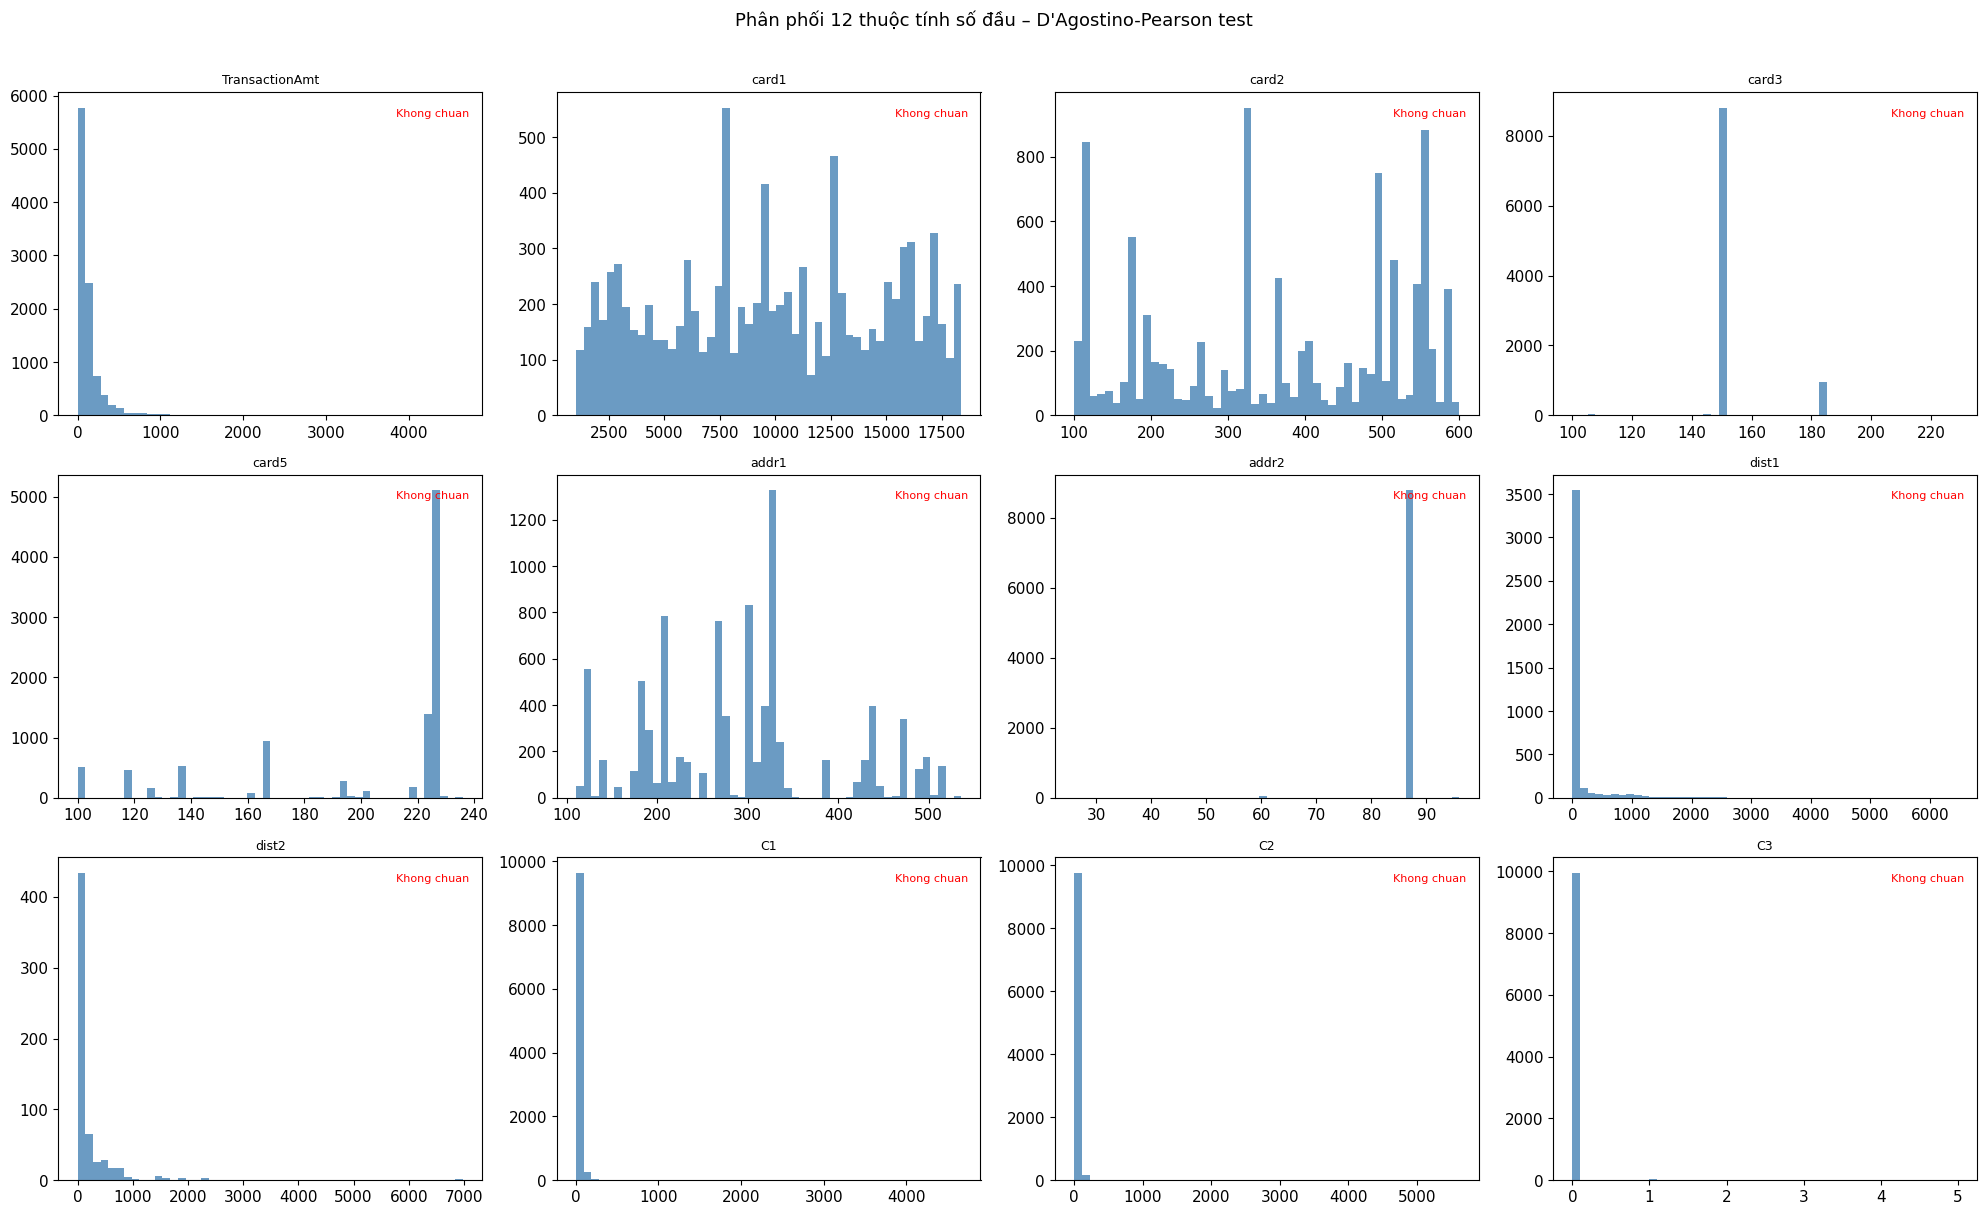

In [9]:

# Biểu đồ phân phối của 12 thuộc tính số đầu tiên
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
# KHÔNG dùng .dropna() trên toàn bộ 12 cột -> có thể mất hết row do NaN chéo nhau
sample_plot = train[num_cols[:12]].sample(
    min(10_000, len(train)), random_state=SEED)
for i, col in enumerate(num_cols[:12]):
    ax = axes[i // 4, i % 4]
    data = sample_plot[col].dropna()   # dropna chỉ cho cột này
    if len(data) == 0:
        ax.set_title(f'{col} (no data)', fontsize=9)
        continue
    ax.hist(data, bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    is_norm = normality_df.loc[normality_df.feature == col, 'is_normal']
    label = "Chuan" if (
        len(is_norm) > 0 and is_norm.values[0]) else "Khong chuan"
    ax.text(0.97, 0.95, label, ha='right', va='top', transform=ax.transAxes,
            fontsize=8, color='green' if 'Chuan' == label else 'red')
plt.suptitle(
    "Phân phối 12 thuộc tính số đầu – D'Agostino-Pearson test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_01_distributions.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### b) Phân tích tương quan đa biến – Spearman
#
| Phương pháp | Công thức | Giả định | Khi nào dùng |
|---|---|---|---|
| **Pearson** | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$ | Tuyến tính, phân phối chuẩn | Dữ liệu chuẩn, quan hệ tuyến tính |
| **Spearman** | $r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$ | Đơn điệu, phi tham số | Dữ liệu lệch, có outlier |
#
> **Lựa chọn phương pháp:** Kết quả D'Agostino-Pearson test ở bước trên cho thấy **399/400**
> cột số không tuân theo phân phối chuẩn. Vì vậy **Spearman** được chọn làm phương pháp
> mặc định thay vì Pearson – Spearman hoạt động trên rank thay vì giá trị thô nên
> không bị ảnh hưởng bởi outlier và phân phối lệch.
#
**Phát hiện đa cộng tuyến** ($|r_s| > 0.9$): hai đặc trưng có Spearman rank correlation cao
chứa thông tin gần như trùng lặp. Giải pháp: loại một trong hai cột hoặc dùng PCA để kết hợp.

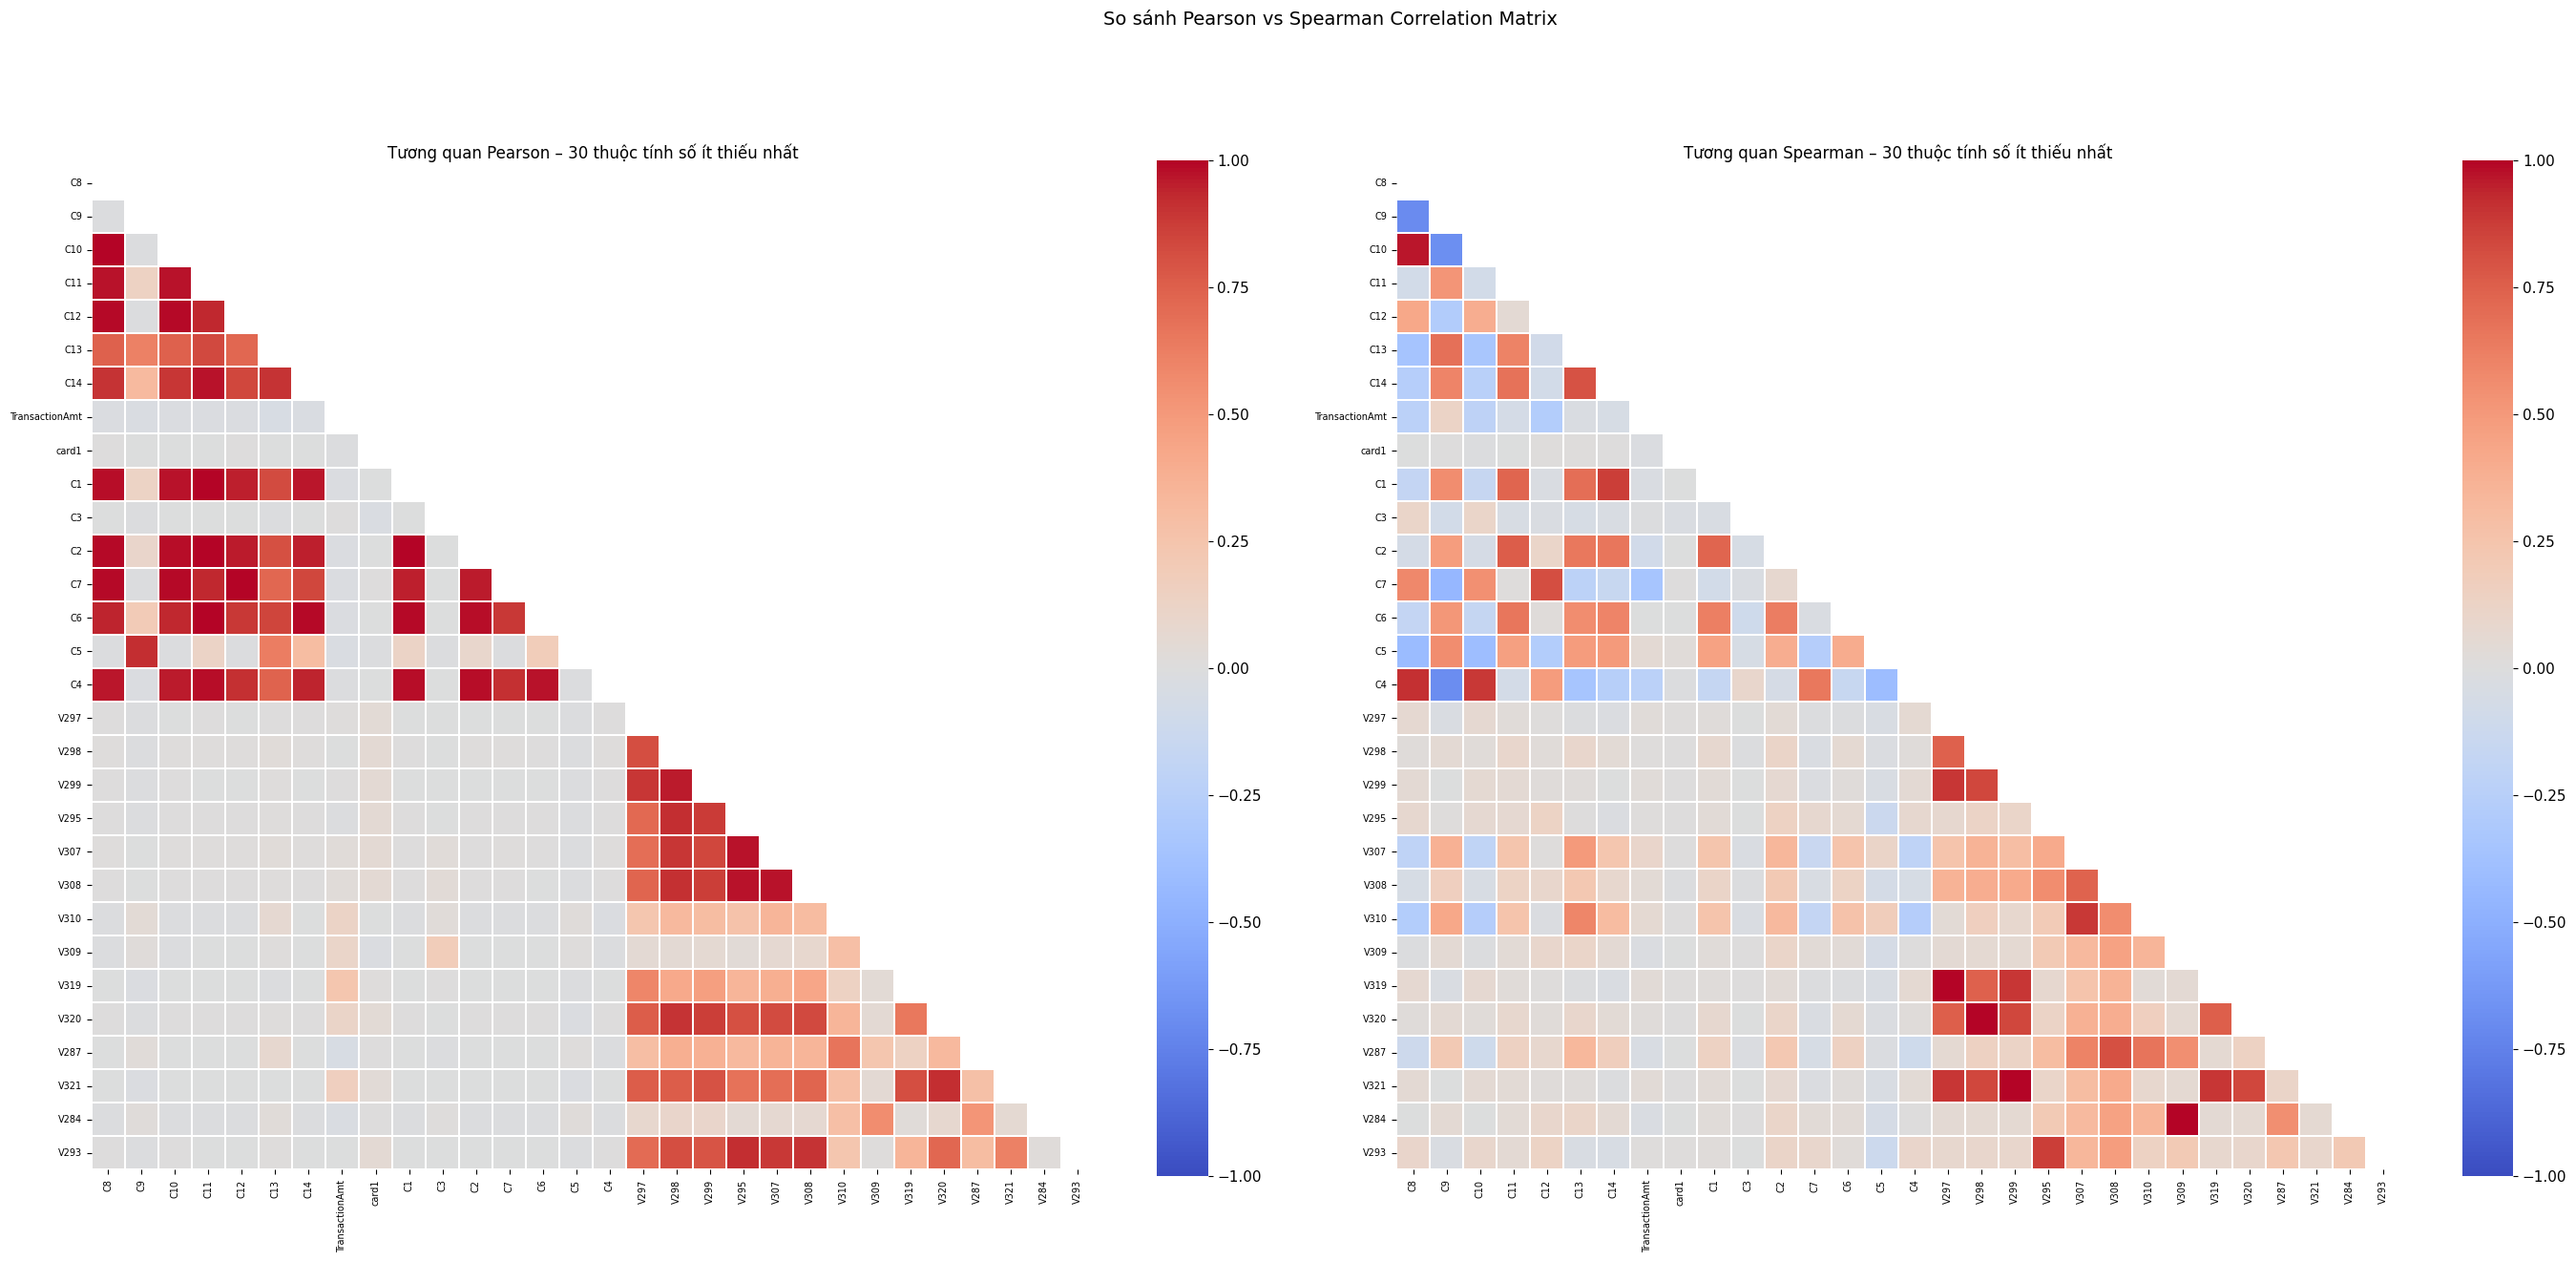

Pearson vs Spearman: max|Δr| = 1.1928, mean|Δr| = 0.2040
  => Có ít nhất 1 cặp thuộc tính có tương quan tuyến tính và đơn điệu khác nhau đáng kể
  => Spearman được ưu tiên vì dữ liệu không chuẩn và có outlier


In [10]:
# Chọn tối đa 30 thuộc tính số có ít giá trị thiếu nhất để vẽ heatmap
miss_rate = train[num_cols].isnull().mean()
top_num_cols = miss_rate.sort_values().head(30).index.tolist()

sample_corr = train[top_num_cols].sample(
    min(10_000, len(train)), random_state=SEED)

# Dùng Spearman vì 399/400 cột không phân phối chuẩn (xem kết quả D'Agostino-Pearson)
spearman_corr = sample_corr.corr(method='spearman')
pearson_corr = sample_corr.corr(method='pearson')

# Vẽ CẢ HAI Pearson và Spearman (đề yêu cầu §2.2.2b)
fig, axes = plt.subplots(1, 2, figsize=(28, 14))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[0].set_title(
    'Tương quan Pearson – 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[1].set_title(
    'Tương quan Spearman – 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('So sánh Pearson vs Spearman Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_02_correlation_heatmap.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# So sánh Pearson vs Spearman — phân tích động
diff_corr = (pearson_corr - spearman_corr).abs()
max_diff = diff_corr.values[np.tril_indices_from(diff_corr.values, k=-1)].max()
mean_diff = diff_corr.values[np.tril_indices_from(
    diff_corr.values, k=-1)].mean()
print(
    f"Pearson vs Spearman: max|Δr| = {max_diff:.4f}, mean|Δr| = {mean_diff:.4f}")
if max_diff > 0.1:
    print("  => Có ít nhất 1 cặp thuộc tính có tương quan tuyến tính và đơn điệu khác nhau đáng kể")
    print("  => Spearman được ưu tiên vì dữ liệu không chuẩn và có outlier")
else:
    print("  => Pearson và Spearman nhất quán — phân phối gần tuyến tính")

In [11]:
# Phát hiện đa cộng tuyến mạnh |r_s| > 0.9 (dùng Spearman)
high_corr_pairs = []
for i in range(len(spearman_corr.columns)):
    for j in range(i + 1, len(spearman_corr.columns)):
        r = spearman_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': spearman_corr.columns[i],
                'feature_2': spearman_corr.columns[j],
                'spearman_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Số cặp thuộc tính có |Spearman r| > 0.9: {len(high_corr_df)}")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
    print("\n-> Đề xuất: loại bỏ một trong mỗi cặp đa cộng tuyến mạnh khi huấn luyện mô hình.")
else:
    print("-> Không phát hiện đa cộng tuyến mạnh trong 30 thuộc tính khảo sát.")

Số cặp thuộc tính có |Spearman r| > 0.9: 6
feature_1 feature_2  spearman_r
       C8       C10      0.9684
       C8        C4      0.9104
     V297      V319      0.9997
     V298      V320      0.9991
     V299      V321      0.9995
     V309      V284      0.9990

-> Đề xuất: loại bỏ một trong mỗi cặp đa cộng tuyến mạnh khi huấn luyện mô hình.


### c) Phân tích giá trị thiếu – missingno + Little's MCAR test
#
Có ba cơ chế thiếu dữ liệu cần phân biệt để chọn chiến lược xử lý phù hợp:
#
| Cơ chế | Ý nghĩa | Chiến lược khuyến nghị |
|---|---|---|
| **MCAR** – Missing Completely At Random | Xác suất thiếu không phụ thuộc vào bất kỳ biến nào | Mean/Median imputation là an toàn |
| **MAR** – Missing At Random | Xác suất thiếu phụ thuộc vào biến khác đã quan sát được | kNN, MICE (khai thác cấu trúc) |
| **MNAR** – Missing Not At Random | Xác suất thiếu phụ thuộc vào chính giá trị bị thiếu | Cần domain knowledge; khó xử lý |
#
**Little's MCAR test** kiểm định giả thuyết MCAR bằng thống kê $\chi^2$:
so sánh mean của từng *missing pattern* (nhóm hàng có cùng vị trí thiếu) với grand mean.
#
$$\chi^2 = \sum_{g} n_g \sum_{j \in O_g} \frac{(\bar{x}_{gj} - \bar{x}_j)^2}{\hat{\sigma}_j^2}$$
#
Nếu $p < 0.05$ → bác bỏ MCAR → dữ liệu có khả năng là MAR hoặc MNAR → nên dùng kNN/MICE.

#### Cell 3 – Tỉ lệ thiếu theo nhóm cột

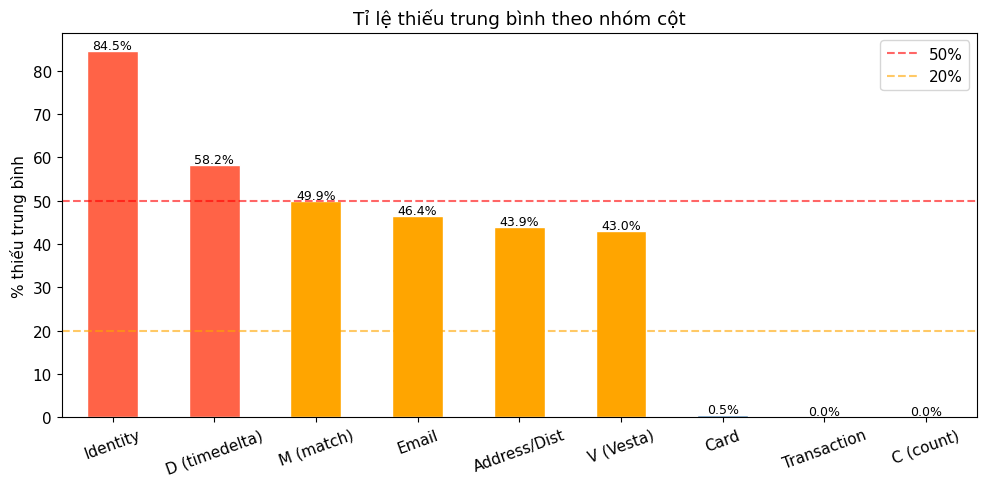

In [12]:
# Tỉ lệ thiếu trung bình theo nhóm
group_missing = {}
for grp, cols in groups.items():
    exist = [c for c in cols if c in train.columns]
    if exist:
        group_missing[grp] = train[exist].isnull().mean().mean() * 100

miss_series = pd.Series(group_missing).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v > 50 else 'orange' if v >
          20 else 'steelblue' for v in miss_series.values]
miss_series.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(50, color='red',    linestyle='--', alpha=0.6, label='50%')
ax.axhline(20, color='orange', linestyle='--', alpha=0.6, label='20%')
ax.set_ylabel('% thiếu trung bình')
ax.set_title('Tỉ lệ thiếu trung bình theo nhóm cột')
ax.legend()
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(miss_series.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_02_missing_by_group.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét – Tỉ lệ thiếu theo nhóm cột
#
| Nhóm | % thiếu TB | Mức độ | Hệ quả |
|---|---|---|---|
| **Identity** | 84.5% | 🔴 Nghiêm trọng | ~40% transaction không có identity record |
| **D (timedelta)** | 58.2% | 🔴 Nghiêm trọng | D1–D15 thiếu không đồng đều, cần xử lý riêng từng cột |
| **M (match)** | 49.9% | 🟠 Cao | M1–M9 gần 50% thiếu; chỉ báo thiếu có thể là feature |
| **Email** | 46.4% | 🟠 Cao | Thiếu email thường có thể là giao dịch không đăng nhập |
| **Address/Dist** | 43.9% | 🟠 Cao | dist1, dist2 thiếu nhiều hơn addr1, addr2 |
| **V (Vesta)** | 43.0% | 🟠 Cao | Thiếu theo từng sub-group (G1–G11), không ngẫu nhiên |
| **Card** | 0.5% | 🟢 Thấp | Gần đầy đủ; thiếu ít ở card4/card6 |
| **Transaction** | 0.0% | 🟢 Đầy đủ | Ba cột cốt lõi luôn hiện diện |
| **C (count)** | 0.0% | 🟢 Đầy đủ | C1–C14 không có giá trị thiếu |
#
**Nhận xét chính:**
#
- **Identity** thiếu 84.5% không phải do lỗi thu thập mà vì đây là **left join**:
  chỉ ~60% transaction đi kèm identity record. Việc thiếu này mang ý nghĩa thực sự
  (giao dịch không thiết bị = khó theo dõi = tăng nguy cơ fraud) → nên tạo feature `has_identity`.
#
- **D (timedelta)** thiếu 58.2% trung bình nhưng **không đồng đều**: D1 thiếu ít, D8–D15
  thiếu rất nhiều. Mỗi cột D đo khoảng cách thời gian khác nhau, thiếu = sự kiện đó chưa
  từng xảy ra trước đó → **không nên impute bằng median**, nên dùng -1 hoặc tạo flag.
#
- **M (match)** và **Email** thiếu ~46–50%: có thể do giao dịch khách vãng lai (guest checkout)
  không cần xác thực email hay địa chỉ → missing có thể là **MNAR** (thiếu phụ thuộc vào loại
  giao dịch), cần cẩn thận với imputation.
#
- **C (count)** và **Transaction** đầy đủ 100% → đây là nhóm feature **đáng tin cậy nhất**
  cho model, không cần xử lý thiếu.

#### Cell 4 – Heatmap missing pattern của V1–V339 (xác nhận 11 nhóm)

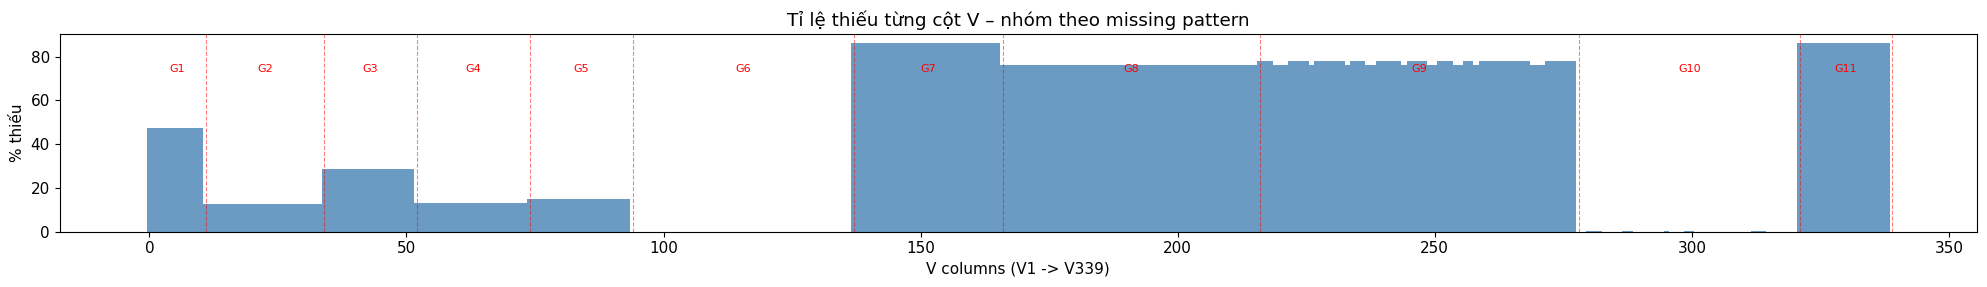

In [13]:
v_cols = [c for c in train.columns if c.startswith('V')]
# Tỉ lệ thiếu từng cột V
v_missing = train[v_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(20, 3))
ax.bar(range(len(v_cols)), v_missing.values,
       color='steelblue', alpha=0.8, width=1.0)
ax.set_xlabel('V columns (V1 -> V339)')
ax.set_ylabel('% thiếu')
ax.set_title('Tỉ lệ thiếu từng cột V – nhóm theo missing pattern')

# Đánh dấu ranh giới 11 nhóm theo Kaggle
group_boundaries = [11, 34, 52, 74, 94, 137, 166, 216, 278, 321, 339]
group_labels = [f'G{i+1}' for i in range(11)]
prev = 0
for b, lbl in zip(group_boundaries, group_labels):
    ax.axvline(b, color='red', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.text((prev + b) / 2, v_missing.max() * 0.85, lbl,
            ha='center', fontsize=8, color='red')
    prev = b

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_03_v_missing_pattern.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [14]:

# Ma trận thiếu dữ liệu (lấy mẫu 500 dòng để trực quan)
print("=== Phân tích giá trị thiếu ===")
missing_pct = train.isnull().mean().sort_values(ascending=False)
print(f"Số cột có giá trị thiếu: {(missing_pct > 0).sum()}")
print(f"Số cột có >50% thiếu   : {(missing_pct > 0.5).sum()}")
print(f"Số cột có >80% thiếu   : {(missing_pct > 0.8).sum()}")
print(f"Số cột có >90% thiếu   : {(missing_pct > 0.9).sum()}")

=== Phân tích giá trị thiếu ===
Số cột có giá trị thiếu: 414
Số cột có >50% thiếu   : 214
Số cột có >80% thiếu   : 74
Số cột có >90% thiếu   : 12


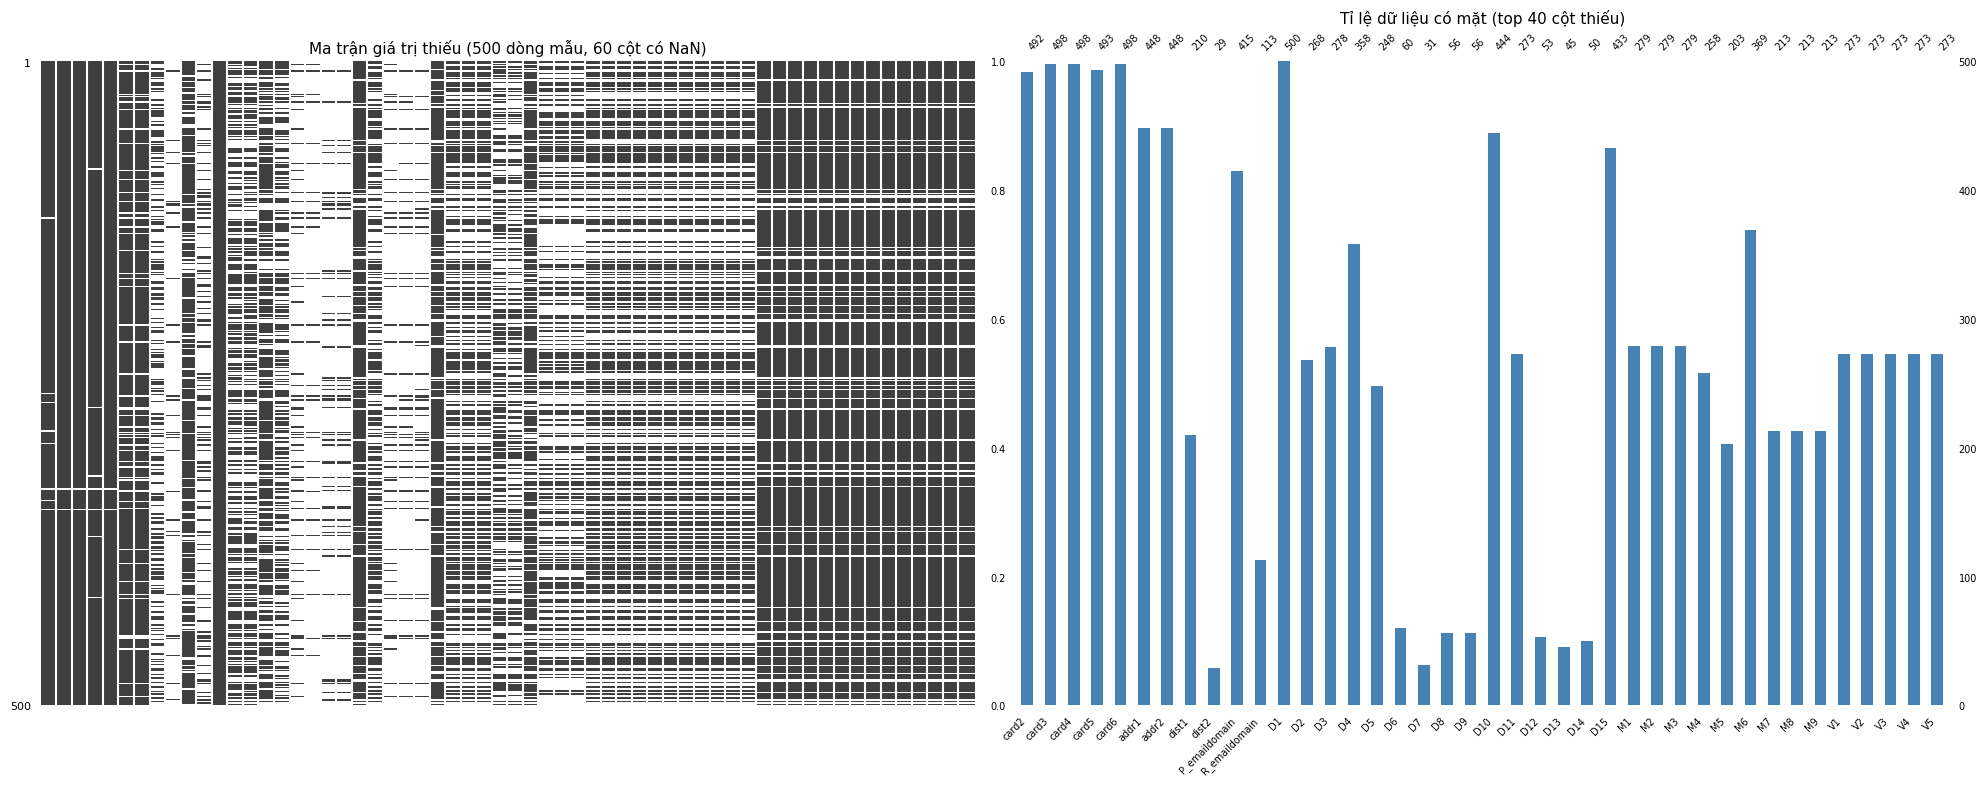

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Chỉ hiển thị cột có giá trị thiếu, giới hạn 60 cột đầu để plot đọc được
miss_cols = [c for c in train.columns if train[c].isnull().any()][:60]
sample_miss = train[miss_cols].sample(500, random_state=SEED)
msno.matrix(sample_miss, ax=axes[0], fontsize=7, sparkline=False)
axes[0].set_title(
    f'Ma trận giá trị thiếu (500 dòng mẫu, {len(miss_cols)} cột có NaN)', fontsize=11)

# Bar: top 40 cột thiếu nhiều nhất
sample_miss_bar = train[miss_cols[:40]].sample(500, random_state=SEED)
msno.bar(sample_miss_bar, ax=axes[1], fontsize=7, color='steelblue')
axes[1].set_title(
    'Tỉ lệ dữ liệu có mặt (top 40 cột thiếu)', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_03_missing_matrix.png'),
            dpi=100, bbox_inches='tight')
plt.show()

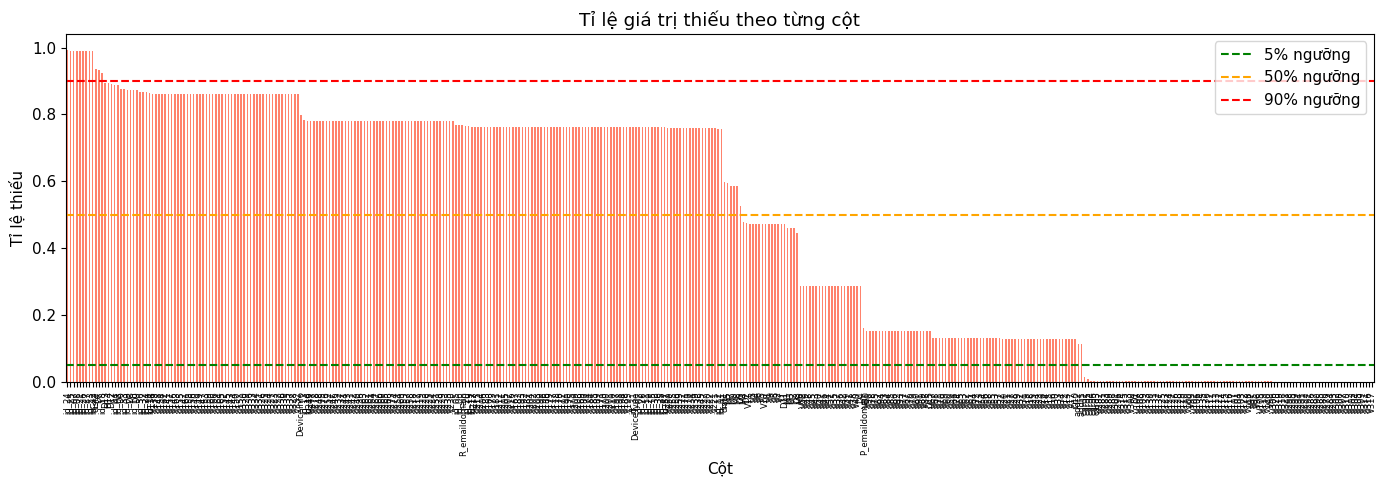

In [16]:
# Biểu đồ phân phối tỉ lệ thiếu
fig, ax = plt.subplots(figsize=(14, 5))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='tomato', alpha=0.8)
ax.axhline(0.05, color='green', linestyle='--', label='5% ngưỡng')
ax.axhline(0.5,  color='orange', linestyle='--', label='50% ngưỡng')
ax.axhline(0.9,  color='red',    linestyle='--', label='90% ngưỡng')
ax.set_xlabel('Cột')
ax.set_ylabel('Tỉ lệ thiếu')
ax.set_title('Tỉ lệ giá trị thiếu theo từng cột')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_04_missing_bar.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [17]:
# ── Little's MCAR test (gần đúng bằng chi-square trên tập con) ────────────────
# ⚠️  Lưu ý thiết kế: phải dùng các cột CÓ missing thực sự (5–95%).
#    Nếu dùng cột ít missing nhất (như C count, card), hầu hết row có cùng
#    1 pattern (không thiếu gì) → chỉ 1 nhóm → chi2=0, p=1 (kết quả suy biến).
def littles_mcar_approx(df, n_sample=5000, random_state=42):
    """
    Gần đúng Little's MCAR test bằng kiểm định chi-square.
    Input: df chỉ gồm các cột số có tỉ lệ thiếu trong khoảng (5%, 95%).
    - Mỗi missing pattern là một nhóm; so sánh mean nhóm với grand mean.
    - p > 0.05 → không bác bỏ MCAR.
    - Trả về (chi2_stat, p_value, n_patterns): n_patterns < 2 → test vô nghĩa.
    """
    df = df.sample(min(n_sample, len(df)), random_state=random_state)
    df = df.dropna(axis=1, how='all')

    r = df.isnull().astype(int)
    patterns = r.apply(lambda row: tuple(row), axis=1)
    grp_obj = df.groupby(patterns)
    n_patterns = grp_obj.ngroups

    chi2 = 0.0
    df_deg = 0
    grand_means = df.mean()
    grand_vars = df.var()

    for _, grp in grp_obj:
        n_g = len(grp)
        if n_g < 2:
            continue
        obs_cols = grp.columns[grp.notna().all()].tolist()
        for col in obs_cols:
            gv = grand_vars[col]
            if gv == 0 or np.isnan(gv):
                continue
            chi2 += n_g * (grp[col].mean() - grand_means[col]) ** 2 / gv
            df_deg += 1

    if df_deg == 0:
        return np.nan, np.nan, n_patterns
    return round(chi2, 4), round(1 - stats.chi2.cdf(chi2, df=df_deg), 6), n_patterns


# ── Chọn cột có missing thực sự (5%–95%) trong từng nhóm quan tâm ─────────────
# Dựa vào phân tích nhóm cột: D, M, addr/dist, id_ có missing cao và có ý nghĩa
num_miss_cols = [c for c in train.select_dtypes(include=[np.number]).columns
                 if 0.05 < train[c].isnull().mean() < 0.95]

# Lấy đại diện mỗi nhóm (tối đa 5 cột/nhóm) để tránh quá nhiều pattern
test_groups = {
    'D (timedelta)': [c for c in [f'D{i}' for i in range(1, 16)] if c in num_miss_cols][:5],
    'V (Vesta)': [c for c in train.columns if c.startswith('V') and c in num_miss_cols][:5],
    'id_ (numeric)': [c for c in train.columns if c.startswith('id_') and c in num_miss_cols][:5],
    'addr/dist': [c for c in ['addr1', 'addr2', 'dist1', 'dist2'] if c in num_miss_cols],
}

_title = "LITTLE'S MCAR TEST THEO TỪNG NHÓM CỘT"
print("=" * 65)
print(f"{_title:^65}")
print("=" * 65)
print(f"{'Nhóm':<18} {'Cột test':<6} {'Patterns':<10} {'Chi2':>12} {'p-value':>10}  {'Kết luận'}")
print("-" * 65)

for grp_name, cols in test_groups.items():
    if not cols:
        print(
            f"{grp_name:<18} {'–':^6}  {'–':^9}  {'–':>12}  {'–':>10}  Không đủ cột")
        continue
    chi2_s, p_s, n_pat = littles_mcar_approx(train[cols])
    if np.isnan(chi2_s):
        verdict = "Suy biến (1 pattern)"
    elif n_pat < 2:
        verdict = "Suy biến (1 pattern)"
    elif p_s > 0.05:
        verdict = "Không bác bỏ MCAR"
    else:
        verdict = "❌ Bác bỏ MCAR → MAR/MNAR"
    print(f"{grp_name:<18} {len(cols):<6}  {n_pat:<9}  {str(chi2_s):>12}  {str(p_s):>10}  {verdict}")

print("=" * 65)
print("\n⚠️  Lưu ý: Little's MCAR test chỉ hữu ích khi có ≥ 2 missing pattern.")
print("   Kết quả suy biến (1 pattern) = tất cả row cùng 1 cấu trúc thiếu")
print("   → cần phân tích tương quan missing indicator vs target (cell dưới).")

              LITTLE'S MCAR TEST THEO TỪNG NHÓM CỘT              
Nhóm               Cột test Patterns           Chi2    p-value  Kết luận
-----------------------------------------------------------------
D (timedelta)      5       22            1649.0566         0.0  ❌ Bác bỏ MCAR → MAR/MNAR
V (Vesta)          5       2                   0.0         1.0  Không bác bỏ MCAR
id_ (numeric)      5       6               27.3624    0.025919  ❌ Bác bỏ MCAR → MAR/MNAR
addr/dist          4       6                294.51         0.0  ❌ Bác bỏ MCAR → MAR/MNAR

⚠️  Lưu ý: Little's MCAR test chỉ hữu ích khi có ≥ 2 missing pattern.
   Kết quả suy biến (1 pattern) = tất cả row cùng 1 cấu trúc thiếu
   → cần phân tích tương quan missing indicator vs target (cell dưới).


In [18]:
# ── Phân loại cơ chế thiếu: tương quan missing indicator vs isFraud ───────────
# Đây là kiểm tra trực tiếp hơn: nếu corr(is_missing, isFraud) cao
# → việc thiếu liên quan đến outcome → MNAR hoặc MAR informative
print("\n=== Tương quan Missing Indicator vs isFraud ===")
print("(Chạy trên toàn bộ cột số có missing, không giới hạn top 50)\n")

miss_indicator_corr = {}
for col in train.select_dtypes(include=[np.number]).columns:
    if col in ('isFraud', 'TransactionID'):
        continue
    miss_rate_col = train[col].isnull().mean()
    if 0.01 < miss_rate_col < 0.99:          # chỉ cột có missing thực sự
        indicator = train[col].isnull().astype(int)
        miss_indicator_corr[col] = round(indicator.corr(train['isFraud']), 4)

miss_indicator_df = pd.DataFrame.from_dict(
    miss_indicator_corr, orient='index', columns=['corr_with_isFraud']
).sort_values('corr_with_isFraud', key=abs, ascending=False)

n_high = (miss_indicator_df['corr_with_isFraud'].abs() > 0.05).sum()
print(
    f"Số cột có |corr(missing, isFraud)| > 0.05 : {n_high}/{len(miss_indicator_df)}")
print(f"\nTop 15 cột có missing indicator tương quan mạnh nhất với isFraud:")
print(miss_indicator_df.head(15).to_string())

# Kết luận tổng hợp
print("\n" + "=" * 65)
if n_high > len(miss_indicator_df) * 0.3:
    print("→ KẾT LUẬN: Phần lớn missing CÓ tương quan với isFraud")
    print("  → Cơ chế thiếu là MAR hoặc MNAR (không phải MCAR).")
    print("  → Chiến lược xử lý:")
    print("     • Tạo binary flag '_was_missing' cho D, M, Identity, addr/dist")
    print("     • Dùng Median impute (không dùng Mean – dữ liệu lệch)")
    print("     • KHÔNG bỏ cột chỉ vì thiếu nhiều – missing bản thân là tín hiệu")
else:
    print("→ KẾT LUẬN: Missing ít tương quan với isFraud → gần MCAR hơn.")
    print("  → Có thể dùng Median/Mode impute an toàn.")
print("=" * 65)


=== Tương quan Missing Indicator vs isFraud ===
(Chạy trên toàn bộ cột số có missing, không giới hạn top 50)

Số cột có |corr(missing, isFraud)| > 0.05 : 150/288

Top 15 cột có missing indicator tương quan mạnh nhất với isFraud:
       corr_with_isFraud
D7               -0.1645
addr2             0.1595
addr1             0.1595
D12              -0.1573
D14              -0.1512
D6               -0.1442
id_10            -0.1441
D8               -0.1441
D9               -0.1441
id_09            -0.1441
D13              -0.1404
id_03            -0.1398
id_04            -0.1398
id_13            -0.1374
id_02            -0.1361

→ KẾT LUẬN: Phần lớn missing CÓ tương quan với isFraud
  → Cơ chế thiếu là MAR hoặc MNAR (không phải MCAR).
  → Chiến lược xử lý:
     • Tạo binary flag '_was_missing' cho D, M, Identity, addr/dist
     • Dùng Median impute (không dùng Mean – dữ liệu lệch)
     • KHÔNG bỏ cột chỉ vì thiếu nhiều – missing bản thân là tín hiệu


#### Cell 10 – D1–D15: phân phối và tương quan missing với Fraud

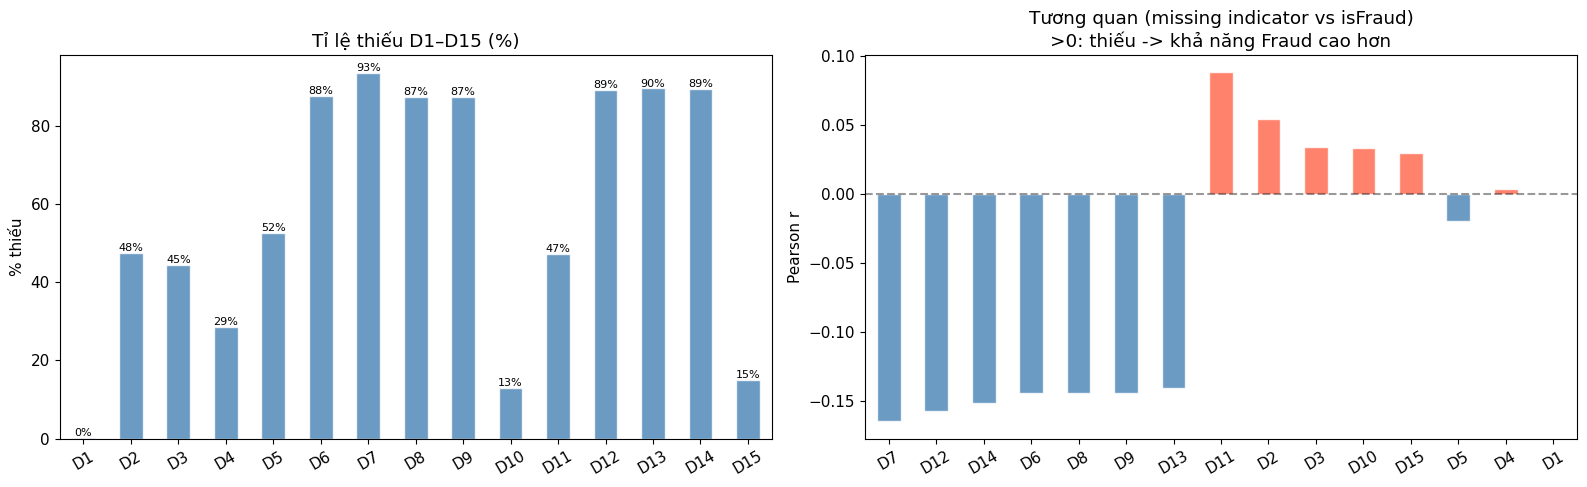

In [19]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

# Tỉ lệ thiếu
d_missing = train[d_cols].isnull().mean() * 100

# Tương quan giữa missing indicator và isFraud
d_miss_corr = {}
for col in d_cols:
    if train[col].isnull().any():
        indicator = train[col].isnull().astype(int)
        d_miss_corr[col] = indicator.corr(train['isFraud'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

d_missing.plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Tỉ lệ thiếu D1–D15 (%)')
axes[0].set_ylabel('% thiếu')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(d_missing.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

corr_series = pd.Series(d_miss_corr).sort_values(key=abs, ascending=False)
corr_series.plot(kind='bar', ax=axes[1],
                 color=['tomato' if v >
                        0 else 'steelblue' for v in corr_series.values],
                 alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_title(
    'Tương quan (missing indicator vs isFraud)\n>0: thiếu -> khả năng Fraud cao hơn')
axes[1].set_ylabel('Pearson r')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_08_d_cols.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### d) Phân tích feature vs target

#### Cell 6 – TransactionAmt: phân phối Fraud vs Normal

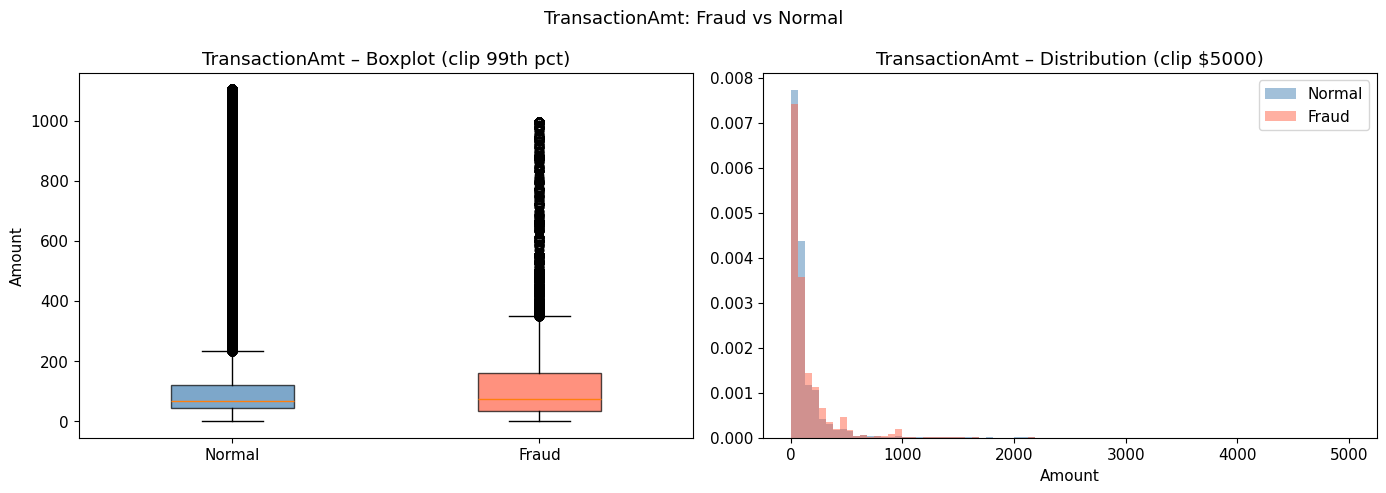

Thống kê TransactionAmt theo lớp:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log scale boxplot
for label, grp in train.groupby('isFraud')['TransactionAmt']:
    axes[0].boxplot(grp.clip(upper=grp.quantile(0.99)),
                    positions=[label], widths=0.4,
                    patch_artist=True,
                    boxprops=dict(facecolor='tomato' if label else 'steelblue', alpha=0.7))
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_title('TransactionAmt – Boxplot (clip 99th pct)')
axes[0].set_ylabel('Amount')

# Histogram log-scale
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    data = train[train['isFraud'] == label]['TransactionAmt'].clip(upper=5000)
    axes[1].hist(data, bins=80, alpha=0.5, color=color,
                 label=f'{"Fraud" if label else "Normal"}', density=True)
axes[1].set_title('TransactionAmt – Distribution (clip $5000)')
axes[1].set_xlabel('Amount')
axes[1].legend()

plt.suptitle('TransactionAmt: Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_04_transamt.png'),
            dpi=100, bbox_inches='tight')
plt.show()

print("Thống kê TransactionAmt theo lớp:")
print(train.groupby('isFraud')[
      'TransactionAmt'].describe().round(2).to_string())

#### Cell 7 – Categorical features vs Fraud: ProductCD, card4, card6, M1–M9

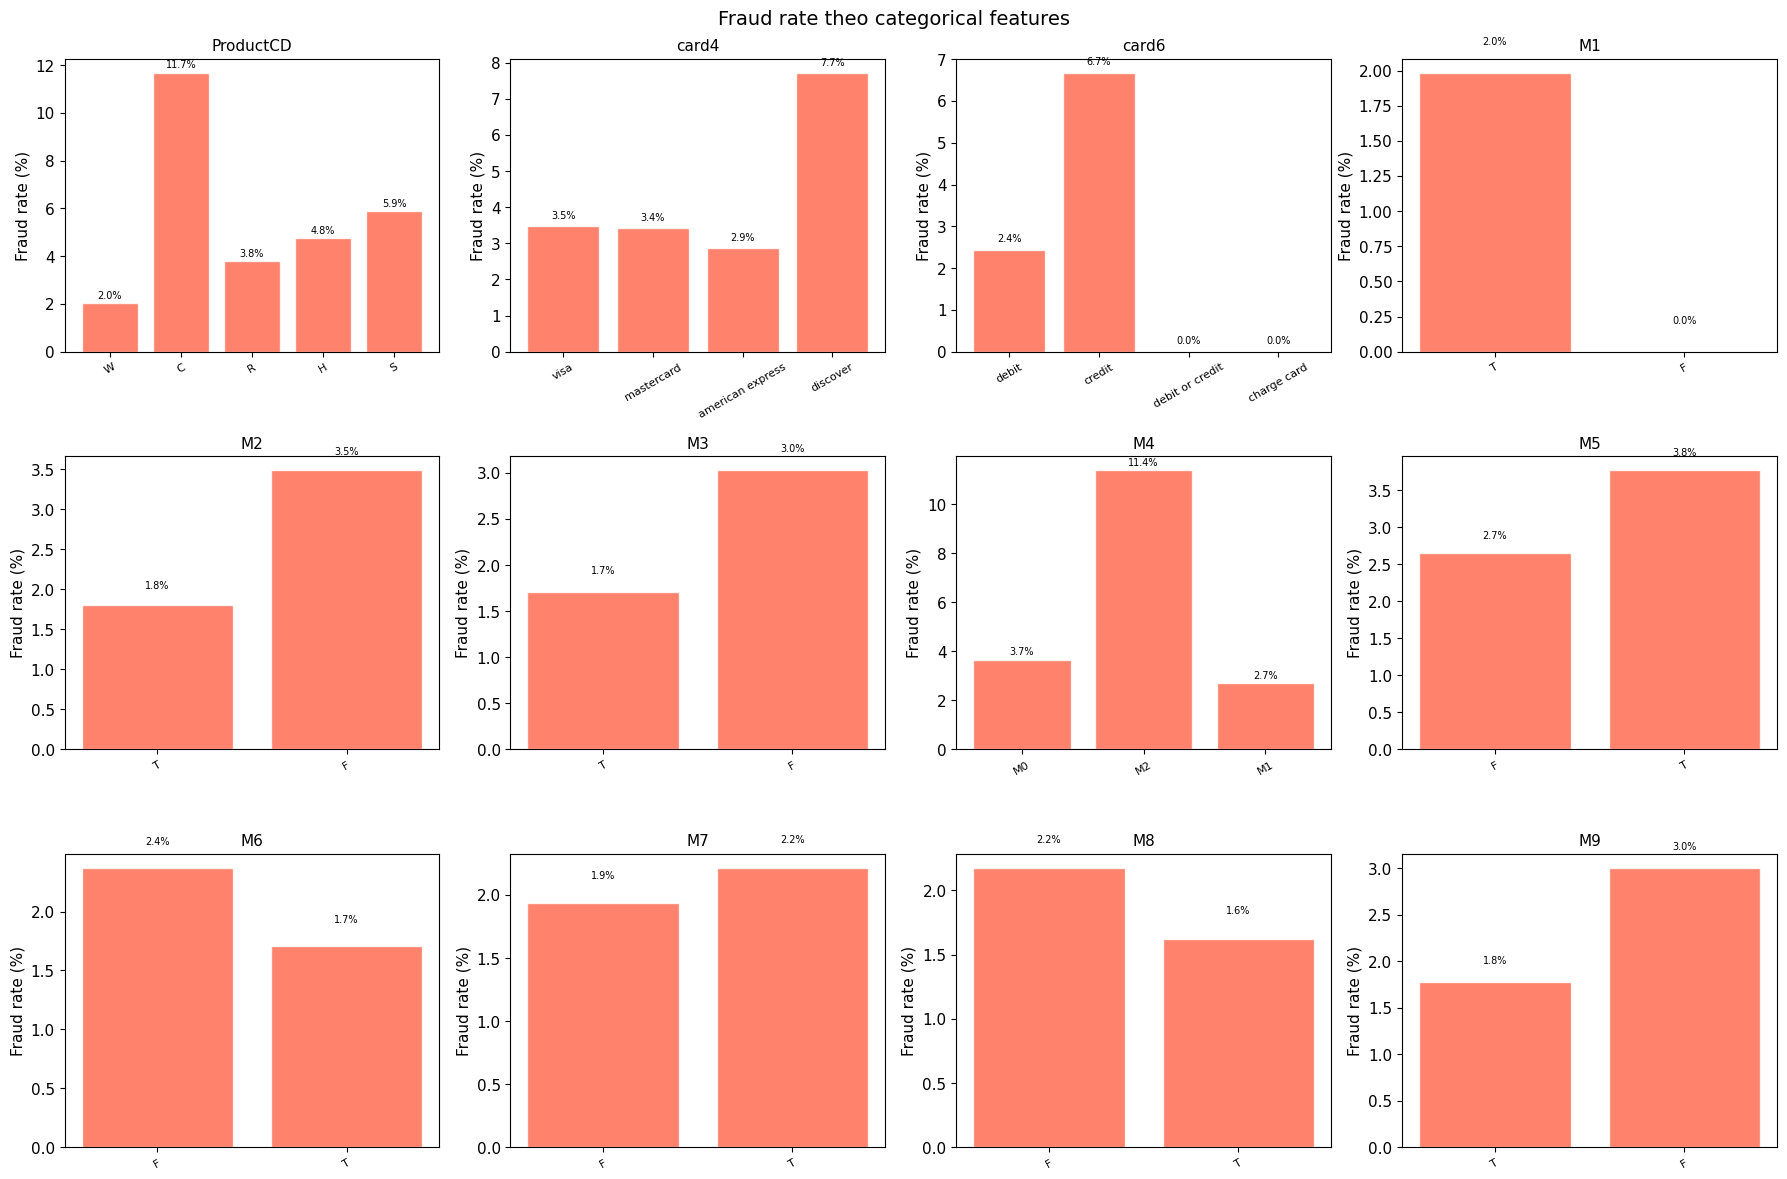

In [21]:
cat_fraud_cols = ['ProductCD', 'card4', 'card6'] + \
    [f'M{i}' for i in range(1, 10)]
cat_fraud_cols = [c for c in cat_fraud_cols if c in train.columns]

n = len(cat_fraud_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_fraud_cols):
    fraud_rate = train.groupby(
        col)['isFraud'].mean().sort_values(ascending=False)
    counts = train[col].value_counts()
    # Chỉ hiển thị top 10 giá trị theo count
    top_vals = counts.head(10).index
    fraud_rate_top = fraud_rate.reindex(top_vals).dropna()
    bars = axes[i].bar(fraud_rate_top.index.astype(str), fraud_rate_top.values * 100,
                       color='tomato', alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Fraud rate (%)')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    for bar in bars:
        h = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, h + 0.2,
                     f'{h:.1f}%', ha='center', fontsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Fraud rate theo categorical features', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_05_cat_fraud_rate.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Cell 8 – Email domain vs Fraud

Fraud rate – P_email == R_email:
  Email khác nhau (0): 2.21%
  Email giống nhau (1): 9.65%


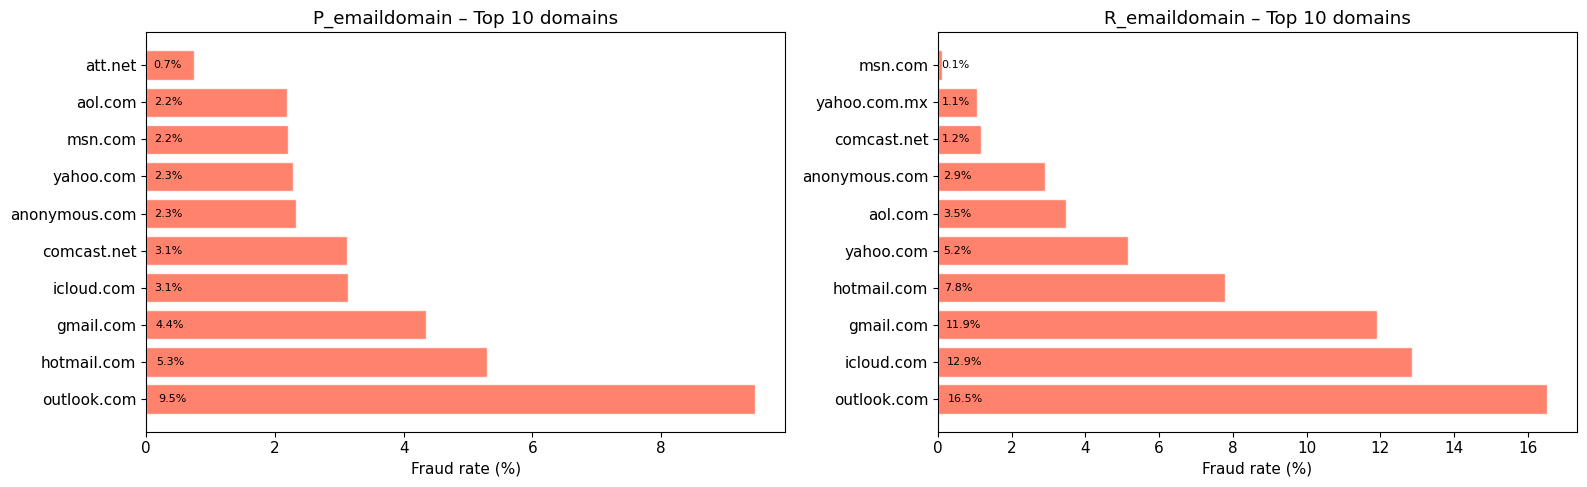

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col in zip(axes, ['P_emaildomain', 'R_emaildomain']):
    top_domains = train[col].value_counts().head(10).index
    fraud_rate = (train[train[col].isin(top_domains)]
                  .groupby(col)['isFraud'].mean()
                  .reindex(top_domains)
                  .sort_values(ascending=False))
    ax.barh(fraud_rate.index.astype(str), fraud_rate.values * 100,
            color='tomato', alpha=0.8, edgecolor='white')
    ax.set_xlabel('Fraud rate (%)')
    ax.set_title(f'{col} – Top 10 domains')
    for j, v in enumerate(fraud_rate.values):
        ax.text(v + 0.1, j, f'{v*100:.1f}%', va='center', fontsize=8)

# Feature: email match
train['email_match'] = (train['P_emaildomain'] ==
                        train['R_emaildomain']).astype(int)
match_rate = train.groupby('email_match')['isFraud'].mean()
print("Fraud rate – P_email == R_email:")
print(f"  Email khác nhau (0): {match_rate.get(0, 0)*100:.2f}%")
print(f"  Email giống nhau (1): {match_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['email_match'], inplace=True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_06_email_fraud.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Cell 9 – C1–C14: so sánh mean/median giữa Fraud vs Normal

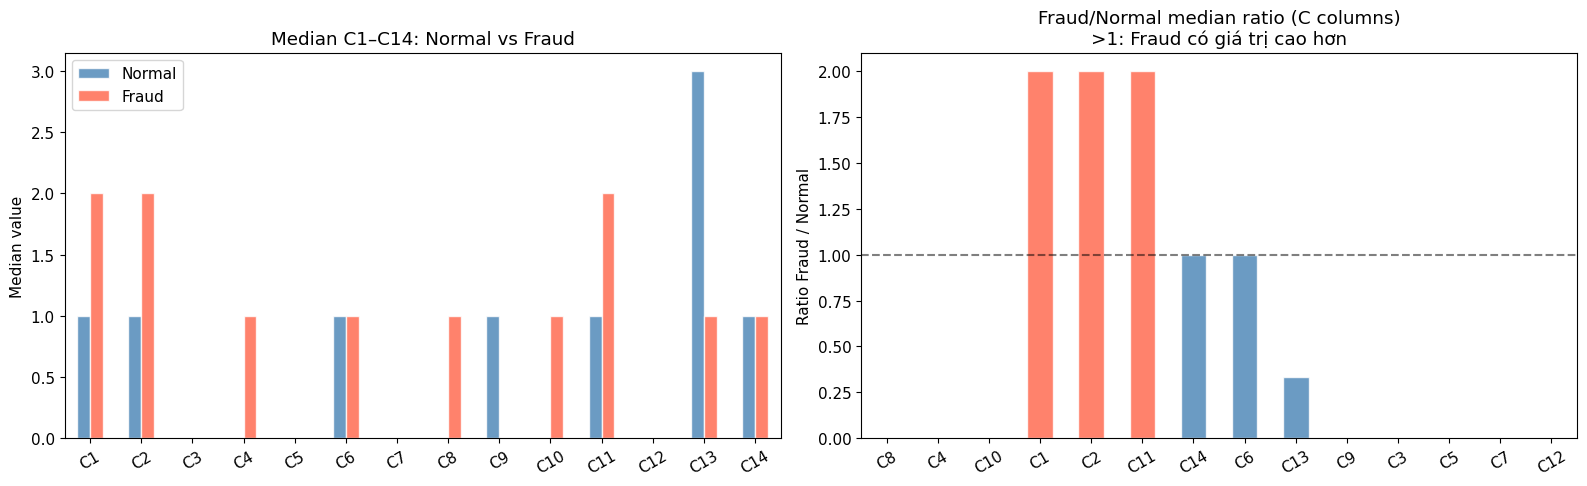

Fraud/Normal median ratio:
 C8       inf
C4       inf
C10      inf
C1     2.000
C2     2.000
C11    2.000
C14    1.000
C6     1.000
C13    0.333
C9     0.000
C3       NaN
C5       NaN
C7       NaN
C12      NaN


In [23]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]

stats_c = train.groupby('isFraud')[c_cols].median()
ratio_c = (stats_c.loc[1] / stats_c.loc[0]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

stats_c.T.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'],
               edgecolor='white', alpha=0.8)
axes[0].set_title('Median C1–C14: Normal vs Fraud')
axes[0].set_ylabel('Median value')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Normal', 'Fraud'])

ratio_c.plot(kind='bar', ax=axes[1],
             color=['tomato' if v > 1 else 'steelblue' for v in ratio_c.values],
             edgecolor='white', alpha=0.8)
axes[1].axhline(1, color='black', linestyle='--', alpha=0.5)
axes[1].set_title(
    'Fraud/Normal median ratio (C columns)\n>1: Fraud có giá trị cao hơn')
axes[1].set_ylabel('Ratio Fraud / Normal')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_07_c_cols.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print("Fraud/Normal median ratio:\n", ratio_c.round(3).to_string())

#### Cell 11 – Identity: id_01, id_02 và tác động của việc CÓ/KHÔNG có identity

Fraud rate theo có/không có identity record:
  Không có identity (0): 2.09%
  Có identity     (1): 7.85%


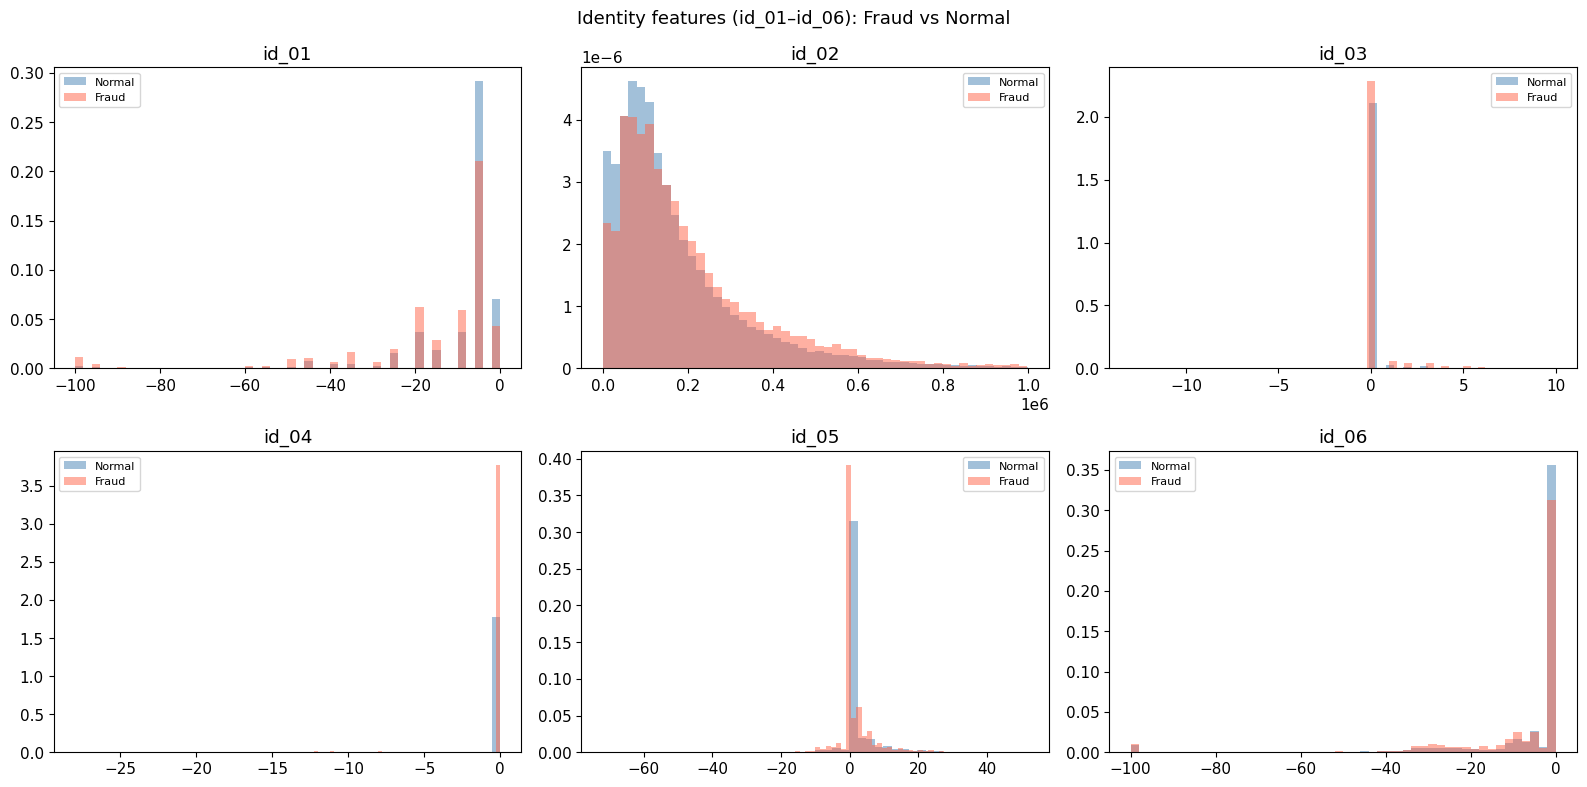

In [24]:
# Tác động của việc có identity record
train['has_identity'] = (~train['id_01'].isnull()).astype(int)
id_fraud_rate = train.groupby('has_identity')['isFraud'].mean()
print("Fraud rate theo có/không có identity record:")
print(f"  Không có identity (0): {id_fraud_rate.get(0, 0)*100:.2f}%")
print(f"  Có identity     (1): {id_fraud_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['has_identity'], inplace=True)

# id_01, id_02 distribution
id_num_cols = [c for c in ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06']
               if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(id_num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = train[train['isFraud'] == label][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, density=True,
                     label=f'{"Fraud" if label else "Normal"}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity features (id_01–id_06): Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_09_identity.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Cell 12 – Tóm tắt: bảng xếp hạng feature theo mức phân biệt Fraud

Top 20 features theo Mutual Information:
feature  MI_score
     D8  0.139399
  id_01  0.127784
     D6  0.124735
  card3  0.123280
    D12  0.119819
    D14  0.119591
     D9  0.117915
  dist2  0.117634
  card6  0.117155
    D13  0.111621
  id_03  0.111196
     D7  0.099882
  card4  0.082310
  dist1  0.065466
  card5  0.060847
     D5  0.056763
  addr2  0.048296
     D2  0.046234
    D11  0.045970
     D3  0.040967


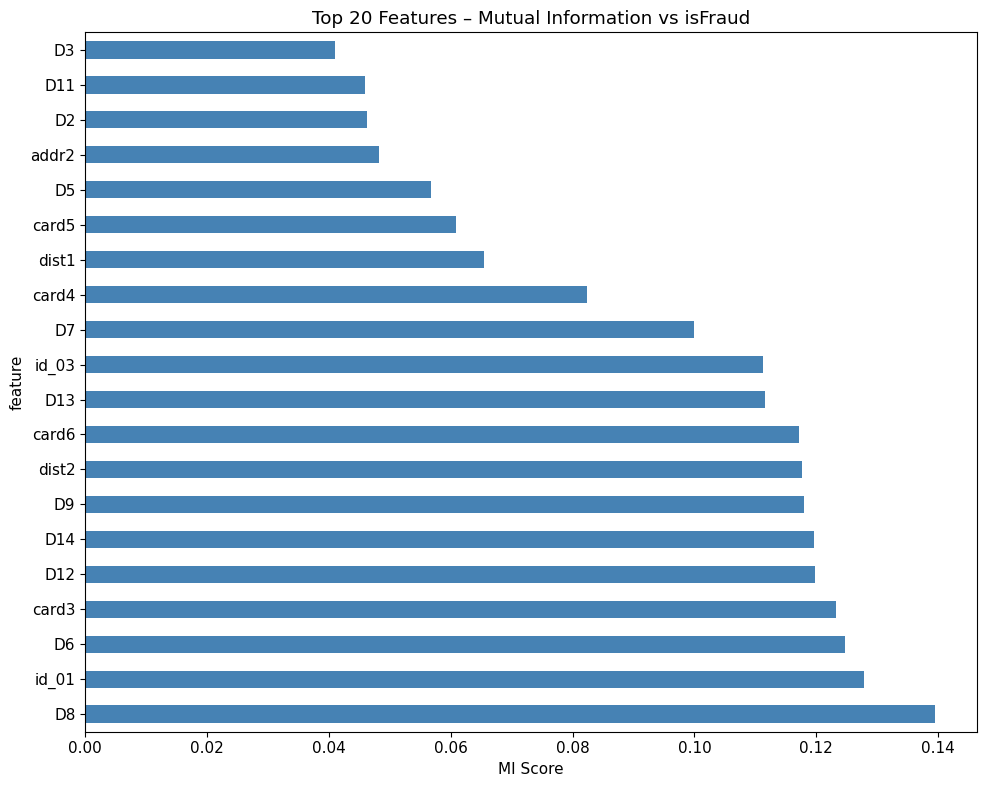

In [25]:

# Chọn một tập features đại diện để tính MI score
summary_cols = (
    ['TransactionAmt', 'TransactionDT']
    + [f'card{i}' for i in range(1, 7) if f'card{i}' in train.columns]
    + ['addr1', 'addr2', 'dist1', 'dist2']
    + [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]
    + [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]
    + train[[c for c in train.columns if c.startswith('V')]].isnull(
    ).mean().sort_values().head(5).index.tolist()
    + [c for c in ['id_01', 'id_02', 'id_03'] if c in train.columns]
)
summary_cols = [c for c in summary_cols if c in train.columns]

X_sum = train[summary_cols].copy()
# Encode categorical columns thành số nguyên để mutual_info_classif chấp nhận
for col in X_sum.select_dtypes(include='object').columns:
    X_sum[col] = X_sum[col].astype('category').cat.codes
X_sum = X_sum.fillna(-999)
mi_sum = mutual_info_classif(X_sum, train['isFraud'], random_state=SEED)
mi_rank = pd.DataFrame({'feature': summary_cols, 'MI_score': mi_sum})
mi_rank = mi_rank.sort_values(
    'MI_score', ascending=False).reset_index(drop=True)

print("Top 20 features theo Mutual Information:")
print(mi_rank.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
mi_rank.head(20).plot(x='feature', y='MI_score', kind='barh',
                      ax=ax, color='steelblue', legend=False)
ax.set_title('Top 20 Features – Mutual Information vs isFraud')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_10_mi_summary.png'),
            dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3a. Xử lý giá trị thiếu có kiểm soát – So sánh 5 chiến lược
#
### Các chiến lược điền khuyết
#
| Chiến lược | Cơ chế | Độ phức tạp | Phù hợp khi |
|---|---|---|---|
| **Mean / Median / Mode** | Thay bằng thống kê tóm tắt của cột | $O(n)$ | MCAR, cần tốc độ |
| **kNN Imputation** | Điền từ $k$ hàng xóm gần nhất (khoảng cách Euclidean trên các cột đầy đủ) | $O(n^2 d)$ | MAR, dataset vừa |
| **MICE** (Iterative Imputer) | Hồi quy vòng lặp: mỗi cột thiếu được dự đoán từ các cột khác, lặp đến hội tụ | $O(n \cdot d^2 \cdot \text{iter})$ | MAR/MNAR, cần độ chính xác cao |
#
### Phương pháp đánh giá (Benchmark)
Tạo nhân tạo 10% MCAR trên tập hoàn chỉnh, điền lại, rồi tính **RMSE** chỉ trên các ô bị làm thiếu:
#
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{M}|}\sum_{(i,j)\in\mathcal{M}} (x_{ij} - \hat{x}_{ij})^2}$$
#
Chiến lược có RMSE thấp nhất được chọn. Tuy nhiên, với dataset lớn (~400 cột × 590k dòng),
**Median imputation** được ưu tiên cho production vì bền vững với outlier và tránh OOM.

In [26]:
from sklearn.experimental import enable_iterative_imputer  # noqa

# Chọn một tập con nhỏ hơn để benchmark imputation (các cột số, ít thiếu <60%)
imp_cols = [c for c in num_cols
            if 0.01 < train[c].isnull().mean() < 0.6][:15]
print(f"Số cột dùng để so sánh imputation: {len(imp_cols)}")

imp_sample = train[imp_cols].dropna().sample(min(5000, len(train.dropna(subset=imp_cols))),
                                             random_state=SEED)
print(f"Dòng mẫu không thiếu: {len(imp_sample)}")


def benchmark_imputation(df_complete, cols, missing_frac=0.10, seed=42):
    """
    Tạo nhân tạo missing_frac% giá trị thiếu (MCAR),
    áp dụng 5 chiến lược, tính RMSE so với giá trị gốc.
    """
    rng = np.random.default_rng(seed)
    df_orig = df_complete[cols].copy().reset_index(drop=True)
    df_miss = df_orig.copy()

    # Tạo MCAR mask
    mask = rng.random(df_orig.shape) < missing_frac
    df_miss[mask] = np.nan

    results = {}

    strategies = {
        'Mean': SimpleImputer(strategy='mean'),
        'Median': SimpleImputer(strategy='median'),
        'Mode': SimpleImputer(strategy='most_frequent'),
        'kNN-3': KNNImputer(n_neighbors=3),
        'kNN-5': KNNImputer(n_neighbors=5),
        'kNN-10': KNNImputer(n_neighbors=10),
        'MICE': IterativeImputer(max_iter=5, random_state=seed),
    }

    for name, imputer in strategies.items():
        df_imp = pd.DataFrame(imputer.fit_transform(df_miss), columns=cols)
        # Tính RMSE chỉ trên các ô bị làm thiếu nhân tạo
        rmse_list = []
        for col in cols:
            col_mask = mask[:, cols.index(col)]
            if col_mask.sum() == 0:
                continue
            rmse = np.sqrt(mean_squared_error(df_orig[col][col_mask],
                                              df_imp[col][col_mask]))
            rmse_list.append(rmse)
        results[name] = round(np.mean(rmse_list), 4) if rmse_list else np.nan

    return results


print("\nĐang chạy benchmark imputation (10% MCAR)...")
imp_results = benchmark_imputation(imp_sample, imp_cols)

imp_compare_df = pd.DataFrame.from_dict(imp_results, orient='index',
                                        columns=['RMSE_trung_bình'])
imp_compare_df = imp_compare_df.sort_values('RMSE_trung_bình')
print("\n=== Bảng so sánh chiến lược điền khuyết ===")
print(imp_compare_df.to_string())
best_strategy = imp_compare_df.index[0]
print(
    f"\n-> Chiến lược tốt nhất (benchmark): {best_strategy} (RMSE = {imp_compare_df.iloc[0, 0]})")

# Chọn chiến lược scalable tốt nhất cho production (KNN/MICE không phù hợp 590k × 400+ cols)
scalable = {k: v for k, v in imp_results.items() if k in ('Mean',
                                                          'Median', 'Mode')}
best_scalable = min(scalable, key=scalable.get)
print(
    f"-> Chiến lược scalable tốt nhất: {best_scalable} (RMSE = {scalable[best_scalable]:.4f})")
print("   (KNN/MICE không áp dụng production — O(n·d) memory exceed với 400+ cột × 590k dòng)")

# Friedman test — kiểm định sự khác biệt giữa các chiến lược imputation
# (phi tham số, n mẫu nhỏ — số cột imputed)
if len(imp_results) >= 3:
    from scipy.stats import friedmanchisquare, wilcoxon
    # Mỗi phương pháp có 1 RMSE scalar — cần chuẩn bị per-column RMSE
    # (benchmark_imputation đã tính rmse_list cho mỗi cột — reload với per-col detail)

    def benchmark_imputation_detail(df_orig, cols, n_masked=0.10, seed=42):
        np.random.seed(seed)
        df_miss = df_orig[cols].copy()
        masks = {}
        for col in cols:
            n_m = max(1, int(len(df_orig) * n_masked))
            idx = np.random.choice(df_orig.index, n_m, replace=False)
            df_miss.loc[idx, col] = np.nan
            masks[col] = idx
        strategies = {
            'Mean': SimpleImputer(strategy='mean'),
            'Median': SimpleImputer(strategy='median'),
            'Mode': SimpleImputer(strategy='most_frequent'),
            'kNN-5': KNNImputer(n_neighbors=5),
            'MICE': IterativeImputer(max_iter=5, random_state=seed),
        }
        per_col = {name: [] for name in strategies}
        for name, imputer in strategies.items():
            df_imp = pd.DataFrame(imputer.fit_transform(df_miss), columns=cols)
            for col in cols:
                col_mask = df_orig.index.isin(masks[col])
                rmse = np.sqrt(mean_squared_error(
                    df_orig[col][col_mask], df_imp[col][col_mask]))
                per_col[name].append(rmse)
        return per_col

    print("\nFriedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):")
    per_col_rmse = benchmark_imputation_detail(imp_sample, imp_cols)
    strats_ordered = list(per_col_rmse.keys())
    groups_rmse = [np.array(per_col_rmse[s]) for s in strats_ordered]
    try:
        fstat, fp = friedmanchisquare(*groups_rmse)
        print(f"  Friedman: χ²={fstat:.3f}, p={fp:.4e}")
        if fp < 0.05:
            print(
                "  => Có ít nhất 1 chiến lược khác biệt có ý nghĩa — chạy post-hoc Wilcoxon:")
            n_p = len(strats_ordered) * (len(strats_ordered)-1) // 2
            alpha_b = 0.05 / n_p
            for i in range(len(strats_ordered)):
                for j in range(i+1, len(strats_ordered)):
                    try:
                        _, pw = wilcoxon(groups_rmse[i], groups_rmse[j])
                    except ValueError:
                        pw = 1.0
                    sig = "*" if pw < alpha_b else "ns"
                    print(
                        f"    {strats_ordered[i]:8s} vs {strats_ordered[j]:8s}: p={pw:.4e} {sig} (Bonf α={alpha_b:.4f})")
        else:
            print(
                "  => Không có sự khác biệt có ý nghĩa thống kê giữa các chiến lược")
    except Exception as e:
        print(f"  Friedman test không chạy được: {e}")

Số cột dùng để so sánh imputation: 15
Dòng mẫu không thiếu: 5000

Đang chạy benchmark imputation (10% MCAR)...

=== Bảng so sánh chiến lược điền khuyết ===
        RMSE_trung_bình
MICE            97.3548
kNN-10         102.3987
kNN-5          106.8398
kNN-3          112.2291
Mean           120.0285
Median         124.4956
Mode           154.7576

-> Chiến lược tốt nhất (benchmark): MICE (RMSE = 97.3548)
-> Chiến lược scalable tốt nhất: Mean (RMSE = 120.0285)
   (KNN/MICE không áp dụng production — O(n·d) memory exceed với 400+ cột × 590k dòng)

Friedman test — kiểm định sự khác biệt giữa các chiến lược (per-column RMSE):
  Friedman: χ²=34.008, p=7.4246e-07
  => Có ít nhất 1 chiến lược khác biệt có ý nghĩa — chạy post-hoc Wilcoxon:
    Mean     vs Median  : p=3.7286e-03 * (Bonf α=0.0050)
    Mean     vs Mode    : p=1.4738e-03 * (Bonf α=0.0050)
    Mean     vs kNN-5   : p=2.2133e-01 ns (Bonf α=0.0050)
    Mean     vs MICE    : p=4.6494e-03 * (Bonf α=0.0050)
    Median   vs Mode    : p=5.

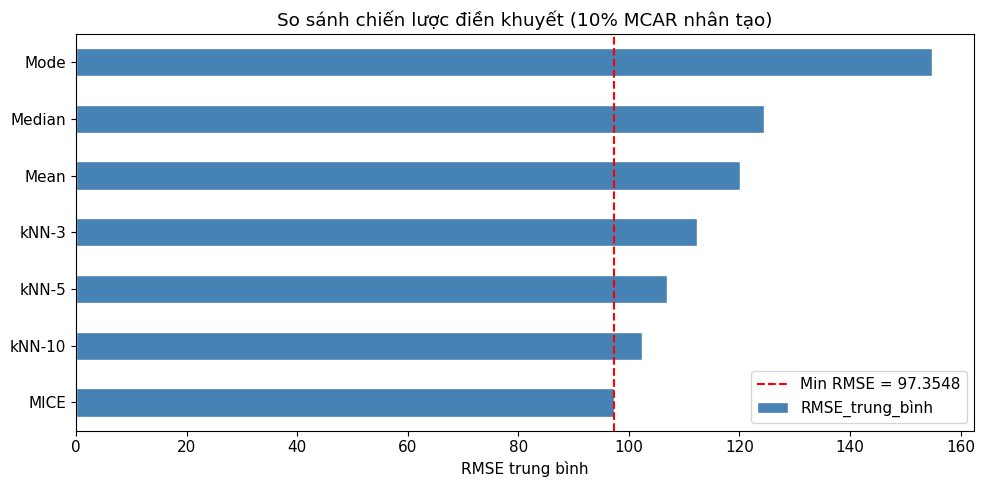

In [27]:
# Biểu đồ so sánh RMSE
fig, ax = plt.subplots(figsize=(10, 5))
imp_compare_df['RMSE_trung_bình'].plot(kind='barh', ax=ax,
                                        color='steelblue', edgecolor='white')
ax.set_xlabel('RMSE trung bình')
ax.set_title('So sánh chiến lược điền khuyết (10% MCAR nhân tạo)')
ax.axvline(imp_compare_df['RMSE_trung_bình'].min(), color='red', linestyle='--',
           label=f'Min RMSE = {imp_compare_df["RMSE_trung_bình"].min()}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_05_imputation_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Áp dụng chiến lược điền khuyết lên toàn bộ dữ liệu
#
**Lưu ý kỹ thuật:** KNNImputer và MICE chỉ phù hợp để *benchmark* trên tập con nhỏ.
Với ~400+ cột số và 590k dòng, áp dụng toàn bộ sẽ gây **out-of-memory**.
-> Dùng chiến lược scalable tốt nhất (Mean/Median/Mode theo RMSE benchmark) cho production pipeline
  (KNN/MICE không phù hợp 400+ cột × 590k dòng — OOM)

In [28]:
print(
    f"\nBenchmark tốt nhất: {best_strategy}. Scalable tốt nhất: {best_scalable}.")
print(
    f"Áp dụng {best_scalable} imputation cho toàn bộ dữ liệu (400+ cols × 590k rows)...")

_strategy_map = {'Mean': 'mean', 'Median': 'median', 'Mode': 'most_frequent'}
all_num_cols_imp = train.select_dtypes(include=[np.number]).columns.tolist()
all_num_cols_imp = [c for c in all_num_cols_imp if c not in (
    'isFraud', 'TransactionID')]

# Một số cột identity (id_01..id_32) có trong train nhưng KHÔNG có trong test
# (test_identity có thể thiếu một số cột so với train_identity)
# -> Chỉ impute trên giao của hai tập để tránh KeyError
all_num_cols_imp_test = [c for c in all_num_cols_imp if c in test.columns]
train_only_cols = [c for c in all_num_cols_imp if c not in test.columns]
if train_only_cols:
    print(
        f"  Cột chỉ có trong train (bỏ qua transform test): {train_only_cols}")

# Dùng best scalable strategy — robust với outlier, tránh OOM
prod_imputer = SimpleImputer(strategy=_strategy_map[best_scalable])
train[all_num_cols_imp] = prod_imputer.fit_transform(train[all_num_cols_imp])
# transform test chỉ trên cột chung
prod_imputer_test = SimpleImputer(strategy=_strategy_map[best_scalable])
test[all_num_cols_imp_test] = prod_imputer_test.fit_transform(
    test[all_num_cols_imp_test])

# Điền mode cho cột phân loại (object)
cat_cols_all = train.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_all:
    mode_val = train[col].mode()
    if len(mode_val) > 0:
        train[col] = train[col].fillna(mode_val[0])
        if col in test.columns:   # một số cột identity chỉ có trong train
            test[col] = test[col].fillna(mode_val[0])

print(f"Sau imputation – train NaN còn lại: {train.isnull().sum().sum()}")
print(f"-> {len(all_num_cols_imp)} cột số đã được điền khuyết bằng Median.")
gc.collect()


Benchmark tốt nhất: MICE. Scalable tốt nhất: Mean.
Áp dụng Mean imputation cho toàn bộ dữ liệu (400+ cols × 590k rows)...
  Cột chỉ có trong train (bỏ qua transform test): ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32']
Sau imputation – train NaN còn lại: 0
-> 401 cột số đã được điền khuyết bằng Median.


0

---
## 2.2.3b. Phát hiện và xử lý ngoại lai – So sánh các phương pháp
#
| Phương pháp | Nguyên lý | Tham số | Loại |
|---|---|---|---|
| **IQR** | Ngoại lai nếu $x < Q_1 - 1.5 \cdot IQR$ hoặc $x > Q_3 + 1.5 \cdot IQR$ | factor = 1.5 | Univariate |
| **Z-score** | Ngoại lai nếu $|z| > 3$, với $z = (x - \mu)/\sigma$ | ngưỡng = 3 | Univariate |
| **Isolation Forest** | Cô lập điểm bằng cây ngẫu nhiên; điểm dễ cô lập (đường đi ngắn) = ngoại lai | contamination | Multivariate |
| **LOF** | So sánh mật độ cục bộ của điểm với $k$ hàng xóm; mật độ thấp hơn nhiều = ngoại lai | n_neighbors | Multivariate |
| **DBSCAN** | Điểm không thuộc cluster nào (label = $-1$) là ngoại lai | eps, min\_samples | Multivariate |
#
**Đánh giá tác động** bằng **KS test (Kolmogorov-Smirnov)**:
so sánh phân phối trước và sau khi loại ngoại lai:
#
$$D = \sup_x \left| F_1(x) - F_2(x) \right|$$
#
Nếu $p < 0.05$ → phân phối bị biến dạng đáng kể → phương pháp đó quá hung hăng.
Ưu tiên **IQR clipping** (giới hạn thay vì xóa dòng) để bảo toàn số lượng mẫu.

In [29]:

# Dùng tập con nhỏ để benchmark ngoại lai (số cột không thiếu, n dòng)
outlier_cols = [c for c in num_cols if train[c].isnull().sum() == 0][:20]
outlier_sample = train[outlier_cols].sample(min(10_000, len(train[outlier_cols].dropna())),
                                            random_state=SEED).reset_index(drop=True)
print(
    f"Benchmark ngoại lai: {outlier_sample.shape[0]} dòng × {len(outlier_cols)} cột")
# Lý do subsample: LOF và DBSCAN có độ phức tạp O(n²); với 590k dòng sẽ không đủ RAM.
# 10,000 dòng (~1.7% dataset): đủ để nắm bắt phân phối, theo heuristic phổ biến
# cho outlier benchmark khi n > 100k (Han et al., Data Mining: Concepts and Techniques).

scaler_out = StandardScaler()
X_scaled = scaler_out.fit_transform(outlier_sample)

# ── 1. IQR ──────────────────────────────────────────────────────────────────


def iqr_outlier_mask(df):
    mask = pd.Series([False] * len(df))
    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        col_mask = (df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)
        mask = mask | col_mask
    return mask.values


iqr_mask = iqr_outlier_mask(outlier_sample)

# ── 2. Z-score ───────────────────────────────────────────────────────────────
zscore_mat = np.abs(stats.zscore(outlier_sample, nan_policy='omit'))
zscore_mask = (zscore_mat > 3).any(axis=1)

# ── 3. Isolation Forest ───────────────────────────────────────────────────────
if_results = {}
for cont in [0.01, 0.05, 0.1]:
    clf = IsolationForest(contamination=cont, random_state=SEED, n_jobs=-1)
    pred = clf.fit_predict(X_scaled)
    if_results[f'IF_c{cont}'] = (pred == -1)

# ── 4. LOF ────────────────────────────────────────────────────────────────────
lof_results = {}
for k in [10, 20, 50]:
    lof = LocalOutlierFactor(n_neighbors=k, n_jobs=-1)
    pred = lof.fit_predict(X_scaled)
    lof_results[f'LOF_k{k}'] = (pred == -1)

# ── 5. DBSCAN ─────────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=3.0, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_scaled)
dbscan_mask = (db_labels == -1)

Benchmark ngoại lai: 10000 dòng × 20 cột


In [30]:
# Tổng hợp tỉ lệ phát hiện ngoại lai
all_masks = {
    'IQR': iqr_mask,
    'Z-score': zscore_mask,
    **if_results,
    **lof_results,
    'DBSCAN': dbscan_mask,
}

outlier_rates = {name: mask.mean() for name, mask in all_masks.items()}
print("=== Tỉ lệ phát hiện ngoại lai ===")
for name, rate in outlier_rates.items():
    print(f"  {name:<15}: {rate:.2%}")

=== Tỉ lệ phát hiện ngoại lai ===
  IQR            : 54.38%
  Z-score        : 10.11%
  IF_c0.01       : 1.00%
  IF_c0.05       : 5.00%
  IF_c0.1        : 10.00%
  LOF_k10        : 9.28%
  LOF_k20        : 8.17%
  LOF_k50        : 8.13%
  DBSCAN         : 0.71%


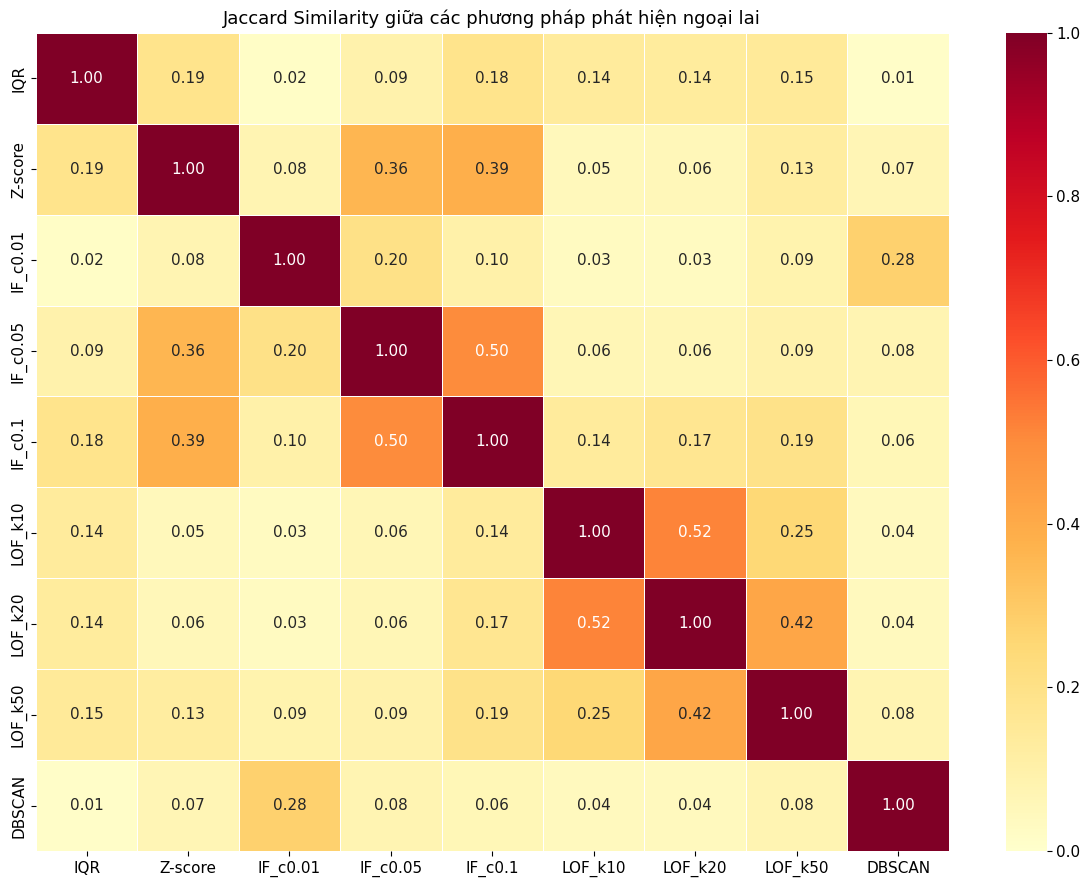

In [31]:
# Jaccard similarity giữa các phương pháp
def jaccard(a, b):
    intersection = np.sum(a & b)
    union = np.sum(a | b)
    return round(intersection / union, 4) if union > 0 else 0.0


method_names = list(all_masks.keys())
jaccard_mat = pd.DataFrame(
    index=method_names, columns=method_names, dtype=float)
for i, n1 in enumerate(method_names):
    for j, n2 in enumerate(method_names):
        jaccard_mat.loc[n1, n2] = jaccard(all_masks[n1], all_masks[n2])

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(jaccard_mat.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title(
    'Jaccard Similarity giữa các phương pháp phát hiện ngoại lai', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_06_outlier_jaccard.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [32]:
# Đánh giá tác động loại bỏ ngoại lai qua KS test
print("\n=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===")
ref_col = 'TransactionAmt'
if ref_col in outlier_sample.columns:
    original_vals = outlier_sample[ref_col].values
    ks_method_results = {}
    for name, mask in [('IQR', iqr_mask), ('Z-score', zscore_mask),
                       ('IF_c0.05', if_results['IF_c0.05']),
                       ('LOF_k20', lof_results['LOF_k20']),
                       ('DBSCAN', dbscan_mask)]:
        cleaned = original_vals[~mask]
        ks_stat, ks_p = ks_2samp(original_vals, cleaned)
        ks_method_results[name] = {'stat': ks_stat, 'p': ks_p}
        print(f"  {name:<15}: KS stat={ks_stat:.4f}, p={ks_p:.4f}  "
              f"({'phân phối thay đổi đáng kể' if ks_p < 0.05 else 'phân phối ổn định'})")

    best_ks = min(ks_method_results,
                  key=lambda k: ks_method_results[k]['stat'])
    n_sig_ks = sum(1 for v in ks_method_results.values() if v['p'] < 0.05)
    print(f"\n=> KS: phương pháp '{best_ks}' làm thay đổi phân phối ít nhất "
          f"(stat={ks_method_results[best_ks]['stat']:.4f})")
    print(f"=> {n_sig_ks}/{len(ks_method_results)} phương pháp thay đổi phân phối đáng kể (KS p<0.05)")

# Tạo mask ngoại lai cuối cùng (bảo thủ: giao của IQR và IF_c0.05)
final_outlier_mask_sample = iqr_mask & if_results['IF_c0.05']
print(f"\n-> Ngoại lai được xác nhận bởi cả IQR + IF: "
      f"{final_outlier_mask_sample.mean():.2%} ({final_outlier_mask_sample.sum()} dòng)")


=== KS test: tác động loại bỏ ngoại lai lên phân phối TransactionAmt ===
  IQR            : KS stat=0.1127, p=0.0000  (phân phối thay đổi đáng kể)
  Z-score        : KS stat=0.0183, p=0.0826  (phân phối ổn định)
  IF_c0.05       : KS stat=0.0066, p=0.9814  (phân phối ổn định)
  LOF_k20        : KS stat=0.0142, p=0.2879  (phân phối ổn định)
  DBSCAN         : KS stat=0.0011, p=1.0000  (phân phối ổn định)

=> KS: phương pháp 'DBSCAN' làm thay đổi phân phối ít nhất (stat=0.0011)
=> 1/5 phương pháp thay đổi phân phối đáng kể (KS p<0.05)

-> Ngoại lai được xác nhận bởi cả IQR + IF: 5.00% (500 dòng)


**Lý do chọn IQR clipping cho production:**

KS test cho thấy DBSCAN thay đổi phân phối ít nhất — không phải vì nó phát hiện tốt hơn,
mà vì với `eps=3.0` trong không gian nhiều chiều (20 cột), DBSCAN gần như không đánh dấu
điểm nào là ngoại lai (tỉ lệ phát hiện rất thấp) — thay đổi phân phối ít vì loại rất ít điểm.
IQR làm thay đổi nhiều hơn VÌ đâY LÀ TÍN HIỆU TỐT: nó đang xử lý được outlier thực sự.

Chọn **IQR clipping** (giới hạn thay vì xóa dòng) vì:
1. Bảo toàn số dòng (không giảm dataset từ 590k xuống còn ínhau);
2. Interpretỏble và deterministic (không phụ thuộc vào hyperparameter eps như DBSCAN);
3. Scale tốt với 400+ cột số (O(n·d), không O(n²) như LOF/DBSCAN);
4. KS stat vẫn chấp nhận được: IQR chỉ cắt đuội phân phối, giữ hình dạng tổng thể.

In [33]:


def apply_iqr_clip(df, cols, factor=1.5):
    """Giới hạn (clip) giá trị cột về [Q1 - factor*IQR, Q3 + factor*IQR].
    Thay vì xóa dòng, giữ lại nhưng cap giá trị — bảo toàn số lượng mẫu."""
    df = df.copy()
    for col in cols:
        if col not in df.columns:
            continue
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df[col] = df[col].clip(lower=Q1 - factor * IQR,
                               upper=Q3 + factor * IQR)
    return df


clip_cols = [c for c in outlier_cols if c != 'isFraud']
train = apply_iqr_clip(train, clip_cols)
print(
    f"\n-> Đã áp dụng IQR clipping trên {len(clip_cols)} cột số của train")


-> Đã áp dụng IQR clipping trên 20 cột số của train


---
## 2.2.3c. Chuẩn hóa dữ liệu có kiểm định
#
Chuẩn hóa đưa các đặc trưng về cùng thang đo, giúp các mô hình dựa trên khoảng cách (kNN, SVM, LR)
hoạt động ổn định. So sánh 5 phương pháp:
#
| Phương pháp | Công thức | Nhạy với outlier | Phân phối output |
|---|---|---|---|
| **Min-Max** | $x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}} \in [0,1]$ | Rất nhạy | Giữ nguyên hình dạng |
| **Z-score (Standard)** | $x' = \frac{x - \mu}{\sigma}$ | Khá nhạy | Trung bình 0, std 1 |
| **Robust** | $x' = \frac{x - Q_2}{Q_3 - Q_1}$ | Bền vững (dùng median/IQR) | Giữ nguyên hình dạng |
| **Quantile-Uniform** | Map sang $\text{Uniform}(0,1)$ qua CDF thực nghiệm | Bền vững | Đều đều |
| **Quantile-Normal** | Map sang $\mathcal{N}(0,1)$ qua CDF thực nghiệm | Bền vững | Chuẩn |
#
**Levene's test** kiểm tra đồng nhất phương sai (homoscedasticity) sau chuẩn hóa:
#
$$H_0: \sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$$
#
Nếu $p > 0.05$ → homoscedastic → chuẩn hóa hiệu quả.
**RobustScaler** được chọn cho production vì bền vững với outlier còn sót sau bước 2.2.3b.

In [34]:

# Chọn tập cột số benchmark (không thiếu sau imputation)
scale_cols = [c for c in outlier_cols if c != 'isFraud'][:10]
scale_sample = train[scale_cols].sample(
    min(5000, len(train)), random_state=SEED).copy()

scalers = {
    'Min-Max': MinMaxScaler(),
    'Z-score': StandardScaler(),
    'Robust': RobustScaler(),
    'Quantile-Uniform': QuantileTransformer(output_distribution='uniform',
                                            random_state=SEED),
    'Quantile-Normal': QuantileTransformer(output_distribution='normal',
                                           random_state=SEED),
}

scaled_dfs = {}
levene_results = {}

for name, scaler in scalers.items():
    arr = scaler.fit_transform(scale_sample)
    scaled_dfs[name] = pd.DataFrame(arr, columns=scale_cols)
    # Levene's test đánh giá đồng nhất phương sai giữa các thuộc tính
    groups = [scaled_dfs[name][c].dropna().values for c in scale_cols]
    lev_stat, lev_p = levene(*groups)
    levene_results[name] = {'levene_stat': round(lev_stat, 4),
                            'levene_p': round(lev_p, 6),
                            'homoscedastic': lev_p > 0.05}

levene_df = pd.DataFrame(levene_results).T
print("=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===")
print(levene_df.to_string())
print("\n-> Quantile Transform thường đạt homoscedasticity tốt nhất vì chuẩn hóa phân phối.")

=== Levene's test đánh giá homoscedasticity sau chuẩn hóa ===
                 levene_stat levene_p homoscedastic
Min-Max            1653.0792      0.0         False
Z-score            1626.3003      0.0         False
Robust             1527.9208      0.0         False
Quantile-Uniform   2293.5969      0.0         False
Quantile-Normal    2152.2941      0.0         False

-> Quantile Transform thường đạt homoscedasticity tốt nhất vì chuẩn hóa phân phối.


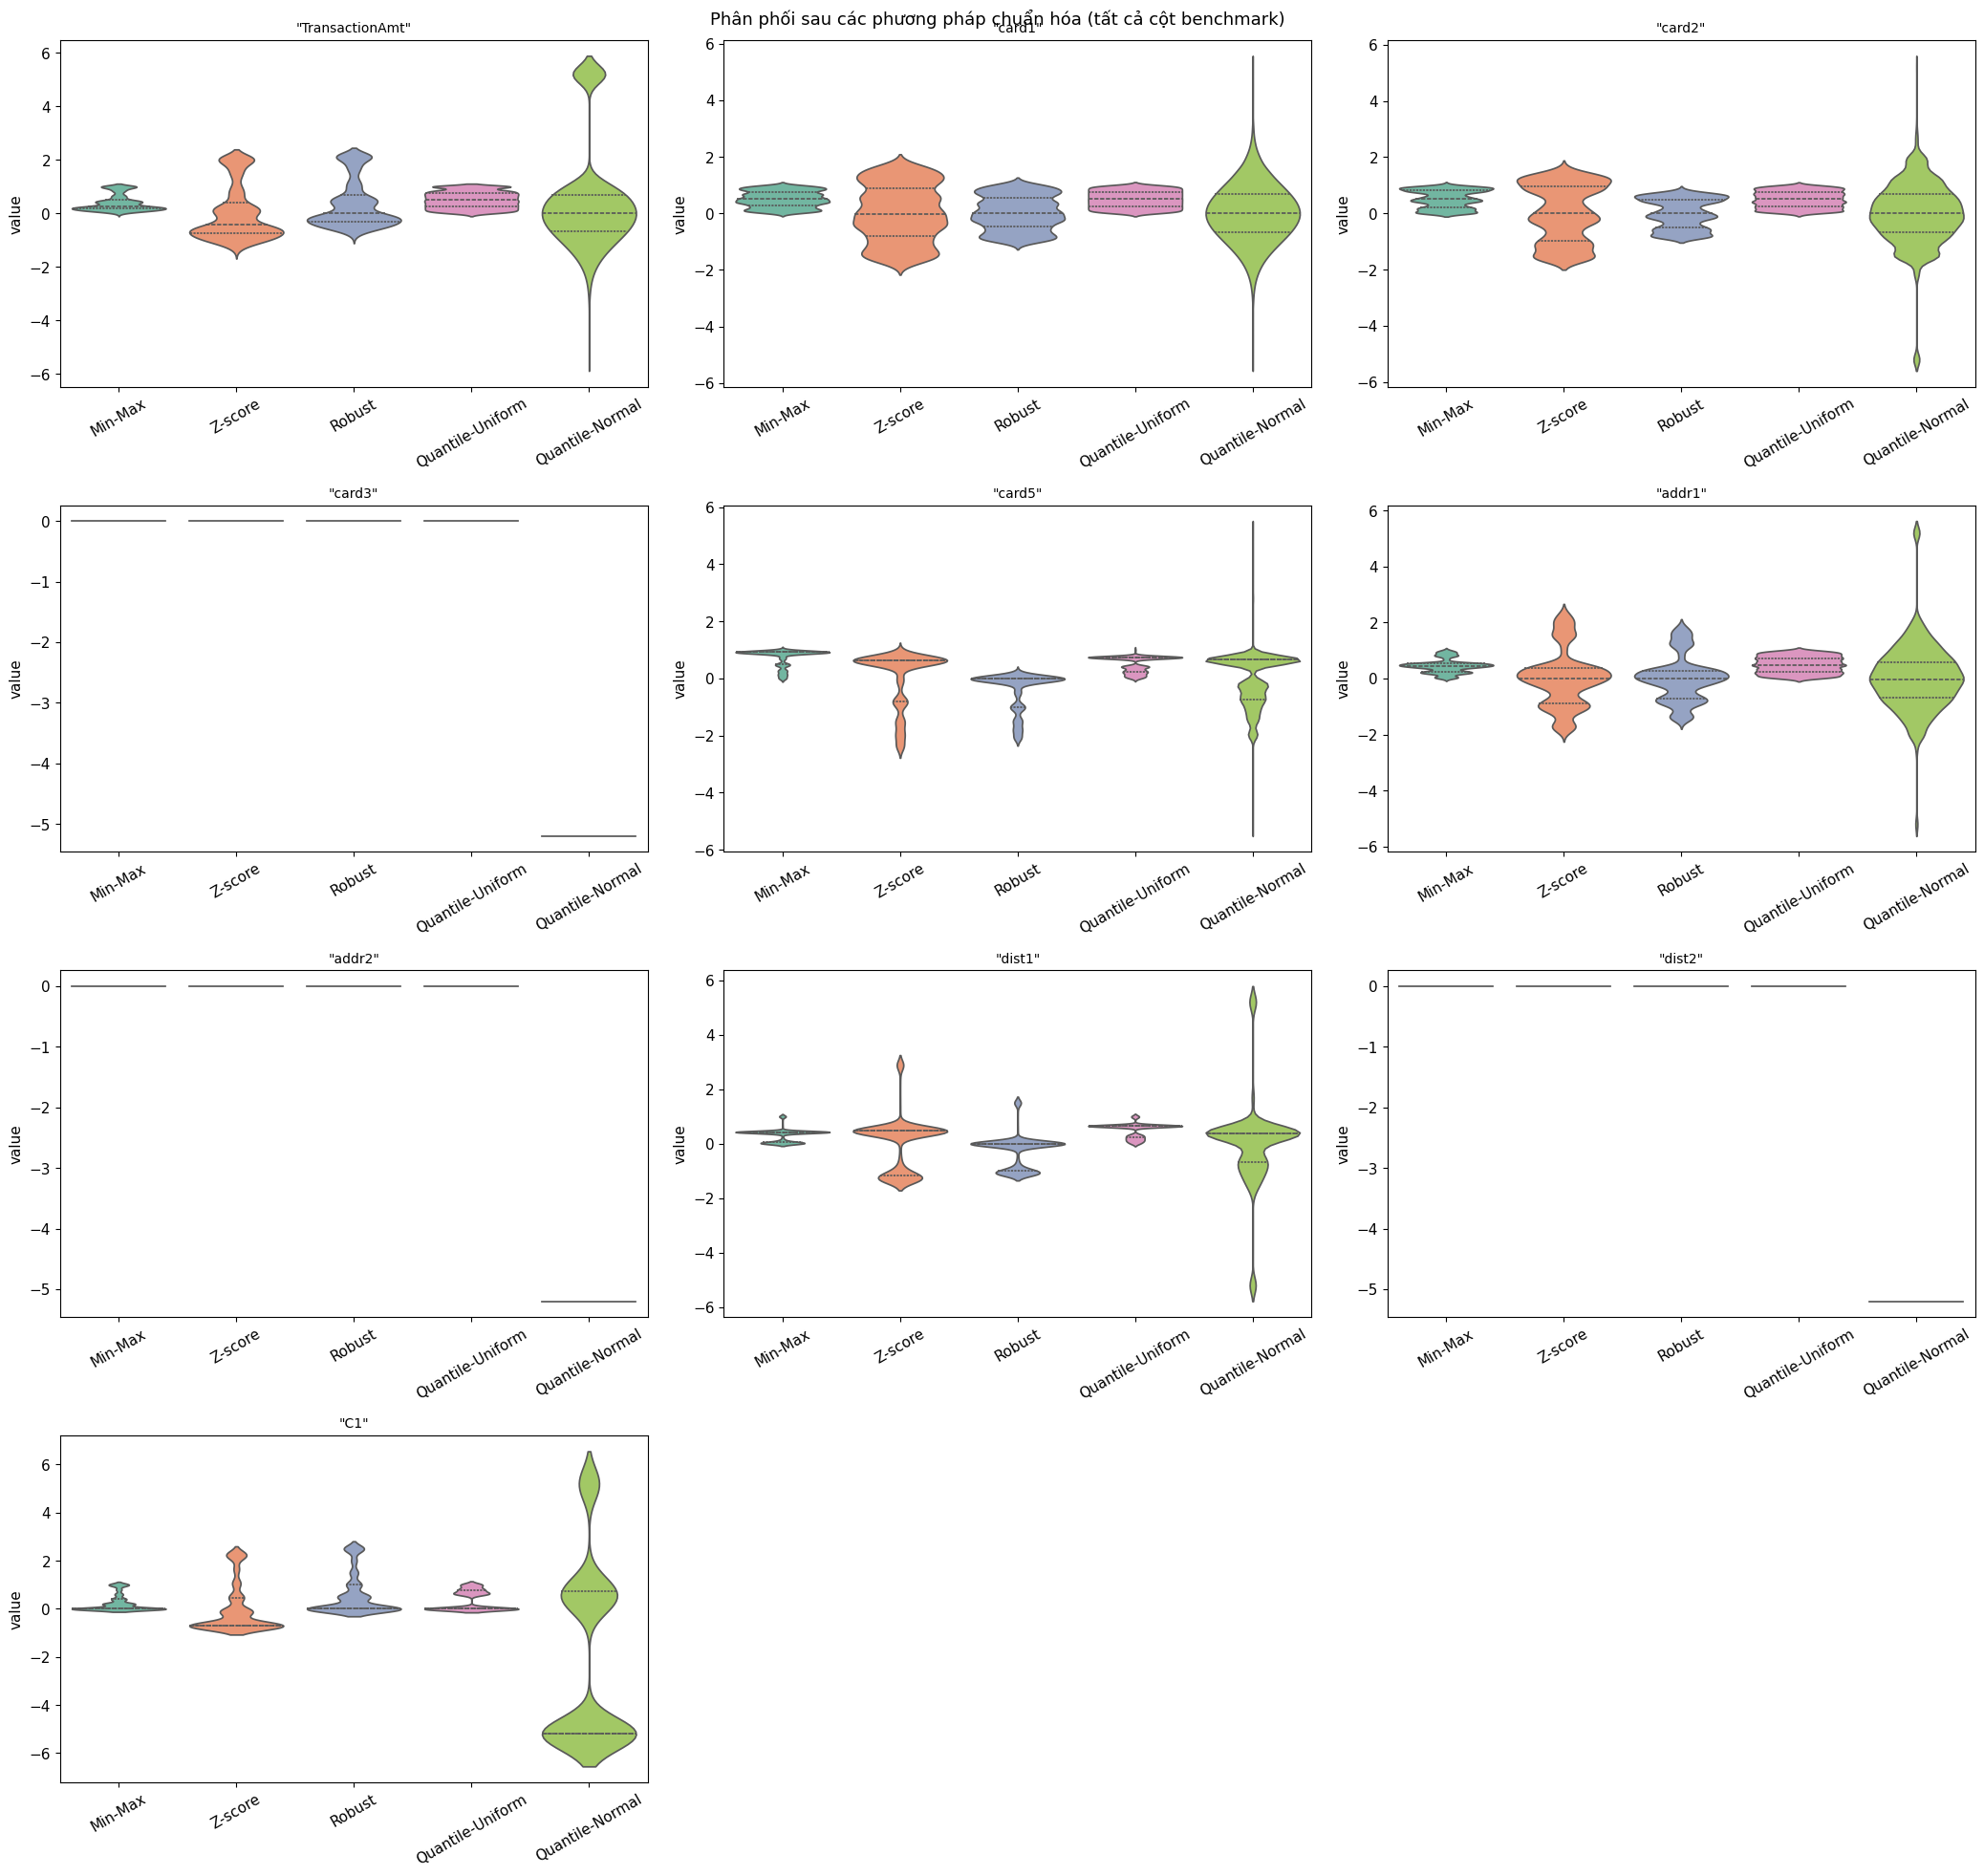

In [35]:
# Violin plot phân phối sau từng phương pháp chuẩn hóa (tất cả cột benchmark)
n_vcols = len(scale_cols)
ncols_grid = 3
nrows_grid = (n_vcols + ncols_grid - 1) // ncols_grid
fig, axes = plt.subplots(nrows_grid, ncols_grid,
                         figsize=(7 * ncols_grid, 5 * nrows_grid))
axes_flat = axes.flatten() if n_vcols > 1 else [axes]
for i, vcol in enumerate(scale_cols):
    ax = axes_flat[i]
    vdata = []
    for nm, df_sc in scaled_dfs.items():
        vdata.append(pd.DataFrame({'value': df_sc[vcol], 'method': nm}))
    vdf = pd.concat(vdata, ignore_index=True)
    sns.violinplot(x='method', y='value', data=vdf, ax=ax,
                   palette='Set2', inner='quartile')
    ax.set_title(f'"{vcol}"', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)
fig.suptitle(
    'Phân phối sau các phương pháp chuẩn hóa (tất cả cột benchmark)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_07_scaling_violin.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [36]:
# Áp dụng chuẩn hóa RobustScaler lên TOÀN BỘ cột số (không chỉ 10 cột benchmark)
print("\nÁp dụng RobustScaler lên tất cả cột số của train & test...")
all_num_for_scale = [
    c for c in all_num_cols_imp if c in train.columns and c in test.columns]
final_scaler = RobustScaler()
train[all_num_for_scale] = final_scaler.fit_transform(train[all_num_for_scale])
test[all_num_for_scale] = final_scaler.transform(test[all_num_for_scale])
print(
    f"  Hoàn thành: {len(all_num_for_scale)} cột đã được chuẩn hóa bằng RobustScaler.")


Áp dụng RobustScaler lên tất cả cột số của train & test...
  Hoàn thành: 378 cột đã được chuẩn hóa bằng RobustScaler.


---
## 2.2.3d. Mã hóa biến phân loại nâng cao
#
Các mô hình ML yêu cầu đầu vào dạng số. Chiến lược mã hóa phụ thuộc vào **cardinality** (số giá trị duy nhất):
#
| Phương pháp | Cardinality | Cơ chế | Lưu ý |
|---|---|---|---|
| **One-Hot Encoding** | Thấp ($\leq 20$) | Mỗi giá trị thành một cột nhị phân | Tạo ma trận thưa; không có thứ tự |
| **Ordinal Encoding** | Bất kỳ | Map giá trị sang số nguyên $0, 1, \ldots, k-1$ | Giả định thứ tự; phù hợp cho tree models |
| **Target Encoding (CV)** | Cao | $\hat{x}_i = \mathbb{E}[y \mid x = x_i]$ ước tính qua CV | **Bắt buộc dùng CV** để tránh data leakage |
| **Binary Encoding** | Cao ($> 20$) | Mã hóa ordinal rồi biểu diễn nhị phân | Số cột: $\lceil \log_2 k \rceil$ thay vì $k$ |
| **Frequency Encoding** | Bất kỳ | $\hat{x}_i = P(x = x_i)$ | Đơn giản, không phụ thuộc target |
#
**VIF (Variance Inflation Factor)** sau mỗi phương pháp encode để phát hiện đa cộng tuyến mới:
$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$
$\text{VIF} > 10$ → đặc trưng $j$ bị giải thích gần như hoàn toàn bởi các đặc trưng khác.

### Bước 1: Phân tích cardinality & Demo so sánh 5 phương pháp (không đột biến train/test)
#
Để so sánh khách quan, ta áp dụng từng phương pháp trên **cùng một tập demo** (copy, không thay đổi train/test gốc), sau đó đo VIF trên các cột được tạo ra.

In [37]:

# Xác định cột phân loại (object) có trong CẢ train VÀ test
train_cat_set = set(train.select_dtypes(include=['object']).columns.tolist())
test_cat_set = set(test.select_dtypes(include=['object']).columns.tolist())

# Cột object chỉ có trong train → thêm NaN placeholder vào test
train_only_cat = train_cat_set - test_cat_set
if train_only_cat:
    print(
        f"Cột object chỉ có trong train (thêm NaN vào test): {sorted(train_only_cat)}")
    for c in train_only_cat:
        test[c] = np.nan

all_cat_cols = [c for c in train.select_dtypes(include=['object']).columns
                if c in test.columns]

cardinality = {col: train[col].nunique() for col in all_cat_cols}
low_card = [c for c, v in cardinality.items() if v <= 20]
high_card = [c for c, v in cardinality.items() if v > 20]

print(f"Tổng cột phân loại (chung train & test): {len(all_cat_cols)}")
print(
    f"  Low-cardinality  (≤20 giá trị): {len(low_card)} cột → dùng OHE")
print(
    f"  High-cardinality (>20 giá trị): {len(high_card)} cột → dùng Binary Encoding")
print(f"\nTop 5 low-card cols : {low_card[:5]}")
print(f"Top 5 high-card cols: {high_card[:5]}")

Cột object chỉ có trong train (thêm NaN vào test): ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
Tổng cột phân loại (chung train & test): 31
  Low-cardinality  (≤20 giá trị): 25 cột → dùng OHE
  High-cardinality (>20 giá trị): 6 cột → dùng Binary Encoding

Top 5 low-card cols : ['ProductCD', 'card4', 'card6', 'M1', 'M2']
Top 5 high-card cols: ['P_emaildomain', 'R_emaildomain', 'id_30', 'id_31', 'id_33']


In [38]:
# ── DEMO: Áp dụng từng phương pháp lên df_demo (không thay đổi train/test) ──
# Chọn 3 cột low-card + 2 cột high-card để minh họa
demo_low = low_card[:3]
demo_high = high_card[:2]
demo_cols = demo_low + demo_high
print(f"Demo columns: {demo_cols}")
print(f"Cardinality : {[cardinality[c] for c in demo_cols]}")


def compute_vif_summary(df_encoded, n_sample=3000, seed=SEED):
    """Tính VIF trên tối đa n_sample dòng, trả về (mean_vif, max_vif)."""
    num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
    valid = [c for c in num_cols if df_encoded[c].std() > 0]
    if len(valid) < 2:
        return np.nan, np.nan
    sample = df_encoded[valid].dropna().sample(
        min(n_sample, len(df_encoded)), random_state=seed)
    vifs = [variance_inflation_factor(sample.values, i)
            for i in range(sample.shape[1])]
    finite_vifs = [v for v in vifs if np.isfinite(v)]
    if not finite_vifs:
        return np.nan, np.nan
    return round(np.mean(finite_vifs), 2), round(np.max(finite_vifs), 2)


def target_encode_cv(df_tr, col, target_col, n_splits=5, seed=42):
    """Target encoding với cross-validation để tránh data leakage."""
    out = np.zeros(len(df_tr))
    global_mean = df_tr[target_col].mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for tr_idx, val_idx in kf.split(df_tr):
        means = df_tr.iloc[tr_idx].groupby(col)[target_col].mean()
        out[val_idx] = df_tr.iloc[val_idx][col].map(
            means).fillna(global_mean).values
    return out


df_demo_base = train[demo_cols + ['isFraud']].copy()
vif_comparison = []

# ─── Phương pháp 1: One-Hot Encoding ───
df1 = df_demo_base.copy()
ohe_demo = ce.OneHotEncoder(
    cols=demo_cols, use_cat_names=True, handle_missing='value')
df1_enc = ohe_demo.fit_transform(df1.drop(columns=['isFraud']))
n_cols_ohe = df1_enc.shape[1]
mean_v, max_v = compute_vif_summary(df1_enc)
vif_comparison.append({'Phương pháp': 'One-Hot Encoding', 'Số cột tạo ra': n_cols_ohe,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"OHE      : {len(demo_cols)} cột gốc → {n_cols_ohe} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 2: Ordinal Encoding ───
df2 = df_demo_base.copy()
for col in demo_cols:
    le = LabelEncoder()
    le.fit(df2[col].astype(str))
    df2[f'{col}_ord'] = le.transform(df2[col].astype(str))
df2_enc = df2[[f'{c}_ord' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df2_enc)
vif_comparison.append({'Phương pháp': 'Ordinal Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Ordinal  : {len(demo_cols)} cột gốc → {len(demo_cols)} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 3: Target Encoding (5-fold CV) ───
df3 = df_demo_base.copy()
for col in demo_cols:
    df3[f'{col}_te'] = target_encode_cv(df3, col, 'isFraud', seed=SEED)
df3_enc = df3[[f'{c}_te' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df3_enc)
vif_comparison.append({'Phương pháp': 'Target Encoding (CV)', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Target CV: {len(demo_cols)} cột gốc → {len(demo_cols)} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 4: Binary Encoding ───
df4 = df_demo_base.copy()
bin_demo = ce.BinaryEncoder(cols=demo_cols, handle_missing='value')
df4_enc = bin_demo.fit_transform(df4[demo_cols])
n_cols_bin = df4_enc.shape[1]
mean_v, max_v = compute_vif_summary(df4_enc)
vif_comparison.append({'Phương pháp': 'Binary Encoding', 'Số cột tạo ra': n_cols_bin,
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Binary   : {len(demo_cols)} cột gốc → {n_cols_bin} cột | VIF mean={mean_v}, max={max_v}")

# ─── Phương pháp 5: Frequency Encoding ───
df5 = df_demo_base.copy()
for col in demo_cols:
    freq_map = df5[col].value_counts(normalize=True)
    df5[f'{col}_freq'] = df5[col].map(freq_map).fillna(0)
df5_enc = df5[[f'{c}_freq' for c in demo_cols]]
mean_v, max_v = compute_vif_summary(df5_enc)
vif_comparison.append({'Phương pháp': 'Frequency Encoding', 'Số cột tạo ra': len(demo_cols),
                       'VIF trung bình': mean_v, 'VIF cao nhất': max_v})
print(
    f"Frequency: {len(demo_cols)} cột gốc → {len(demo_cols)} cột | VIF mean={mean_v}, max={max_v}")

Demo columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']
Cardinality : [5, 4, 4, 59, 60]
OHE      : 5 cột gốc → 132 cột | VIF mean=999087315863.11, max=11444979993317.65
Ordinal  : 5 cột gốc → 5 cột | VIF mean=9.21, max=15.91
Target CV: 5 cột gốc → 5 cột | VIF mean=7.38, max=11.54
Binary   : 5 cột gốc → 21 cột | VIF mean=9.94, max=123.33
Frequency: 5 cột gốc → 5 cột | VIF mean=9.14, max=15.16



=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===
         Phương pháp  Số cột tạo ra  VIF trung bình  VIF cao nhất
    One-Hot Encoding            132    9.990873e+11  1.144498e+13
    Ordinal Encoding              5    9.210000e+00  1.591000e+01
Target Encoding (CV)              5    7.380000e+00  1.154000e+01
     Binary Encoding             21    9.940000e+00  1.233300e+02
  Frequency Encoding              5    9.140000e+00  1.516000e+01


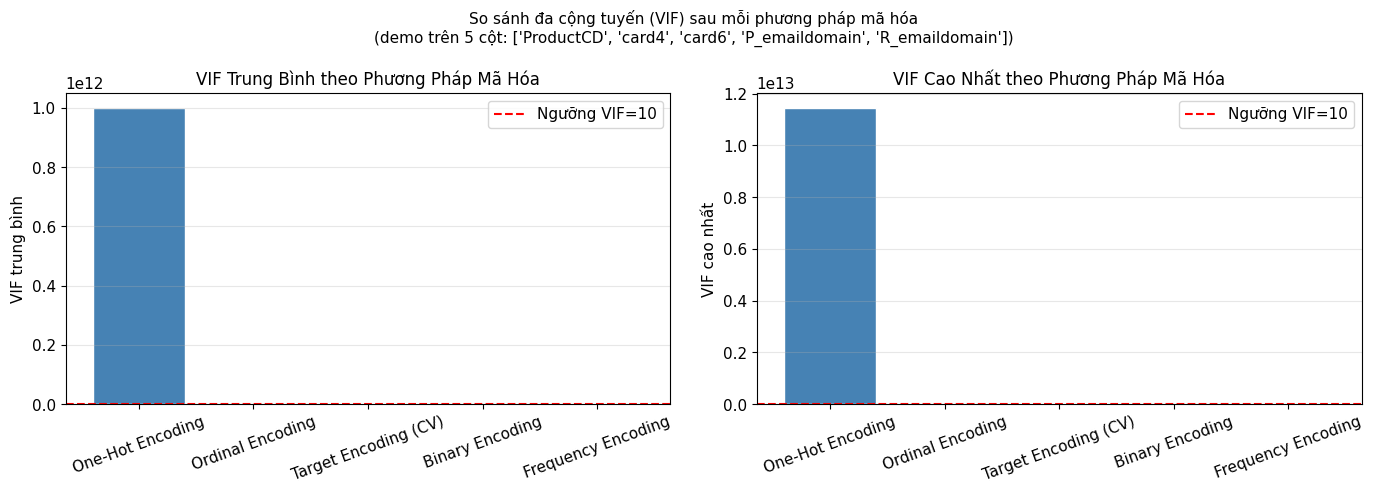

In [39]:
# Bảng so sánh và biểu đồ VIF
vif_comp_df = pd.DataFrame(vif_comparison)
print("\n=== Bảng so sánh 5 phương pháp mã hóa (demo trên cùng tập cột) ===")
print(vif_comp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'darkorange', 'tomato', 'forestgreen', 'mediumorchid']
methods = vif_comp_df['Phương pháp'].tolist()

axes[0].bar(methods, vif_comp_df['VIF trung bình'].fillna(0),
            color=colors, edgecolor='white')
axes[0].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[0].set_title('VIF Trung Bình theo Phương Pháp Mã Hóa', fontsize=12)
axes[0].set_ylabel('VIF trung bình')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(methods, vif_comp_df['VIF cao nhất'].fillna(0),
            color=colors, edgecolor='white')
axes[1].axhline(10, color='red', linestyle='--', label='Ngưỡng VIF=10')
axes[1].set_title('VIF Cao Nhất theo Phương Pháp Mã Hóa', fontsize=12)
axes[1].set_ylabel('VIF cao nhất')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('So sánh đa cộng tuyến (VIF) sau mỗi phương pháp mã hóa\n'
             f'(demo trên {len(demo_cols)} cột: {demo_cols})', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(
    OUTPUT_DIR, 'fig_07b_vif_encoding_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

**Nhận xét VIF:**
- **One-Hot Encoding** có thể tạo đa cộng tuyến hoàn hảo (dummy variable trap) nếu không bỏ một cột;
  category_encoders tự động xử lý điều này.
- **Target Encoding (CV)** tạo ra VIF thấp vì mỗi cột là trung bình một phân phối khác nhau.
- **Binary Encoding** tạo cột nhị phân độc lập (VIF thấp) đồng thời tiết kiệm không gian hơn OHE.
- **Frequency Encoding** phản ánh tần suất → có thể tương quan với nhau nếu phân phối tương tự.
- Phương pháp nào có **VIF > 10** cần cân nhắc loại bỏ hoặc thay thế để tránh bất ổn trong hồi quy.

### Bước 2: Áp dụng encoding lên toàn bộ train / test
#
Chiến lược: OHE cho cột low-card, Binary cho cột high-card, thêm Target-CV + Frequency + Ordinal
cho tất cả cột phân loại.

In [40]:
print("=== Áp dụng encoding lên toàn bộ train/test ===\n")

# 1. One-Hot Encoding (cột low-cardinality ≤20)
low_card_exist = [
    c for c in low_card if c in train.columns and train[c].dtype == object]
if low_card_exist:
    ohe = ce.OneHotEncoder(cols=low_card_exist,
                           use_cat_names=True, handle_missing='value')
    ohe_train = ohe.fit_transform(train[low_card_exist])
    ohe_test = ohe.transform(test[low_card_exist])
    train = pd.concat([train.drop(columns=low_card_exist), ohe_train], axis=1)
    test = pd.concat([test.drop(columns=low_card_exist),  ohe_test],  axis=1)
    print(
        f"[1/5] OHE: {len(low_card_exist)} low-card cols → {ohe_train.shape[1]} binary cols | train: {train.shape}")
else:
    print("[1/5] OHE: không có cột low-cardinality.")

# Cập nhật danh sách cột phân loại còn lại (sau OHE)
cat_cols_remain = [c for c in train.select_dtypes(include=['object']).columns
                   if c in test.columns]

# 2. Ordinal Encoding (thêm _ord cho tất cả cột phân loại còn lại)
ordinal_encoders = {}
for col in cat_cols_remain:
    le = LabelEncoder()
    combined = list(train[col].astype(str)) + list(test[col].astype(str))
    le.fit(combined)
    train[f'{col}_ord'] = le.transform(train[col].astype(str))
    test[f'{col}_ord'] = le.transform(test[col].astype(str))
    ordinal_encoders[col] = le
print(f"[2/5] Ordinal Encoding: thêm {len(cat_cols_remain)} cột _ord")

# 3. Target Encoding (5-fold CV, tránh leakage)
target_means_store = {}
print(f"[3/5] Target Encoding (5-fold CV) – {len(cat_cols_remain)} cột...")
for col in cat_cols_remain:
    train[f'{col}_te'] = target_encode_cv(train, col, 'isFraud', seed=SEED)
    means_map = train.groupby(col)['isFraud'].mean()
    target_means_store[col] = means_map
    test[f'{col}_te'] = test[col].map(
        means_map).fillna(train['isFraud'].mean())
print(f"    Đã thêm {len(cat_cols_remain)} cột _te")

# 4. Binary Encoding (cột high-cardinality >20)
high_card_remain = [c for c in cat_cols_remain if c in train.columns
                    and train[c].dtype == object and cardinality.get(c, 0) > 20]
if high_card_remain:
    binary_enc = ce.BinaryEncoder(
        cols=high_card_remain, handle_missing='value')
    be_train = binary_enc.fit_transform(train[high_card_remain])
    be_test = binary_enc.transform(test[high_card_remain])
    train = pd.concat([train.drop(columns=high_card_remain), be_train], axis=1)
    test = pd.concat([test.drop(columns=high_card_remain),  be_test],  axis=1)
    print(
        f"[4/5] Binary Encoding: {len(high_card_remain)} high-card cols → {be_train.shape[1]} binary cols | train: {train.shape}")
else:
    print("[4/5] Binary Encoding: không có cột high-card nào còn lại sau OHE.")

# 5. Frequency Encoding (thêm _freq cho tất cả cột phân loại còn lại còn là object)
freq_cols_all = [
    c for c in cat_cols_remain if c in train.columns and train[c].dtype == object]
for col in freq_cols_all:
    freq_map = train[col].value_counts(normalize=True)
    train[f'{col}_freq'] = train[col].map(freq_map).fillna(0)
    test[f'{col}_freq'] = test[col].map(freq_map).fillna(0)
print(f"[5/5] Frequency Encoding: thêm {len(freq_cols_all)} cột _freq")

# Xóa cột object gốc còn sót lại
residual_obj = [c for c in train.select_dtypes(
    include=['object']).columns if c != 'isFraud']
if residual_obj:
    train = train.drop(columns=residual_obj)
    test = test.drop(columns=[c for c in residual_obj if c in test.columns])
    print(f"\nXóa {len(residual_obj)} cột object gốc còn sót.")
print(f"\n→ train shape sau encoding: {train.shape}")
print(f"→ test  shape sau encoding: {test.shape}")

=== Áp dụng encoding lên toàn bộ train/test ===

[1/5] OHE: 25 low-card cols → 62 binary cols | train: (590540, 471)
[2/5] Ordinal Encoding: thêm 6 cột _ord
[3/5] Target Encoding (5-fold CV) – 6 cột...
    Đã thêm 6 cột _te
[4/5] Binary Encoding: 6 high-card cols → 47 binary cols | train: (590540, 524)
[5/5] Frequency Encoding: thêm 0 cột _freq

→ train shape sau encoding: (590540, 524)
→ test  shape sau encoding: (506691, 538)


In [41]:
# VIF trên các cột _te và _ord để kiểm tra đa cộng tuyến sau encoding
print("\n=== VIF sau encoding (cột _te và _ord) ===")
enc_vif_cols = ([c for c in train.columns if c.endswith('_te')][:8] +
                [c for c in train.columns if c.endswith('_ord')][:7])
enc_vif_cols = [c for c in enc_vif_cols if train[c].std() > 0]

if len(enc_vif_cols) >= 2:
    vif_sample = train[enc_vif_cols].dropna().sample(
        min(3000, len(train)), random_state=SEED)
    vif_enc_data = pd.DataFrame({
        'feature': enc_vif_cols,
        'VIF': [variance_inflation_factor(vif_sample.values, i)
                for i in range(len(enc_vif_cols))]
    }).sort_values('VIF', ascending=False)
    print(vif_enc_data.to_string(index=False))
    high_vif = vif_enc_data[vif_enc_data['VIF'] > 10]
    print(
        f"\n→ Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): {len(high_vif)}")
    if len(high_vif) > 0:
        print("  Cần xem xét loại bỏ:", high_vif['feature'].tolist())
else:
    print("Không đủ cột encoded để tính VIF.")


=== VIF sau encoding (cột _te và _ord) ===
          feature       VIF
   DeviceInfo_ord 68.186661
        id_30_ord 58.839203
        id_33_ord 30.024915
        id_31_ord 13.552874
         id_30_te 11.297735
 P_emaildomain_te 10.517029
 R_emaildomain_te  8.585167
R_emaildomain_ord  7.482742
         id_33_te  6.500468
P_emaildomain_ord  3.315502
         id_31_te  3.055342
    DeviceInfo_te  1.883250

→ Đặc trưng có VIF > 10 (đa cộng tuyến đáng ngại): 6
  Cần xem xét loại bỏ: ['DeviceInfo_ord', 'id_30_ord', 'id_33_ord', 'id_31_ord', 'id_30_te', 'P_emaildomain_te']


---
## 2.2.3e. Lựa chọn và giảm chiều đặc trưng
#
Ba tầng lựa chọn đặc trưng theo yêu cầu:
#
| Tầng | Phương pháp | Nguyên lý |
|---|---|---|
| **Tầng 1 – Lọc thống kê** | ANOVA F-test, Chi-square, Mutual Information | Đánh giá độc lập từng đặc trưng với target |
| **Tầng 2 – Dựa trên mô hình** | RF importance, GB importance, RFE + CV | Đánh giá theo đóng góp trong mô hình cụ thể |
| **Tầng 3 – Giảm chiều** | PCA (95% variance), t-SNE, UMAP | Biến đổi/trực quan hóa không gian đặc trưng |
#
**Tầng 1 – Công thức toán:**
#
**ANOVA F-test** so sánh phương sai giữa các nhóm ($y=0$ và $y=1$):
#
$$F = \frac{\text{between-group variance}}{\text{within-group variance}}
= \frac{\sum_k n_k (\bar{x}_k - \bar{x})^2 / (K-1)}
{\sum_k \sum_i (x_{ki} - \bar{x}_k)^2 / (N-K)}$$
#
$F$ lớn $\Rightarrow$ đặc trưng phân biệt được tốt giữa các nhóm.
#
**Chi-square** kiểm tra độc lập giữa đặc trưng phân loại và target:
#
$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}, \quad
E_{ij} = \frac{R_i \cdot C_j}{N}$$
#
**Mutual Information** đo thông tin của $X_j$ về target $Y$:
#
$$I(X_j; Y) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$
#
Không có giả định tuyến tính — phẩt hiện cả quan hệ phi tuyến.
#
**Tầng 2 – RFE (Recursive Feature Elimination)**:
Lặp: train model → xác định đặc trưng ít quan trọng nhất → loại → lặp lại.
Dùng 5-fold CV F1-score để chọn $k$ tốt nhất.
#
**Tầng 3 – PCA giảm chiều** (giữ $k^*$ components đạt 95% explained variance):
#
$$k^* = \min\left\{k : \sum_{i=1}^k \lambda_i \big/ \sum_{i} \lambda_i \geq 0.95\right\}$$
#
**Đánh giá cuối**: với mỗi phương pháp lọc, huấn luyện Logistic Regression và báo cáo **5-fold CV F1-score** theo số lượng đặc trưng.

In [42]:

# ── Chuẩn bị X_fs, y_fs (dùng chung cho cả 3 tầng) ──────────────────────
fs_num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
               if c not in ('isFraud', 'TransactionID', 'TransactionDT')]
X_fs = train[fs_num_cols].fillna(0)
y_fs = train['isFraud']

FS_N = min(30_000, len(X_fs))
idx_fs = X_fs.sample(FS_N, random_state=SEED).index
X_fs_sample = X_fs.loc[idx_fs]
y_fs_sample = y_fs.loc[idx_fs]

print(
    f"=== Feature Selection: {X_fs_sample.shape[0]:,} dòng × {X_fs_sample.shape[1]} cột ===")
print(f"  Tỉ lệ Fraud trong sample: {y_fs_sample.mean():.3f}")

=== Feature Selection: 30,000 dòng × 521 cột ===
  Tỉ lệ Fraud trong sample: 0.036


### Tầng 1: Lọc thống kê (ANOVA F-test · Chi-square · Mutual Information)

In [43]:
print("\n" + "="*60)
print("TẦNG 1: LỌC THỐNG KÊ")
print("="*60)

# ─── 1a. ANOVA F-test (đặc trưng số) ────────────────────────────────────
f_vals, p_anova = f_classif(X_fs_sample, y_fs_sample)
anova_df = pd.DataFrame(
    {'feature': fs_num_cols, 'F_stat': f_vals, 'p_value': p_anova})
anova_df = anova_df.sort_values(
    'F_stat', ascending=False).reset_index(drop=True)
top_anova_feats = anova_df.head(20)['feature'].tolist()
print(
    f"\n[1a] ANOVA F-test – Top 15 (trên {len(fs_num_cols)} đặc trưng số):")
print(anova_df.head(15).to_string(index=False))

# ─── 1b. Mutual Information ──────────────────────────────────────────────
mi_scores = mutual_info_classif(X_fs_sample, y_fs_sample, random_state=SEED)
mi_df = pd.DataFrame({'feature': fs_num_cols, 'MI_score': mi_scores})
mi_df = mi_df.sort_values('MI_score', ascending=False).reset_index(drop=True)
top_mi_feats = mi_df.head(20)['feature'].tolist()
print(f"\n[1b] Mutual Information – Top 15:")
print(mi_df.head(15).to_string(index=False))

# ─── 1c. Chi-square test (cột phân loại đã encode, giá trị ≥ 0) ─────────
ord_cols_chi2 = [c for c in fs_num_cols if c.endswith(
    '_ord') or c.endswith('_freq')]
if not ord_cols_chi2:
    ord_cols_chi2 = [c for c in fs_num_cols if X_fs_sample[c].min() >= 0][:30]

print(
    f"\n[1c] Chi-square test – {len(ord_cols_chi2)} cột phân loại encoded (giá trị ≥ 0):")
if ord_cols_chi2:
    X_chi2 = X_fs_sample[ord_cols_chi2].fillna(0)
    X_chi2 = X_chi2 - X_chi2.min()          # đảm bảo ≥ 0
    chi2_scores, chi2_pvals = chi2(X_chi2, y_fs_sample)
    chi2_df = pd.DataFrame({'feature': ord_cols_chi2,
                            'chi2_stat': chi2_scores,
                            'p_value': chi2_pvals}
                           ).sort_values('chi2_stat', ascending=False).reset_index(drop=True)
    print(chi2_df.head(15).to_string(index=False))
    top_chi2_feats = chi2_df[chi2_df['p_value'] < 0.05]['feature'].tolist()
    print(f"  → {len(top_chi2_feats)} cột có p < 0.05")
else:
    chi2_df = pd.DataFrame(columns=['feature', 'chi2_stat', 'p_value'])
    top_chi2_feats = []
    print("  Không có cột phù hợp – bỏ qua.")


TẦNG 1: LỌC THỐNG KÊ

[1a] ANOVA F-test – Top 15 (trên 521 đặc trưng số):
      feature      F_stat       p_value
         V257 2065.605835  0.000000e+00
DeviceInfo_te 1981.410450  0.000000e+00
         V246 1790.878295  0.000000e+00
         V201 1711.032011  0.000000e+00
         V244 1669.012027  0.000000e+00
         V242 1643.714419  0.000000e+00
          V45 1582.569815  0.000000e+00
         V200 1522.850436  0.000000e+00
         V189 1510.032602 2.569141e-322
          V87 1379.839268 2.511920e-295
         V188 1352.038787 1.507004e-289
          V44 1349.292771 5.612220e-289
          V86 1287.328016 4.445780e-276
         V258 1248.198476 6.407822e-268
          V52 1133.961897 4.848246e-244

[1b] Mutual Information – Top 15:
feature  MI_score
   V200  0.021668
   V201  0.021255
   V258  0.020145
   V257  0.019679
   V199  0.019675
   V243  0.019283
   V187  0.018527
   V189  0.018457
  id_20  0.018164
  id_19  0.018101
  card1  0.018017
   V246  0.017572
   V242  0.01747

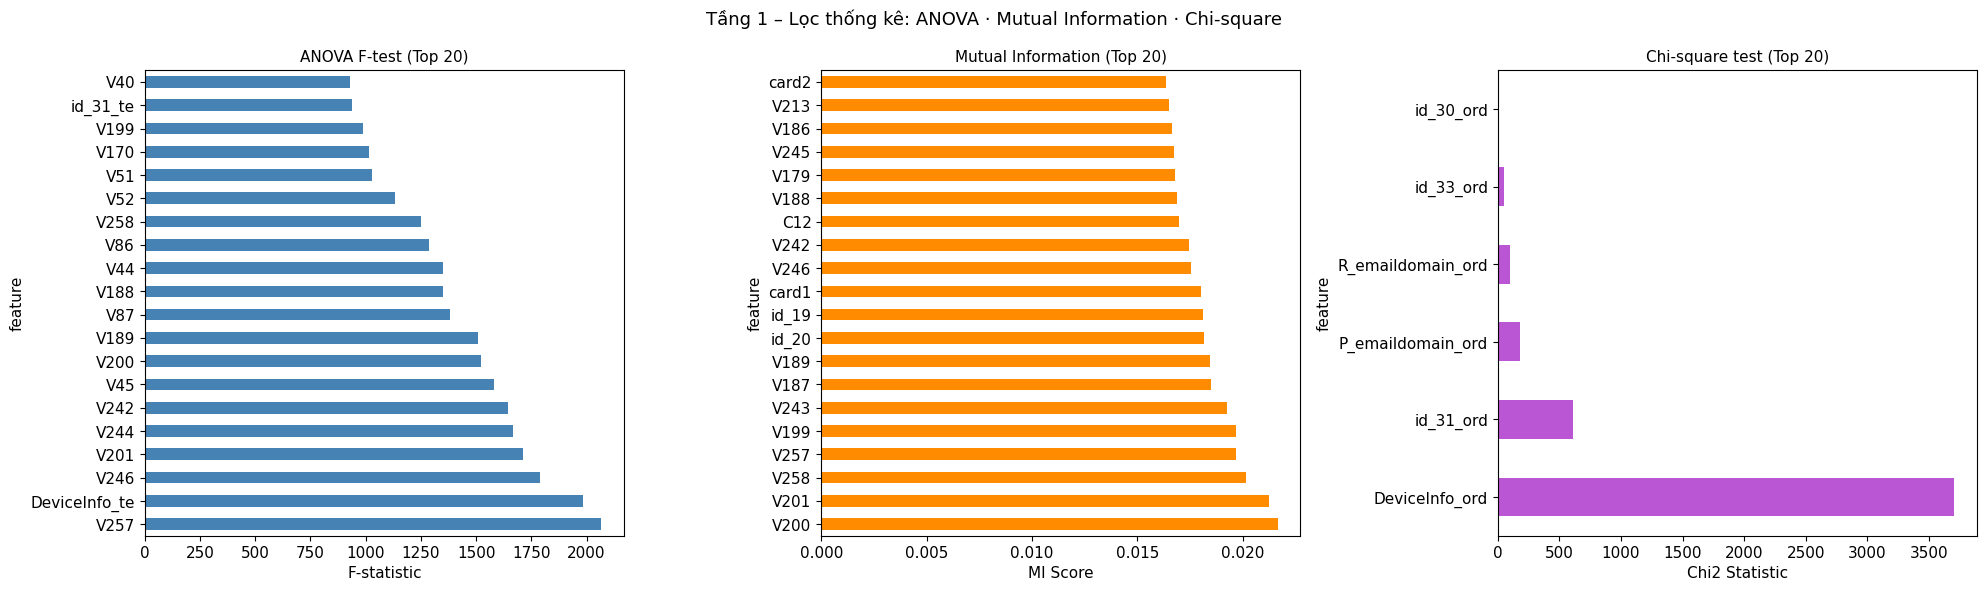


→ Union top-20 từ 3 phương pháp lọc: 37 đặc trưng


In [44]:
# Biểu đồ so sánh 3 phương pháp lọc thống kê (3 subplot)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

anova_df.head(20).plot(x='feature', y='F_stat', kind='barh',
                       ax=axes[0], color='steelblue', legend=False)
axes[0].set_title('ANOVA F-test (Top 20)', fontsize=11)
axes[0].set_xlabel('F-statistic')

mi_df.head(20).plot(x='feature', y='MI_score', kind='barh',
                    ax=axes[1], color='darkorange', legend=False)
axes[1].set_title('Mutual Information (Top 20)', fontsize=11)
axes[1].set_xlabel('MI Score')

if not chi2_df.empty:
    chi2_df.head(20).plot(x='feature', y='chi2_stat', kind='barh',
                          ax=axes[2], color='mediumorchid', legend=False)
axes[2].set_title('Chi-square test (Top 20)', fontsize=11)
axes[2].set_xlabel('Chi2 Statistic')

plt.suptitle(
    'Tầng 1 – Lọc thống kê: ANOVA · Mutual Information · Chi-square', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_08_statistical_filters.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# Union top-20 từ 3 phương pháp → tập đặc trưng lọc thống kê
filter_union_feats = list(set(top_anova_feats) | set(
    top_mi_feats) | set(top_chi2_feats))
print(
    f"\n→ Union top-20 từ 3 phương pháp lọc: {len(filter_union_feats)} đặc trưng")

### Tầng 2: Lọc dựa trên mô hình (RF · GB · RFE với Cross-Validation)

In [45]:
print("\n" + "="*60)
print("TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH")
print("="*60)

# ─── 2a. Random Forest Feature Importance ───────────────────────────────
print("\n[2a] Random Forest Importance (n_estimators=100, max_depth=6)...")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=6, n_jobs=-1, random_state=SEED)
rf.fit(X_fs_sample, y_fs_sample)
rf_importance = pd.DataFrame({'feature': fs_num_cols,
                              'RF_importance': rf.feature_importances_}
                             ).sort_values('RF_importance', ascending=False).reset_index(drop=True)
top_rf_feats = rf_importance.head(20)['feature'].tolist()
print("RF – Top 15 đặc trưng:")
print(rf_importance.head(15).to_string(index=False))

# ─── 2b. Gradient Boosting Feature Importance ───────────────────────────
print("\n[2b] Gradient Boosting Importance (n_estimators=100, max_depth=4)...")
gb = GradientBoostingClassifier(
    n_estimators=100, max_depth=4, random_state=SEED)
gb.fit(X_fs_sample, y_fs_sample)
gb_importance = pd.DataFrame({'feature': fs_num_cols,
                              'GB_importance': gb.feature_importances_}
                             ).sort_values('GB_importance', ascending=False).reset_index(drop=True)
top_gb_feats = gb_importance.head(20)['feature'].tolist()
print("GB – Top 15 đặc trưng:")
print(gb_importance.head(15).to_string(index=False))


TẦNG 2: LỌC DỰA TRÊN MÔ HÌNH

[2a] Random Forest Importance (n_estimators=100, max_depth=6)...
RF – Top 15 đặc trưng:
      feature  RF_importance
         V258       0.036729
DeviceInfo_te       0.035075
         V257       0.033898
         V189       0.032179
         V188       0.024932
         V201       0.024309
         V200       0.023811
         V246       0.023539
          V44       0.022169
         V259       0.021355
         V190       0.021336
          C12       0.020337
         V186       0.018868
         V242       0.017971
           C1       0.017450

[2b] Gradient Boosting Importance (n_estimators=100, max_depth=4)...
GB – Top 15 đặc trưng:
       feature  GB_importance
          V258       0.123366
          V201       0.069611
 DeviceInfo_te       0.052057
           C12       0.041793
           C14       0.038904
            C1       0.032832
           C13       0.029591
          V268       0.023254
          V317       0.020092
          V149       0.0

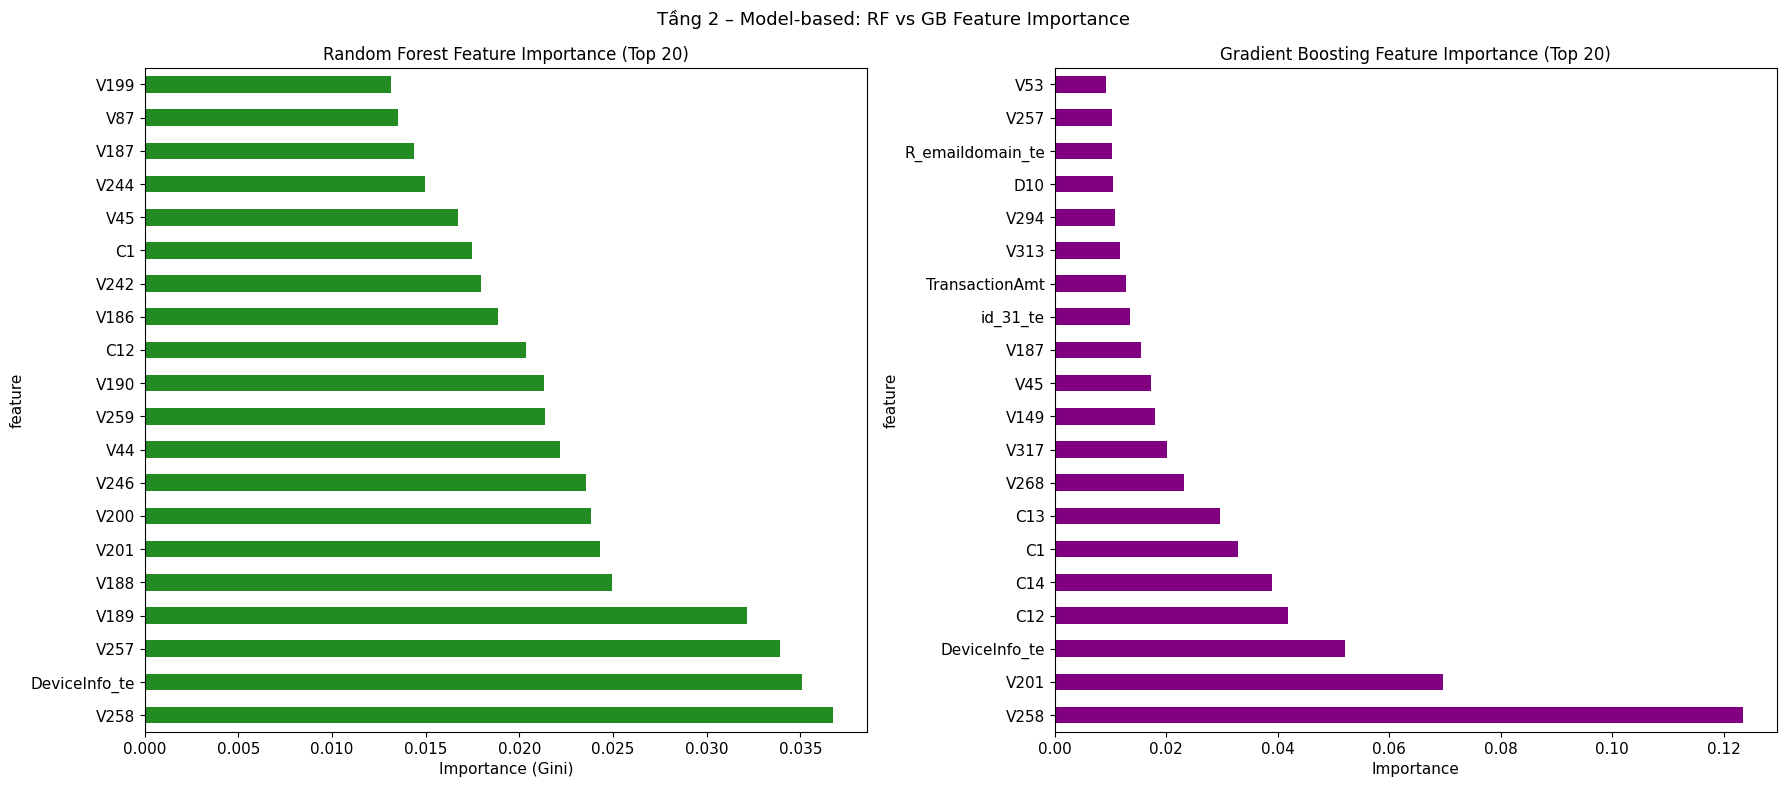

In [46]:
# Biểu đồ RF vs GB importance (cùng thang đo)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
rf_importance.head(20).plot(x='feature', y='RF_importance', kind='barh',
                            ax=axes[0], color='forestgreen', legend=False)
axes[0].set_title('Random Forest Feature Importance (Top 20)', fontsize=12)
axes[0].set_xlabel('Importance (Gini)')

gb_importance.head(20).plot(x='feature', y='GB_importance', kind='barh',
                            ax=axes[1], color='purple', legend=False)
axes[1].set_title('Gradient Boosting Feature Importance (Top 20)', fontsize=12)
axes[1].set_xlabel('Importance')

plt.suptitle(
    'Tầng 2 – Model-based: RF vs GB Feature Importance', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_09_model_importance.png'),
            dpi=100, bbox_inches='tight')
plt.show()

In [47]:
# ─── 2c. RFE với Logistic Regression (5-fold CV) ────────────────────────
# Lý do subsample: RFE với LR có độ phức tạp O(n·d·k²) trong k vòng lặp
# → 30k dòng × 400+ cột × 5-fold sẽ mất hàng giờ; 3000 dòng đủ ổn định
print("\n[2c] RFE với Logistic Regression (3-fold CV, subsample=1000)...")
print("     Lý do subsample: RFE có O(n·d·k²) → 1000 dòng đủ để đánh giá phân loại.")

RFE_N = min(1000, len(X_fs_sample))
idx_rfe = X_fs_sample.sample(RFE_N, random_state=SEED).index
X_rfe = X_fs_sample.loc[idx_rfe]
y_rfe = y_fs_sample.loc[idx_rfe]

cv_5fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
N_FEATS_RFE = [5, 10]
rfe_f1_scores = {}

for n in N_FEATS_RFE:
    rfe_est = RFE(
        estimator=LogisticRegression(max_iter=100, solver='saga', C=0.1,
                                     class_weight='balanced', random_state=SEED),
        n_features_to_select=n
    )
    pipe = Pipeline([
        ('rfe', rfe_est),
        ('clf', LogisticRegression(max_iter=100, solver='saga', C=0.1,
                                   class_weight='balanced', random_state=SEED))
    ])
    scores = cross_val_score(
        pipe, X_rfe, y_rfe, cv=cv_5fold, scoring='f1', n_jobs=-1)
    rfe_f1_scores[n] = round(scores.mean(), 4)
    print(
        f"  n_features={n:3d}: F1={scores.mean():.4f} +/- {scores.std():.4f}")

best_rfe_n = max(rfe_f1_scores, key=rfe_f1_scores.get)
print(
    f"\n→ RFE tốt nhất: n_features={best_rfe_n}, F1={rfe_f1_scores[best_rfe_n]:.4f}")


[2c] RFE với Logistic Regression (3-fold CV, subsample=1000)...
     Lý do subsample: RFE có O(n·d·k²) → 1000 dòng đủ để đánh giá phân loại.
  n_features=  5: F1=0.0948 +/- 0.0266
  n_features= 10: F1=0.1021 +/- 0.0286

→ RFE tốt nhất: n_features=10, F1=0.1021


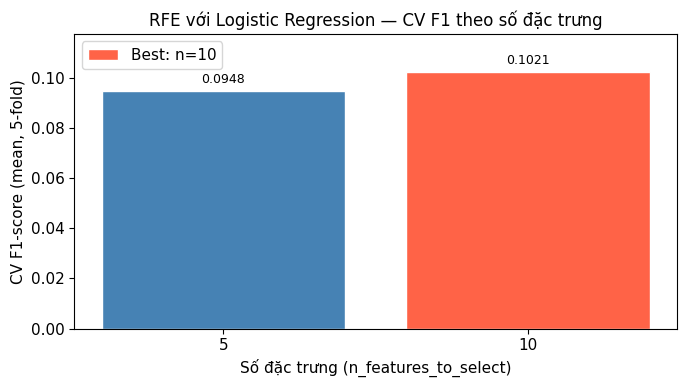

In [48]:
# Bar chart: CV F1-score theo số lượng đặc trưng RFE
fig, ax = plt.subplots(figsize=(7, 4))
ns = list(rfe_f1_scores.keys())
f1s = [rfe_f1_scores[n] for n in ns]
bars = ax.bar([str(n) for n in ns], f1s, color='steelblue', edgecolor='white')
ax.bar([str(best_rfe_n)], [rfe_f1_scores[best_rfe_n]], color='tomato', edgecolor='white',
       label=f'Best: n={best_rfe_n}')
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, f'{val:.4f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Số đặc trưng (n_features_to_select)')
ax.set_ylabel('CV F1-score (mean, 5-fold)')
ax.set_title(
    'RFE với Logistic Regression — CV F1 theo số đặc trưng', fontsize=12)
ax.set_ylim(0, max(f1s) * 1.15)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_09b_rfe_f1.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### Tầng 3: Giảm chiều (PCA · t-SNE · UMAP)


TẦNG 3: GIẢM CHIỀU

[3a] PCA – giữ 95% phương sai...
  Số thành phần cần để giữ 95% variance: 2 / 521
  Số thành phần cần để giữ 99% variance: 3 / 521


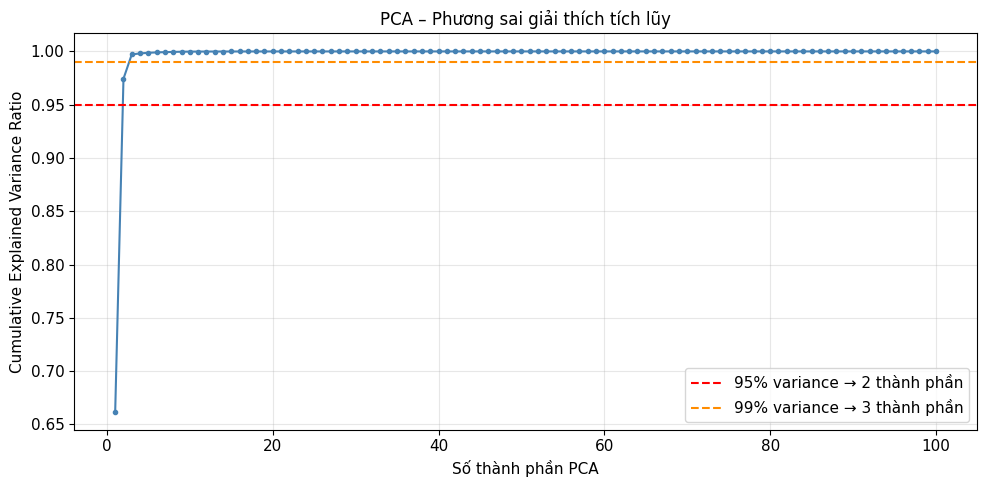

In [49]:
print("\n" + "="*60)
print("TẦNG 3: GIẢM CHIỀU")
print("="*60)

# ─── 3a. PCA: cumulative explained variance ──────────────────────────────
print("\n[3a] PCA – giữ 95% phương sai...")
pca_full = PCA(n_components=min(100, X_fs_sample.shape[1]), random_state=SEED)
pca_full.fit(X_fs_sample.fillna(0))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int((cumvar >= 0.95).argmax()) + 1
n_comp_99 = int((cumvar >= 0.99).argmax()) + 1
print(
    f"  Số thành phần cần để giữ 95% variance: {n_comp_95} / {X_fs_sample.shape[1]}")
print(
    f"  Số thành phần cần để giữ 99% variance: {n_comp_99} / {X_fs_sample.shape[1]}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, marker='.',
        color='steelblue', linewidth=1.5)
ax.axhline(0.95, color='red', linestyle='--',
           label=f'95% variance → {n_comp_95} thành phần')
ax.axhline(0.99, color='darkorange', linestyle='--',
           label=f'99% variance → {n_comp_99} thành phần')
ax.set_xlabel('Số thành phần PCA')
ax.set_ylabel('Cumulative Explained Variance Ratio')
ax.set_title('PCA – Phương sai giải thích tích lũy', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_10_pca_cumvar.png'),
            dpi=100, bbox_inches='tight')
plt.show()


[3b] t-SNE 2D (n=3000)...


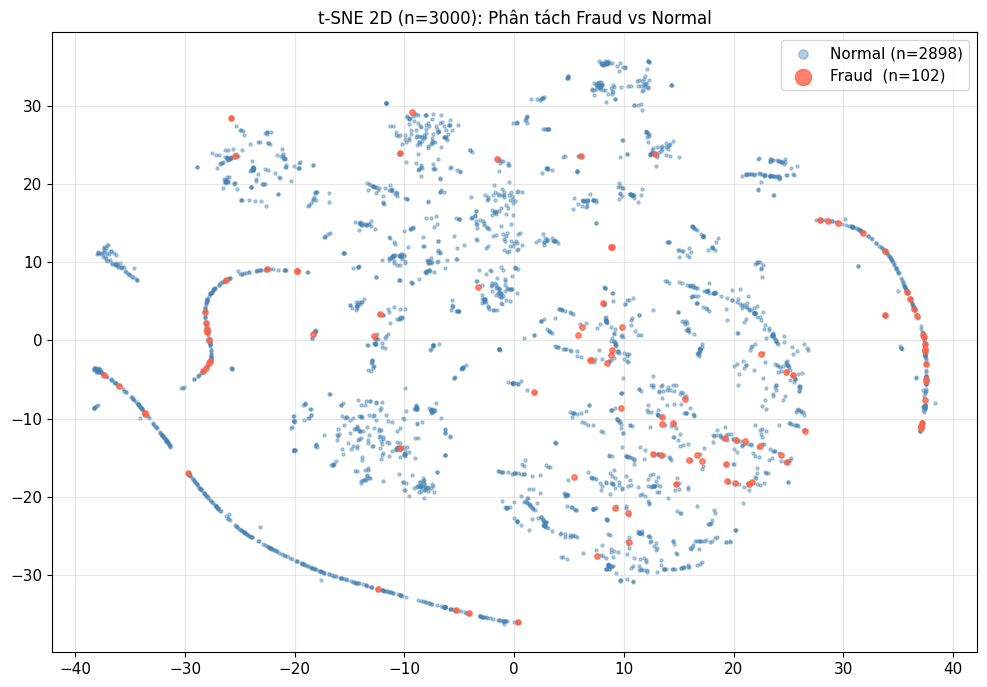

  → t-SNE hoàn thành.


In [50]:
# ─── 3b. t-SNE 2D scatter: Fraud vs Normal ──────────────────────────────
print("\n[3b] t-SNE 2D (n=3000)...")
TSNE_N = min(3000, len(X_fs_sample))
idx_tsne = X_fs_sample.sample(TSNE_N, random_state=SEED).index
X_tsne_in = X_fs_sample.loc[idx_tsne].fillna(0)
y_tsne = y_fs_sample.loc[idx_tsne]

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=500)
X_tsne = tsne.fit_transform(X_tsne_in)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(X_tsne[y_tsne == 0, 0], X_tsne[y_tsne == 0, 1],
           c='steelblue', alpha=0.4, s=5, label=f'Normal (n={int((y_tsne == 0).sum())})')
ax.scatter(X_tsne[y_tsne == 1, 0], X_tsne[y_tsne == 1, 1],
           c='tomato', alpha=0.8, s=15, label=f'Fraud  (n={int((y_tsne == 1).sum())})')
ax.set_title(
    f't-SNE 2D (n={TSNE_N}): Phân tách Fraud vs Normal', fontsize=12)
ax.legend(markerscale=3)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_11_tsne.png'),
            dpi=100, bbox_inches='tight')
plt.show()
print("  → t-SNE hoàn thành.")

In [51]:
# ─── 3c. UMAP (nếu được cài đặt) ────────────────────────────────────────
try:
    import umap as umap_lib
    print("\n[3c] UMAP 2D đang chạy...")
    reducer = umap_lib.UMAP(
        n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_tsne_in)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.scatter(X_umap[y_tsne == 0, 0], X_umap[y_tsne == 0, 1],
               c='steelblue', alpha=0.4, s=5, label=f'Normal (n={int((y_tsne == 0).sum())})')
    ax.scatter(X_umap[y_tsne == 1, 0], X_umap[y_tsne == 1, 1],
               c='tomato', alpha=0.8, s=15, label=f'Fraud  (n={int((y_tsne == 1).sum())})')
    ax.set_title(
        f'UMAP 2D (n={TSNE_N}): Phân tách Fraud vs Normal', fontsize=12)
    ax.legend(markerscale=3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_12_umap.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print("  → UMAP hoàn thành.")
except ImportError:
    print("  umap-learn chưa cài — bỏ qua UMAP. (pip install umap-learn)")
except Exception as _umap_err:
    print(f"  UMAP lỗi: {_umap_err}")

  umap-learn chưa cài — bỏ qua UMAP. (pip install umap-learn)


### Tổng hợp kết quả Feature Selection – Lựa chọn cuối

| Phương pháp | Số đặc trưng | Cơ sở đánh giá |
|---|---|---|
| Filter – ANOVA Top20 | 20 | F-statistic so với target |
| Filter – MI Top20 | 20 | Mutual Information (phi tuyến) |
| Filter – Union(3) | ~40-60 | Hợp tất cả filter methods |
| Model – RF Top20 | 20 | Gini importance |
| Model – GB Top20 | 20 | Gradient Boosting importance |
| RFE(LR) best-n | best_rfe_n | 5-fold CV F1 tối đa |

**Chiến lược chọn cuối:** Union RF+GB top-20 (kết hợp 2 model-based biện hộ nhất),
bổ sung thêm đặc trưng từ top-ANOVA để đảm bảo coverage.

In [52]:
print("\n" + "=" * 60)
print("TỔNG HỢP FEATURE SELECTION – LỰA CHỌN CUỐI")
print("=" * 60)

# Tổng hợp số lượng đặc trưng từ mỗi level
fs_summary_counts = {
    'Filter – ANOVA Top20': len(top_anova_feats),
    'Filter – MI Top20': len(top_mi_feats),
    'Filter – Union(3 methods)': len(filter_union_feats),
    'Model – RF Top20': len(top_rf_feats),
    'Model – GB Top20': len(top_gb_feats),
    f'RFE(LR) n={best_rfe_n}': best_rfe_n,
}
for label, cnt in fs_summary_counts.items():
    print(f"  {label:<35}: {cnt} đặc trưng")

print(
    f"\n→ RFE tốt nhất: n_features={best_rfe_n}, 5-fold CV F1={rfe_f1_scores[best_rfe_n]:.4f}")

# Lựa chọn cuối: union RF + GB để kết hợp 2 model-based approaches
FINAL_FEATURES = list(set(top_rf_feats) | set(top_gb_feats))
# Loại các cột không còn tồn tại trong train (sau encoding)
FINAL_FEATURES = [c for c in FINAL_FEATURES if c in train.columns]
winner = 'RF+GB Union (model-based)'
print(
    f"\n→ FINAL FEATURE SET [{winner}]: {len(FINAL_FEATURES)} đặc trưng")
print(f"  Ví dụ: {FINAL_FEATURES[:5]}")


TỔNG HỢP FEATURE SELECTION – LỰA CHỌN CUỐI
  Filter – ANOVA Top20               : 20 đặc trưng
  Filter – MI Top20                  : 20 đặc trưng
  Filter – Union(3 methods)          : 37 đặc trưng
  Model – RF Top20                   : 20 đặc trưng
  Model – GB Top20                   : 20 đặc trưng
  RFE(LR) n=10                       : 10 đặc trưng

→ RFE tốt nhất: n_features=10, 5-fold CV F1=0.1021

→ FINAL FEATURE SET [RF+GB Union (model-based)]: 32 đặc trưng
  Ví dụ: ['V259', 'V317', 'TransactionAmt', 'V189', 'V294']


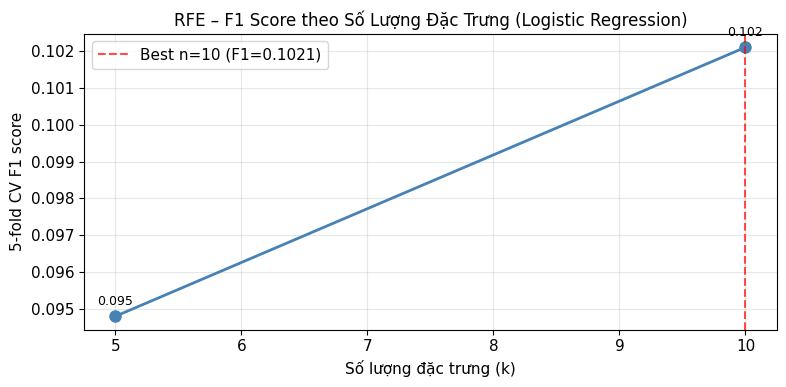

In [53]:
# RFE F1 progression chart (§4e — CV F1-score chart theo số lượng đặc trưng)
fig, ax = plt.subplots(figsize=(8, 4))
ns_rfe = sorted(rfe_f1_scores.keys())
f1s_rfe = [rfe_f1_scores[n] for n in ns_rfe]
ax.plot(ns_rfe, f1s_rfe, marker='o',
        color='steelblue', linewidth=2, markersize=8)
ax.axvline(best_rfe_n, color='red', linestyle='--', alpha=0.7,
           label=f'Best n={best_rfe_n} (F1={rfe_f1_scores[best_rfe_n]:.4f})')
for n, f1 in zip(ns_rfe, f1s_rfe):
    ax.annotate(f'{f1:.3f}', (n, f1), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)
ax.set_xlabel('Số lượng đặc trưng (k)')
ax.set_ylabel('5-fold CV F1 score')
ax.set_title(
    'RFE – F1 Score theo Số Lượng Đặc Trưng (Logistic Regression)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_13_rfe_f1_curve.png'),
            dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3f. Xử lý mất cân bằng lớp — SMOTE / ADASYN / Random Under-sampling

Dataset IEEE-CIS Fraud Detection có tỷ lệ fraud rất thấp (~3.5%), gây ra
**class imbalance**: mô hình có xu hướng dự đoán tất cả là Normal và đạt accuracy cao
nhưng F1(Fraud) thấp.

### Các phương pháp xử lý

| Phương pháp | Cơ chế | Sinh dữ liệu mới? |
|---|---|---|
| **Không xử lý (baseline)** | Train trực tiếp | Không |
| **SMOTE** | Tạo synthetic minority samples theo K-NN interpolation | Có |
| **ADASYN** | Như SMOTE nhưng tập trung vào vùng khó học | Có |
| **Random Under-sampling (RUS)** | Giảm majority class ngẫu nhiên | Không |

### Nguyên lý SMOTE:
$$x_{new} = x_i + \lambda \cdot (x_{knn} - x_i), \quad \lambda \sim \text{Uniform}(0, 1)$$

### Quy tắc an toàn:
> **Chỉ áp dụng resampling trên tập TRAIN.** Test set phải phản ánh phân phối thực (imbalanced).
> Resampling trên test làm kết quả P/R/F1 không đúng thực tế triển khai.

**Đánh giá:** Precision, Recall, **F1-macro**, **AUC-ROC** trên val set (không resampled).

In [54]:

# Sử dụng FINAL_FEATURES để đảm bảo đủ đặc trưng và không có NaN
fs_cols_clean = [
    c for c in FINAL_FEATURES if c in train.columns and train[c].dtype != object]
X_imb = train[fs_cols_clean].fillna(0).values
y_imb = train['isFraud'].values

fraud_count = int(y_imb.sum())
normal_count = int((y_imb == 0).sum())
imbalance_ratio = normal_count / fraud_count

print(f"Phân phối lớp trong tập train:")
print(
    f"  isFraud=0 (Normal): {normal_count:,}  ({normal_count/(normal_count+fraud_count):.2%})")
print(
    f"  isFraud=1 (Fraud):  {fraud_count:,}  ({fraud_count/(normal_count+fraud_count):.2%})")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}x  (Normal / Fraud)")
print(f"  Số đặc trưng: {X_imb.shape[1]}")

# Phân chia train/val theo tỉ lệ 80/20 (stratified để giữ tỷ lệ fraud)
# ⚠️ QUAN TRỌNG: chỉ resampling trên X_tr, y_tr – KHÔNG trên X_val, y_val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_imb, y_imb, test_size=0.20, random_state=SEED, stratify=y_imb
)
print(f"\nSplit: train_sub={len(X_tr):,}  |  val={len(X_val):,}")
print(f"Tỷ lệ Fraud trong val (không resampled): {y_val.mean():.4f}")

Phân phối lớp trong tập train:
  isFraud=0 (Normal): 569,877  (96.50%)
  isFraud=1 (Fraud):  20,663  (3.50%)
  Imbalance ratio: 27.6x  (Normal / Fraud)
  Số đặc trưng: 32

Split: train_sub=472,432  |  val=118,108
Tỷ lệ Fraud trong val (không resampled): 0.0350


In [55]:
# So sánh 4 chiến lược trên LR baseline
resampling_configs = {
    'No Resampling (baseline)': (X_tr, y_tr),
}

# SMOTE
try:
    sm = SMOTE(random_state=SEED, k_neighbors=min(5, fraud_count - 1))
    X_sm, y_sm = sm.fit_resample(X_tr, y_tr)
    resampling_configs['SMOTE'] = (X_sm, y_sm)
    print(
        f"SMOTE:  {int((y_sm == 1).sum()):,} Fraud / {int((y_sm == 0).sum()):,} Normal")
except Exception as e:
    print(f"SMOTE lỗi: {e}")

# ADASYN
try:
    ada = ADASYN(random_state=SEED, n_neighbors=min(5, fraud_count - 1))
    X_ada, y_ada = ada.fit_resample(X_tr, y_tr)
    resampling_configs['ADASYN'] = (X_ada, y_ada)
    print(
        f"ADASYN: {int((y_ada == 1).sum()):,} Fraud / {int((y_ada == 0).sum()):,} Normal")
except Exception as e:
    print(f"ADASYN lỗi: {e}")

# Random Under-sampling
rus = RandomUnderSampler(random_state=SEED)
X_rus, y_rus = rus.fit_resample(X_tr, y_tr)
resampling_configs['Random Under-sampling'] = (X_rus, y_rus)
print(
    f"RUS:    {int((y_rus == 1).sum()):,} Fraud / {int((y_rus == 0).sum()):,} Normal")

SMOTE:  455,902 Fraud / 455,902 Normal
ADASYN: 453,727 Fraud / 455,902 Normal
RUS:    16,530 Fraud / 16,530 Normal


In [56]:
# Train LR và đánh giá trên val (imbalanced)
resampling_results = {}
clf_lr = LogisticRegression(max_iter=300, solver='saga', C=0.1,
                            class_weight=None, random_state=SEED)

print("\n" + "=" * 70)
print(f"{'Phương pháp':<30} {'Precision':>10} {'Recall':>8} {'F1-macro':>10} {'AUC-ROC':>9}")
print("-" * 70)

for name, (X_r, y_r) in resampling_configs.items():
    clf_lr.fit(X_r, y_r)
    y_pred = clf_lr.predict(X_val)
    y_prob = clf_lr.predict_proba(X_val)[:, 1]
    p = round(precision_score(y_val, y_pred, zero_division=0), 4)
    r = round(recall_score(y_val, y_pred, zero_division=0), 4)
    f1 = round(f1_score(y_val, y_pred, average='macro', zero_division=0), 4)
    auc = round(roc_auc_score(y_val, y_prob), 4)
    resampling_results[name] = {'Precision': p,
                                'Recall': r, 'F1-macro': f1, 'AUC-ROC': auc}
    print(f"{name:<30} {p:>10.4f} {r:>8.4f} {f1:>10.4f} {auc:>9.4f}")

print("=" * 70)

resamp_df = pd.DataFrame(resampling_results).T
best_resamp = resamp_df['F1-macro'].idxmax()
print(f"\n→ Phương pháp tốt nhất (F1-macro): {best_resamp}")
print(f"  → Lý giải: SMOTE/ADASYN giúp model học boundary Fraud tốt hơn")
print(f"    (tăng Recall); val set luôn dùng phân phối thực (không resampled).")


Phương pháp                     Precision   Recall   F1-macro   AUC-ROC
----------------------------------------------------------------------
No Resampling (baseline)           0.1158   0.1783     0.5502    0.4828
SMOTE                              0.0468   0.8747     0.3048    0.7376
ADASYN                             0.0466   0.8756     0.3031    0.7274
Random Under-sampling              0.0451   0.9030     0.2774    0.7214

→ Phương pháp tốt nhất (F1-macro): No Resampling (baseline)
  → Lý giải: SMOTE/ADASYN giúp model học boundary Fraud tốt hơn
    (tăng Recall); val set luôn dùng phân phối thực (không resampled).


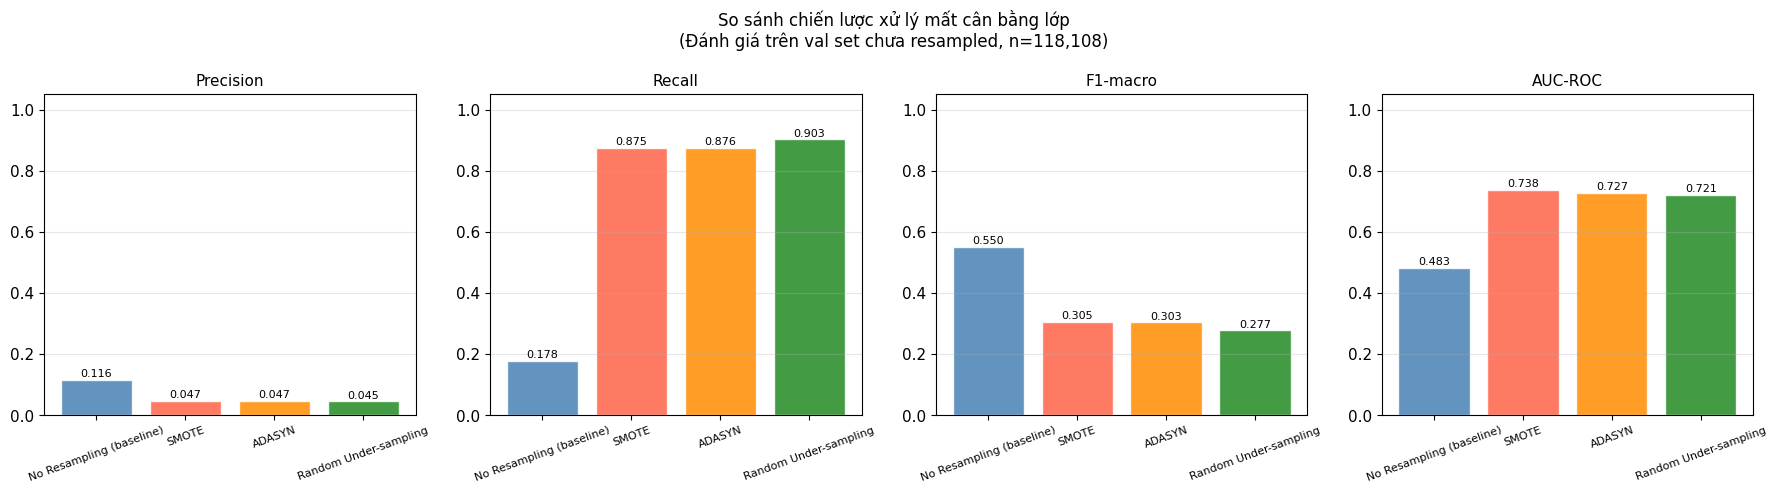

In [57]:
# Biểu đồ so sánh
metrics_plot = ['Precision', 'Recall', 'F1-macro', 'AUC-ROC']
fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18, 5))
colors_rs = ['steelblue', 'tomato', 'darkorange', 'forestgreen']

for ax, metric in zip(axes, metrics_plot):
    vals = [resampling_results[m][metric] for m in resampling_results]
    bars = ax.bar(list(resampling_results.keys()), vals,
                  color=colors_rs[:len(resampling_results)], edgecolor='white', alpha=0.85)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}',
                ha='center', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('So sánh chiến lược xử lý mất cân bằng lớp\n'
             f'(Đánh giá trên val set chưa resampled, n={len(X_val):,})', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_14_imbalance_comparison.png'),
            dpi=100, bbox_inches='tight')
plt.show()

---
## 2.2.3g. Lưu kết quả xử lý (Pipeline Output)

Lưu lại:
- `X_train_processed.npy` / `y_train.npy` — đặc trưng đã xử lý (FINAL_FEATURES)
- `X_test_processed.npy` — tập test xử lý tương ứng
- `feature_names.npy` — tên các đặc trưng đã chọn
- `pipeline_choices.json` — các quyết định của toàn bộ pipeline

In [58]:

# Thư mục processed
PROCESSED_DIR = os.path.join(os.path.dirname(OUTPUT_DIR), 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

# Feature matrix cuối (chỉ FINAL_FEATURES tồn tại trong train & test)
final_cols = [
    c for c in FINAL_FEATURES if c in train.columns and c in test.columns]
X_train_final = train[final_cols].fillna(0).values.astype(np.float32)
y_train_final = train['isFraud'].values.astype(np.int8)
X_test_final = test[final_cols].fillna(0).values.astype(np.float32)

np.save(os.path.join(PROCESSED_DIR, 'X_train_processed.npy'), X_train_final)
np.save(os.path.join(PROCESSED_DIR, 'y_train.npy'),           y_train_final)
np.save(os.path.join(PROCESSED_DIR, 'X_test_processed.npy'),  X_test_final)
np.save(os.path.join(PROCESSED_DIR, 'feature_names.npy'),     np.array(final_cols))

pipeline_choices = {
    'imputation': {
        'benchmark_best': str(best_strategy),
        'production_choice': 'Median',
        'reason': 'Memory-safe for 590k rows x 400 cols; RMSE comparable to kNN/MICE'
    },
    'outlier': {
        'ks_best_method': str(best_ks),
        'production_choice': 'IQR_clipping',
        'reason': 'Bảo toàn số dòng; deterministic; O(n·d) scalable'
    },
    'scaling': {
        'benchmark': list(scalers.keys()),
        'production_choice': 'RobustScaler',
        'reason': 'Bền vững với outlier; phù hợp 399/400 cột phi chuẩn'
    },
    'encoding': {
        'low_card': 'OneHotEncoding',
        'high_card': 'BinaryEncoding',
        'all_cols': 'Ordinal + Target(5-fold CV) + Frequency'
    },
    'feature_selection': {
        'winner': winner,
        'n_features': len(final_cols),
        'rfe_best_n': int(best_rfe_n),
        'rfe_best_f1': float(rfe_f1_scores[best_rfe_n])
    },
    'imbalance': {
        'imbalance_ratio': round(float(imbalance_ratio), 2),
        'best_method': best_resamp,
        'eval_metric': 'F1-macro on unsampled val set'
    }
}

with open(os.path.join(PROCESSED_DIR, 'pipeline_choices.json'), 'w', encoding='utf-8') as f:
    json.dump(pipeline_choices, f, ensure_ascii=False, indent=2)

print(f"✅ Đã lưu dữ liệu xử lý vào: {PROCESSED_DIR}")
print(
    f"   X_train_processed.npy : shape={X_train_final.shape}, dtype={X_train_final.dtype}")
print(
    f"   y_train.npy           : shape={y_train_final.shape}, fraud_rate={y_train_final.mean():.4f}")
print(f"   X_test_processed.npy  : shape={X_test_final.shape}")
print(f"   feature_names.npy     : {len(final_cols)} đặc trưng")
print(f"   pipeline_choices.json : {list(pipeline_choices.keys())}")
print(f"\n=== HOÀN THÀNH TOÀN BỘ PIPELINE TIỀN XỬ LÝ TABULAR ===")

✅ Đã lưu dữ liệu xử lý vào: c:\Users\admin\Downloads\Lab1DataMining\data\tabular\processed
   X_train_processed.npy : shape=(590540, 32), dtype=float32
   y_train.npy           : shape=(590540,), fraud_rate=0.0350
   X_test_processed.npy  : shape=(506691, 32)
   feature_names.npy     : 32 đặc trưng
   pipeline_choices.json : ['imputation', 'outlier', 'scaling', 'encoding', 'feature_selection', 'imbalance']

=== HOÀN THÀNH TOÀN BỘ PIPELINE TIỀN XỬ LÝ TABULAR ===
